In [1]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Created on Fri Sep  8 14:54:33 2023

@author: Skarleth Motino Flores
Institution: USRA-NASA 
e-mail: skarlethgm@gmail.com
"""

# ------------------------------------------------------
#
#
#                      Libraries 
#
#
# ------------------------------------------------------

import os
import time 

from tqdm import tqdm 
from scipy.interpolate import RegularGridInterpolator
from math import log10, log1p
from matplotlib import cm

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
np.set_printoptions(precision=2)

import warnings
warnings.filterwarnings('ignore')


# ------------------------------------------------------
#
#                   Functions
#
# ------------------------------------------------------

from gism_Functions import *

# ------------------------------------------------------
#
#               Constants
#
# ------------------------------------------------------

c    = 3e8    # m/s
Lsun = 3.826e26													# Watts
pi   = 3.1416 


In [2]:
local_pwd = !pwd

In [3]:
# ------------------------------------------------------
#
#              Read Models
#
#
# ------------------------------------------------------
#

 
path = str(local_pwd[0]) 

# Line fluxes in Jykm/s  
  
nameFile_Models = path+'/input/PereiraModelsSB.txt' 
Models = ReadModels(nameFile_Models)
print (Models.columns)
Models


Index(['Z/Zo', 'log(n_Hcm-3)', 'log(U)', 'SIII19_SIII33', 'OIII52_OIII88',
       'NII122_NII205', 'SIV11_NeII16', 'NeII13_NeIII16', 'OIII52_NIII57',
       'OIII88_NIII57', 'OIII52_NII122', 'OIII52_NII205', 'OIII88_NII122',
       'OIII88_NII205', '(2.2XOIII88+OIII52)/NIII57', 'NIII57_NII122', 'U',
       'NIII57_OIII88', 'NII122_OIII88'],
      dtype='object')


,Z/Zo,log(n_Hcm-3),log(U),SIII19_SIII33,OIII52_OIII88,NII122_NII205,SIV11_NeII16,NeII13_NeIII16,OIII52_NIII57,OIII88_NIII57,OIII52_NII122,OIII52_NII205,OIII88_NII122,OIII88_NII205,(2.2XOIII88+OIII52)/NIII57,NIII57_NII122,U,NIII57_OIII88,NII122_OIII88
0,0.05,1,-4.0,0.436516,0.588844,0.912011,0.003236,1.995262,9.332543,15.848932,1.258925,1.148154,2.137962,1.949845,44.200193,0.134896,0.0001,0.063096,0.467735
1,0.05,1,-3.5,0.446684,0.588844,0.912011,0.021878,0.645654,10.0,16.982437,11.220185,10.23293,19.054607,17.378008,47.36136,1.122018,0.000316,0.058884,0.052481
2,0.05,1,-3.0,0.457088,0.588844,0.933254,0.112202,0.204174,11.748976,19.952623,75.857758,69.183097,128.824955,117.489755,55.644746,6.456542,0.001,0.050119,0.007762
3,0.05,1,-2.5,0.467735,0.588844,0.954993,0.436516,0.064565,13.182567,22.387211,316.227766,301.995172,537.031796,501.187234,62.434432,23.988329,0.003162,0.044668,0.001862
4,0.05,1,-2.0,0.47863,0.588844,0.977237,1.230269,0.020417,14.791084,25.118864,1023.292992,1000.0,1737.800829,1659.586907,70.052585,69.183097,0.01,0.039811,0.000575
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,2.00,6,-4.0,11.481536,10.23293,9.772372,0.000708,128.824955,1.148154,0.112202,0.054954,0.537032,0.00537,0.053703,1.394998,0.047863,0.0001,8.912509,186.208714
146,2.00,6,-3.5,11.748976,10.23293,9.772372,0.003631,52.480746,1.202264,0.11749,0.218776,2.137962,0.02138,0.20893,1.460742,0.18197,0.000316,8.51138,46.773514
147,2.00,6,-3.0,11.748976,10.23293,9.772372,0.012303,21.379621,1.348963,0.131826,1.148154,11.220185,0.112202,1.096478,1.638979,0.851138,0.001,7.585776,8.912509
148,2.00,6,-2.5,11.748976,10.23293,9.772372,0.029512,8.912509,1.737801,0.169824,5.128614,50.118723,0.501187,4.897788,2.111414,2.951209,0.003162,5.888437,1.995262


Index(['id', 'Galaxy', 'date', 'OIII52', 'OIII52_unc', 'OIII52_inst', 'OIII88',
       'OIII88_unc', 'OIII88_inst', 'NIII57', 'NIII57_unc', 'NIII57_inst',
       'NII122', 'NII122_unc', 'NII122_inst', 'reference', 'comment'],
      dtype='object')


Data Frame before adding 15 Cal to errors
   index  id   Galaxy    date  OIII52  OIII52_unc OIII52_inst   OIII88  \
0      0   6   Haro 3  30-Nov  26.370       1.100        FIFI   26.700   
1      1   7  Haro 10  30-Nov  86.373       2.140        FIFI  109.918   
2      2   8  He 2-10  30-Nov  40.801       2.056        FIFI   54.150   
3      3   9   Haro 3  15-Dec  26.524       1.039        FIFI   26.704   
4      4  10  Haro 10  15-Dec  85.517       1.495        FIFI  109.918   
5      5  11  He 2-10  15-Dec  40.702       2.047        FIFI   52.070   

   OIII88_unc OIII88_inst  NIII57  NIII57_unc NIII57_inst  NII122  NII122_unc  \
0       0.010        PACS   2.050       0.030        PACS   0.260       0.010   
1       0.031        PACS  


Plot saved to:  /Users/admin/Desktop/GalaxyUNZ/GalaxyUNZ_tool/Plots/Plot_LineRatios__Galaxies_20250110.pdf


Index(['index', 'id', 'Galaxy', 'date', 'OIII52', 'OIII52_unc', 'OIII52_inst',
       'OIII88', 'OIII88_unc', 'OIII88_inst', 'NIII57', 'NIII57_unc',
       'NIII57_inst', 'NII122', 'NII122_unc', 'NII122_inst', 'reference',
       'comment', 'OIII52/OIII88', 'NIII57/OIII88', 'NII122/OIII88',
       'OIII52/NIII57', 'OIII52/NII122', 'NIII57/NII122', 'OIII88/NII122',
       'OIII88/NIII57', '(2.2OIII88+OIII52)/NIII57', 'OIII52/OIII88_ERR',
       'NIII57/OIII88_ERR', 'NII122/OIII88_ERR', 'OIII52/NIII57_ERR',
       'OIII52/NII122_ERR', 'NIII57/NII122_ERR', 'OIII88/NII122_ERR',
       'OIII88/NIII57_ERR', '(2.2OIII88+OIII52)/NIII57_ERR'],
      dtype='object')

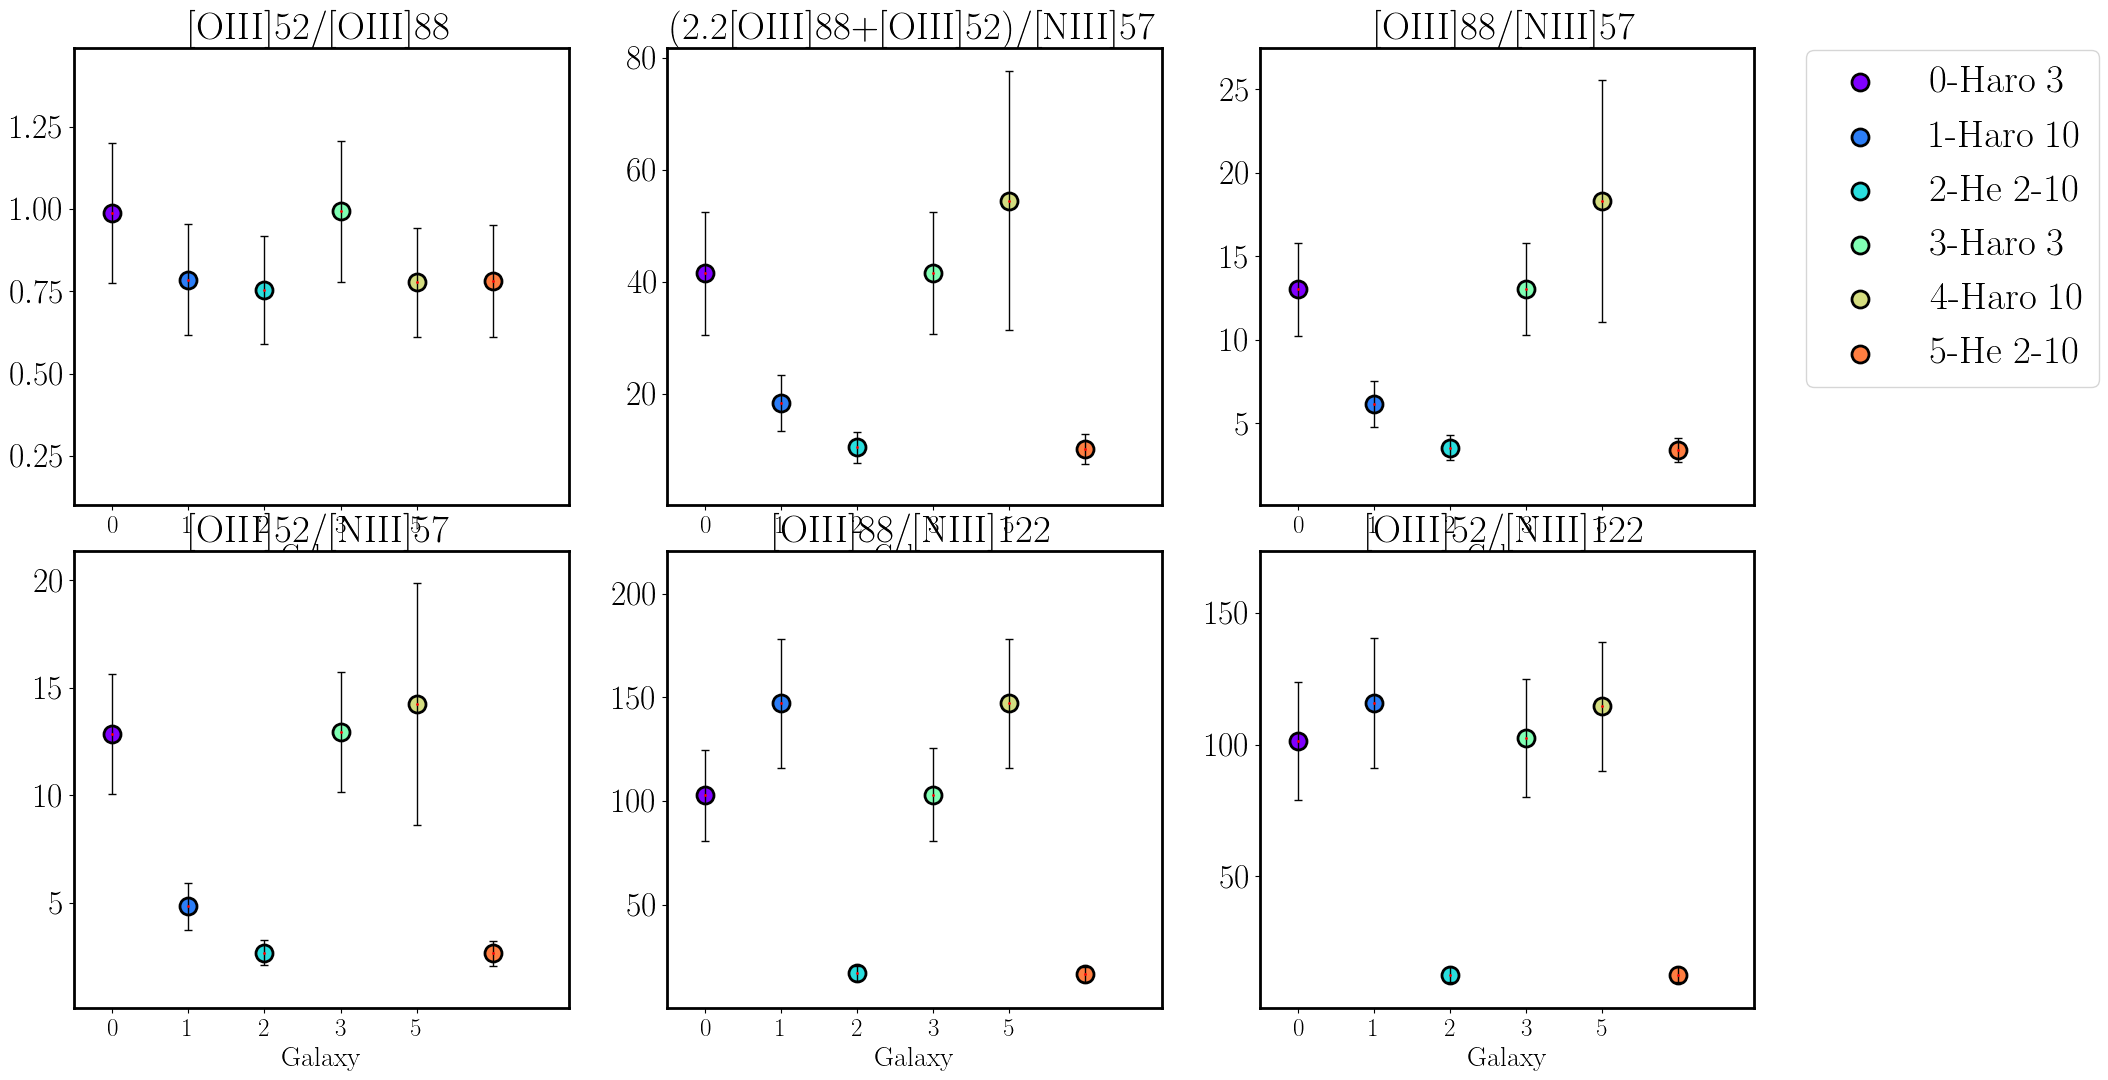

In [4]:
# ------------------------------------------------------
#
#            Parametros de entrada
#
# ------------------------------------------------------

date = '20250110'

# ------------------------------------------------------
#       
#         Read Galaxies Flux data
#
#     
# ------------------------------------------------------


# Plot Fluxes
# fluxes in Jykm/s
saveFigure1 = True
ArxName = path+'/Plots/Plot_LineRatios__Galaxies_'+date+'.pdf'


# Old format
#nameFile_Galaxy = path+'input/DATA-Diagnostics_09052023.csv' 
# New format
nameFile_Galaxy = path+'/data/Data_Fluxes_12152023.csv' 


# new format
Gal, lg = GetFluxesTable(nameFile_Galaxy, True,  saveFigure1, ArxName)
Gal.columns #Cols


# OR use:
# Tommy Fluxes file format

#Columns    
#  1  Index
#  2  Name
#  3  [OIII]52 10^-16 W/m^2
#  4  Sigma_[OIII]52 10^-16 W/m^2
#  5  [NIII]57 10^-16 W/m^2
#  6  Sigma_[NIII]57 10^-16 W/m^2
#  7  [OIII]88 10^-16 W/m^2
#  8  Sigma_[OIII]88 10^-16 W/m^2
#  9  [NII]122 10^-16 W/m^2
# 10  Sigma_[NII]122 10^-16 W/m^2
# 11  12+log(O/H) PT2005
# 12  12+log(O/H) I2006

#nameFile_Galaxy = path+'input/dwarf_flux.txt' # File provided by Tommy

#Gal, lg = GetFluxesTable_tf(nameFile_Galaxy, True,  True, ArxName)
#Gal.columns #Cols




In [5]:
Gal.columns

Index(['index', 'id', 'Galaxy', 'date', 'OIII52', 'OIII52_unc', 'OIII52_inst',
       'OIII88', 'OIII88_unc', 'OIII88_inst', 'NIII57', 'NIII57_unc',
       'NIII57_inst', 'NII122', 'NII122_unc', 'NII122_inst', 'reference',
       'comment', 'OIII52/OIII88', 'NIII57/OIII88', 'NII122/OIII88',
       'OIII52/NIII57', 'OIII52/NII122', 'NIII57/NII122', 'OIII88/NII122',
       'OIII88/NIII57', '(2.2OIII88+OIII52)/NIII57', 'OIII52/OIII88_ERR',
       'NIII57/OIII88_ERR', 'NII122/OIII88_ERR', 'OIII52/NIII57_ERR',
       'OIII52/NII122_ERR', 'NIII57/NII122_ERR', 'OIII88/NII122_ERR',
       'OIII88/NIII57_ERR', '(2.2OIII88+OIII52)/NIII57_ERR'],
      dtype='object')

In [6]:
Gal[['Galaxy','OIII52/OIII88', 'NIII57/OIII88', 'NII122/OIII88']]
     

#Columns    1  =['OIII52/OIII88',
#           2    'NIII57/OIII88',
#           3    'NII122/OIII88', 
#           4    'OIII52/NIII57',
#           5    'OIII52/NII122',
#           6    'NIII57/NII122', 
#           7    'OIII88/NII122',
#           8    'OIII88/NIII57',
#           9    '(2.2OIII88+OIII52)/NIII57' ] 


UseLinesArrays = [
    [1,1,1,0,0,0,0,0,0] , # Base model
    [1,0,0,0,0,0,1,1,0] , # inverse / OIII88
    
    [1,0,0,0,0,0,0,0,1] , # no 122  
    [1,1,0,0,0,0,0,0,0] , # no 122  
    
    [1,0,1,0,0,0,0,0,0] , # no 57   
    [1,0,0,0,0,0,1,0,0] , # no 57
    
    [0,1,1,0,0,0,0,0,0] , # no 52
#    [0,0,0,0,0,0,1,1,0] , # no 52 inverse
    [0,0,1,0,0,1,0,0,0] , # # no 52
] 

# Testing things

In [7]:
# GALAXY Options for He2-10 
FluxData = '6'                 
name     = 'He2-10'
notes    = '--'+date+'-' 
gali     = int(FluxData) - 1

# ------------------------------------------------------
#       
#                Output Plots
#       create the SummaryFile headers
#
#------------------------------------------------------
#path_output =  '/Users/smotinof/Documents/Scripts/GalaxyISM/Plots/' 

createNewSummaryFile = True
SummaryFile = path+'/output/'+date+'_UNZ_'+name+'_a.txt'
#print (nameFile_Galaxy, SummaryFile)

if createNewSummaryFile:
    with open( SummaryFile, 'w') as f: # 'w' create new file, 'a' add to file
            f.write('Galaxy,Flux_ID,u_bs,n_bs,z_bs,u_mn,u_unc,n_mn,n_unc,z_mn,z_unc,u_50p,u_16p,u_84p,n_50p,n_16p,n_84p,z_50p,z_16p,z_84p,LinesRatiosUsed\n')
            f.close()




 ----------------------------running 1/8

 Results will be written in files:
/Users/admin/Desktop/GalaxyUNZ/GalaxyUNZ_tool/Plots/20250110_He2-10__ProbPlot_Fx6_Mod-00_test
/Users/admin/Desktop/GalaxyUNZ/GalaxyUNZ_tool/Plots/20250110_He2-10__TriaPlot_Fx6_Mod-00_test
/Users/admin/Desktop/GalaxyUNZ/GalaxyUNZ_tool/output/20250110_UNZ_He2-10_a.txt



 Y_obs [ 0.78  0.29  0.06  2.66 12.73  4.79 16.28  3.4  10.13] 
 Y_sig [0.17 0.06 0.01 0.58 2.77 1.02 3.46 0.72 2.68]

 Selected lines: 
 Y_obs: [ 0.78  0.29  0.06  2.66 12.73  4.79 16.28  3.4  10.13] 
 Y_sig [1.71e-01 6.25e-02 1.30e-02 1.00e+06 1.00e+06 1.00e+06 1.00e+06 1.00e+06
 1.00e+06]

Lines:   
 - [OIII]-52/[OIII]-88 - [NIII]-57/[OIII]-88 - [NII]-122/[OIII]-88 
 - OIII52/OIII88- NIII57/OIII88- NII122/OIII88


(5, 6, 5, 9)
u 5 41 10
n 6 251 50
z 5 196 48
(41, 251, 196, 9)


100%|██████████| 5/5 [00:01<00:00,  3.32it/s]


Models Cube Shape:  (5, 6, 5, 9)  Interpolate to Size: [ 41 251 196] 



 z: [0.05 0.2  0.4  1.   2.  ] (5,)

 new z 
 Shape: (196,)


New Cube shape:  (41, 251, 196, 9)

 u shape: (41,) 
 n shape: (251,) 
 z shape: (196,)
Models refined shape:   (41, 251, 196, 9)
Chi shape:    (41, 251, 196, 9)
Chi^2 shape:  (41, 251, 196, 9) 	 Sum Chi^2 = 0.0E+00
Prob Shape:   (41, 251, 196) 	 Sum Prob = 1.00000E+00
Chi^2_min = 1.39E-02 
Chi^2_max = 0.00000E+00
Prob Dimensions: Pn (251,)  Pu (41,) Pz (196,)
BestSol Indexes: n-> [31] u-> [27] z-> [70] Chi_min^2 0.014
Parameters Dimensions  (251,)   (41,)   (196,)
_______________________________________________________________________

Best Fit 
 <n> = 1.62 		 <u> = -3.3500 		 <Z/Z> = 0.75
_______________________________________________________________________

Average Values, Standard Deviation
	 <u> = -3.3 +- 0.2  <n> = 1.6  +-  0.3 	 <Z/Z> = 0.7327  +-  0.1289
_______________________________________________________________________

Percentiles (Mean

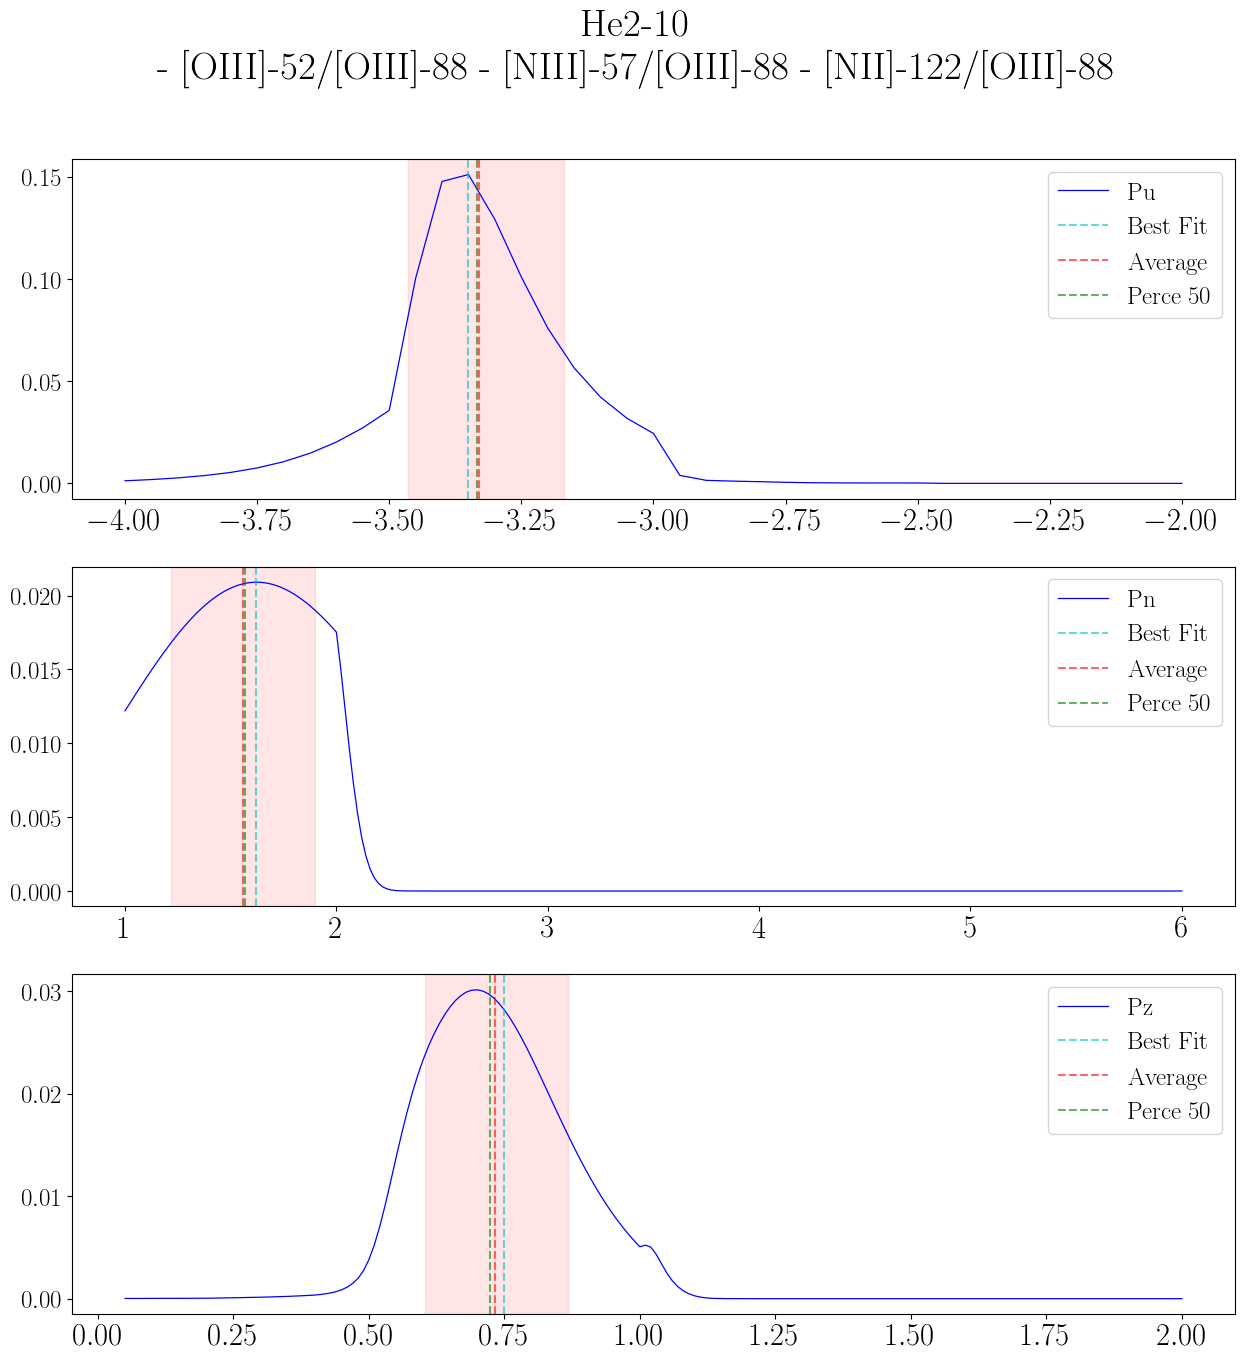

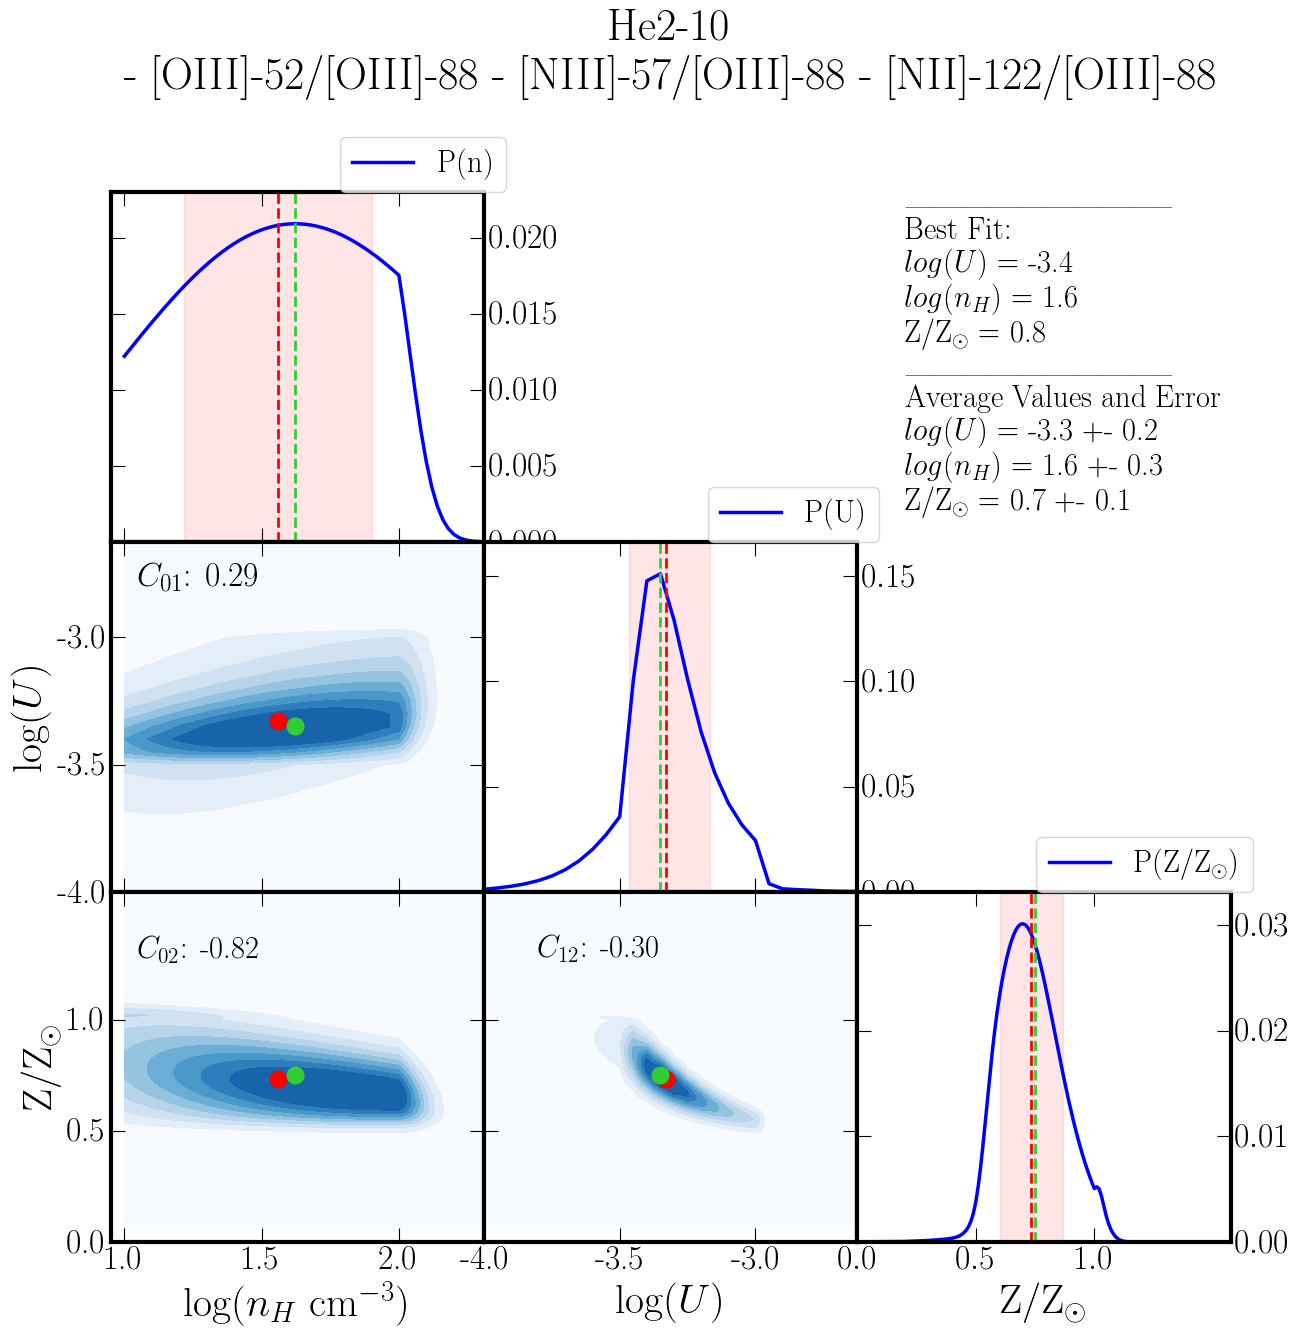

In [8]:

num_models = len(UseLinesArrays)
printgrids = False

for index in range(1):
    
        UseLines = UseLinesArrays[index]
        ModN = np.sum(UseLines) 
        strindex = str(index) 
        
        print('\n\n\n ----------------------------running '+str(index+1)+'/'+str(num_models))
        
        # Results table file:
        pltFileName1 = path+'/Plots/'+date+'_'+name+'__ProbPlot_Fx'+str(FluxData)+'_Mod-0'+strindex+'_test'
        pltFileName2 = path+'/Plots/'+date+'_'+name+'__TriaPlot_Fx'+str(FluxData)+'_Mod-0'+strindex+'_test'

        print('\n Results will be written in files:')
        print(pltFileName1)
        print(pltFileName2)
        print(SummaryFile)
        print('\n\n')

        #Old format
        #Y_obs, Y_sig, TxtLines , TxtLinesShort  = LineDataGalaxy(gali,Gal,UseLines)
        Y_obs, Y_sig, TxtLines , TxtLinesShort  = LineDataGalaxy2(gali,Gal,UseLines)
        Ny = len(Y_obs) #  Number of lines 

        # Run the model
        %run  "model-part-1.ipynb"


# 1 - He2-10





 ----------------------------running 1/9

 Results will be written in files:
/Users/admin/Scripts/GalaxyISM_0914/Plots/20240314_He2-10__Pplots_Fx6_Mod-00
/Users/admin/Scripts/GalaxyISM_0914/Plots/20240314_He2-10__Tplots_Fx6_Mod-00
UNZ_He-2-10_a_20240314.txt



 Y_obs [ 0.7817  0.2943  0.0614  2.6561 12.7273  4.7917 16.2821  3.3979 10.1316] 
 Y_sig [0.1706 0.0625 0.013  0.5792 2.775  1.0169 3.4574 0.7217 2.6832]

 Selected lines: 
 Y_obs: [ 0.7817  0.2943  0.0614  2.6561 12.7273  4.7917 16.2821  3.3979 10.1316] 
 Y_sig [1.7056e-01 6.2505e-02 1.3042e-02 1.0000e+06 1.0000e+06 1.0000e+06
 1.0000e+06 1.0000e+06 1.0000e+06]

Lines:   
 - [OIII]-52/[OIII]-88 - [NIII]-57/[OIII]-88 - [NII]-122/[OIII]-88 
 - OIII52/OIII88- NIII57/OIII88- NII122/OIII88
(5, 6, 5, 9)
u 5 41 10
n 6 251 50
z 5 196 48
(41, 251, 196, 9)


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:00<00:00,  6.99it/s]


Models Cube Shape:  (5, 6, 5, 9)  Interpolate to Size: [ 41 251 196] 



 z: [0.05 0.2  0.4  1.   2.  ] (5,)

 new z 
 Shape: (196,)


New Cube shape:  (41, 251, 196, 9)

 u shape: (41,) 
 n shape: (251,) 
 z shape: (196,)
Models refined shape:   (41, 251, 196, 9)
Chi shape:    (41, 251, 196, 9)
Chi^2 shape:  (41, 251, 196, 9) 	 Sum Chi^2 = 0.0E+00
Prob Shape:   (41, 251, 196) 	 Sum Prob = 1.00000E+00
Chi^2_min = 1.39E-02 
Chi^2_max = 0.00000E+00
Prob Dimensions: Pn (251,)  Pu (41,) Pz (196,)
BestSol Indexes: n-> [31] u-> [27] z-> [70] Chi_min^2 0.014
Parameters Dimensions  (251,)   (41,)   (196,)
_______________________________________________________________________

Best Fit 
 <n> = 1.62 		 <u> = -3.3500 		 <Z/Z> = 0.75
_______________________________________________________________________

Average Values, Standard Deviation
	 <u> = -3.3 +- 0.2  <n> = 1.6  +-  0.3 	 <Z/Z> = 0.7327  +-  0.1289
_______________________________________________________________________

Percentiles (Mean

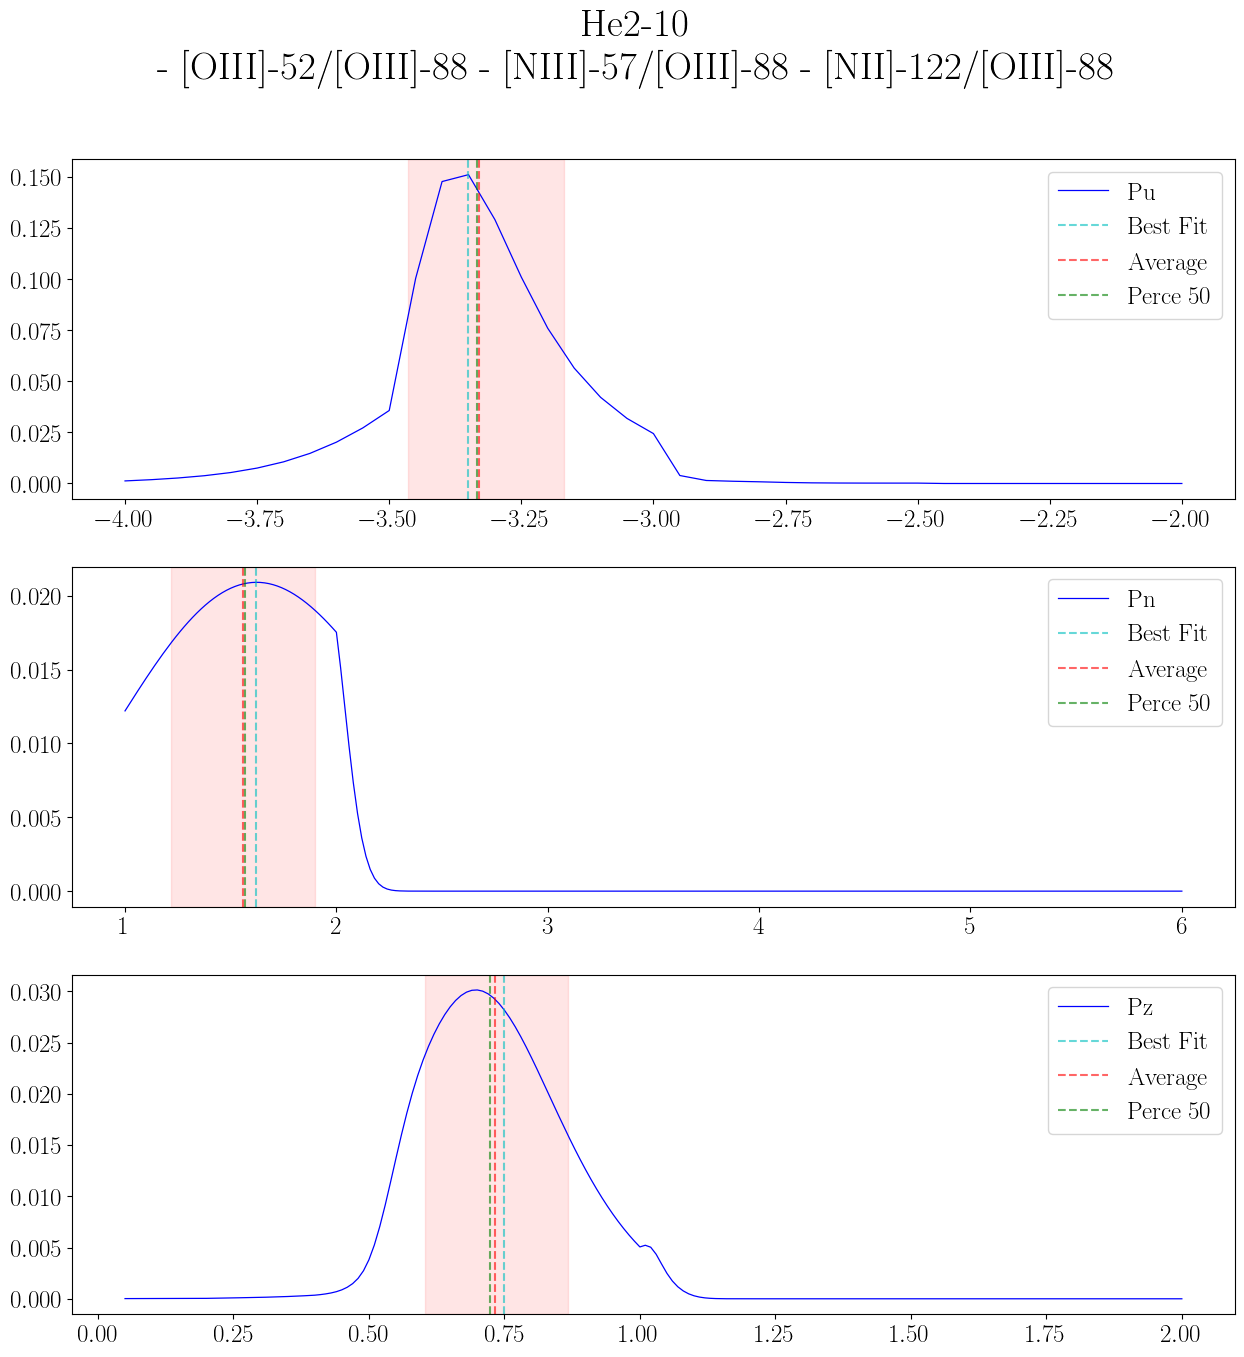

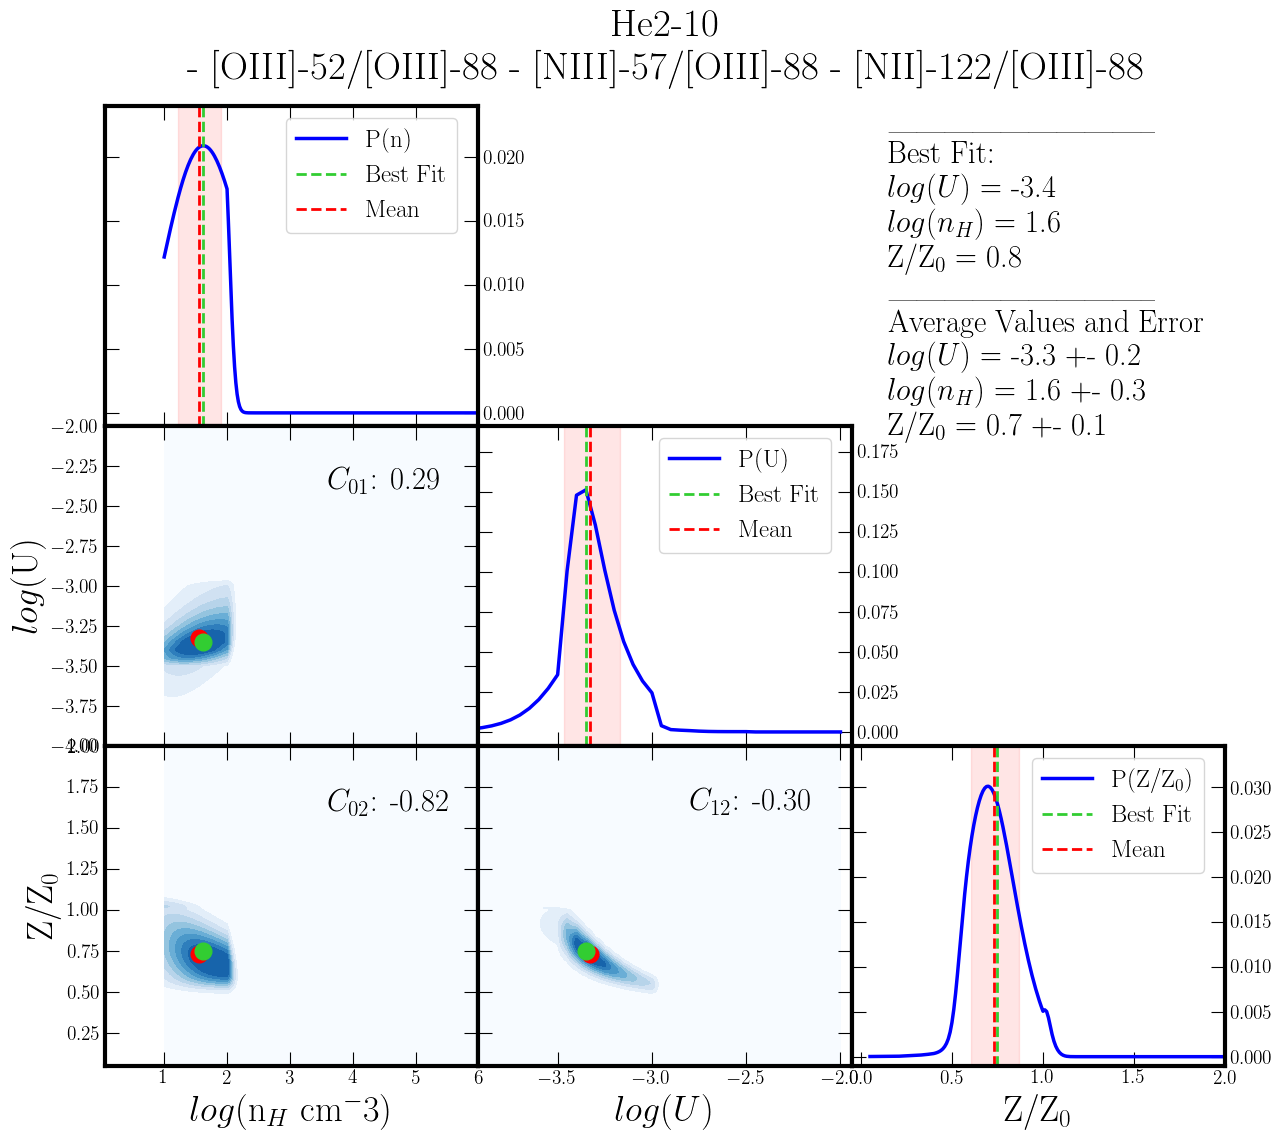




 ----------------------------running 2/9

 Results will be written in files:
/Users/admin/Scripts/GalaxyISM_0914/Plots/20240314_He2-10__Pplots_Fx6_Mod-01
/Users/admin/Scripts/GalaxyISM_0914/Plots/20240314_He2-10__Tplots_Fx6_Mod-01
UNZ_He-2-10_a_20240314.txt



 Y_obs [ 0.7817  0.2943  0.0614  2.6561 12.7273  4.7917 16.2821  3.3979 10.1316] 
 Y_sig [0.1706 0.0625 0.013  0.5792 2.775  1.0169 3.4574 0.7217 2.6832]

 Selected lines: 
 Y_obs: [ 0.7817  0.2943  0.0614  2.6561 12.7273  4.7917 16.2821  3.3979 10.1316] 
 Y_sig [1.7056e-01 1.0000e+06 1.0000e+06 1.0000e+06 1.0000e+06 1.0000e+06
 3.4574e+00 7.2168e-01 1.0000e+06]

Lines:   
 - [OIII]-52/[OIII]-88 - [OIII]-88/[NII]-122 - [OIII]-88/[NIII]-57 
 - OIII52/OIII88- OIII88/NII122- OIII88/NIII57
(5, 6, 5, 9)
u 5 41 10
n 6 251 50
z 5 196 48
(41, 251, 196, 9)


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:00<00:00,  7.50it/s]


Models Cube Shape:  (5, 6, 5, 9)  Interpolate to Size: [ 41 251 196] 



 z: [0.05 0.2  0.4  1.   2.  ] (5,)

 new z 
 Shape: (196,)


New Cube shape:  (41, 251, 196, 9)

 u shape: (41,) 
 n shape: (251,) 
 z shape: (196,)
Models refined shape:   (41, 251, 196, 9)
Chi shape:    (41, 251, 196, 9)
Chi^2 shape:  (41, 251, 196, 9) 	 Sum Chi^2 = 0.0E+00
Prob Shape:   (41, 251, 196) 	 Sum Prob = 1.00000E+00
Chi^2_min = 1.67E-02 
Chi^2_max = 0.00000E+00
Prob Dimensions: Pn (251,)  Pu (41,) Pz (196,)
BestSol Indexes: n-> [36] u-> [21] z-> [83] Chi_min^2 0.017
Parameters Dimensions  (251,)   (41,)   (196,)
_______________________________________________________________________

Best Fit 
 <n> = 1.72 		 <u> = -3.0500 		 <Z/Z> = 0.88
_______________________________________________________________________

Average Values, Standard Deviation
	 <u> = -3.2 +- 0.3  <n> = 1.5  +-  0.3 	 <Z/Z> = 1.0121  +-  0.1974
_______________________________________________________________________

Percentiles (Mean

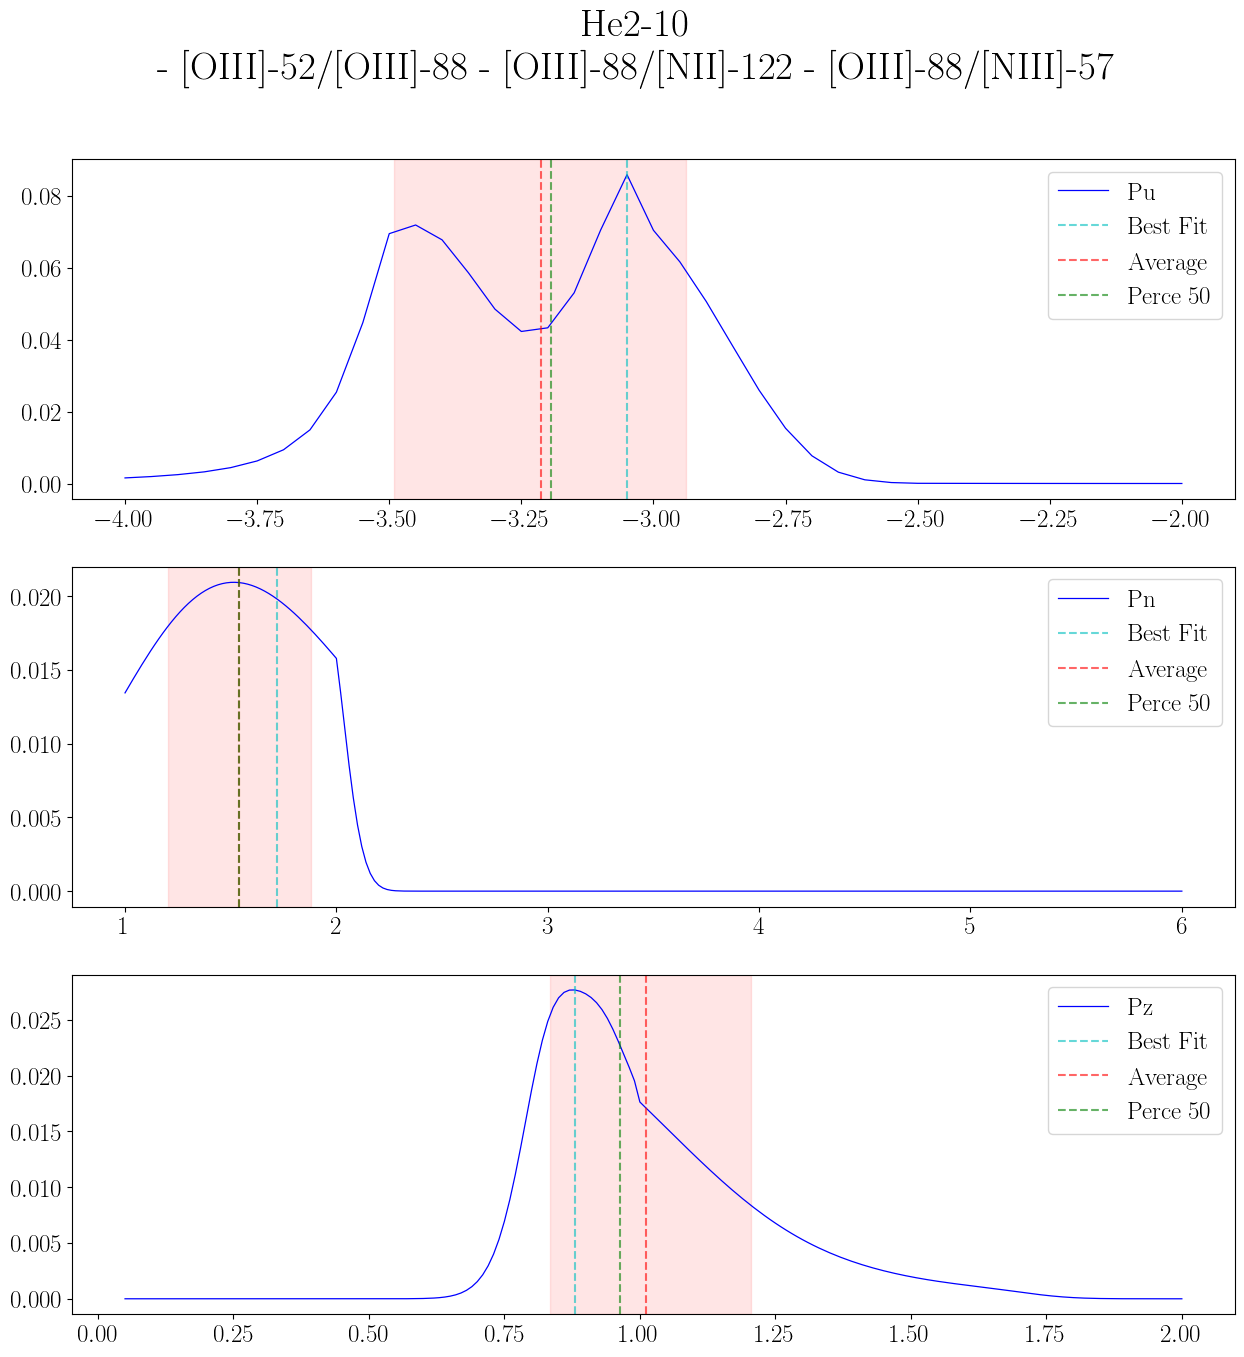

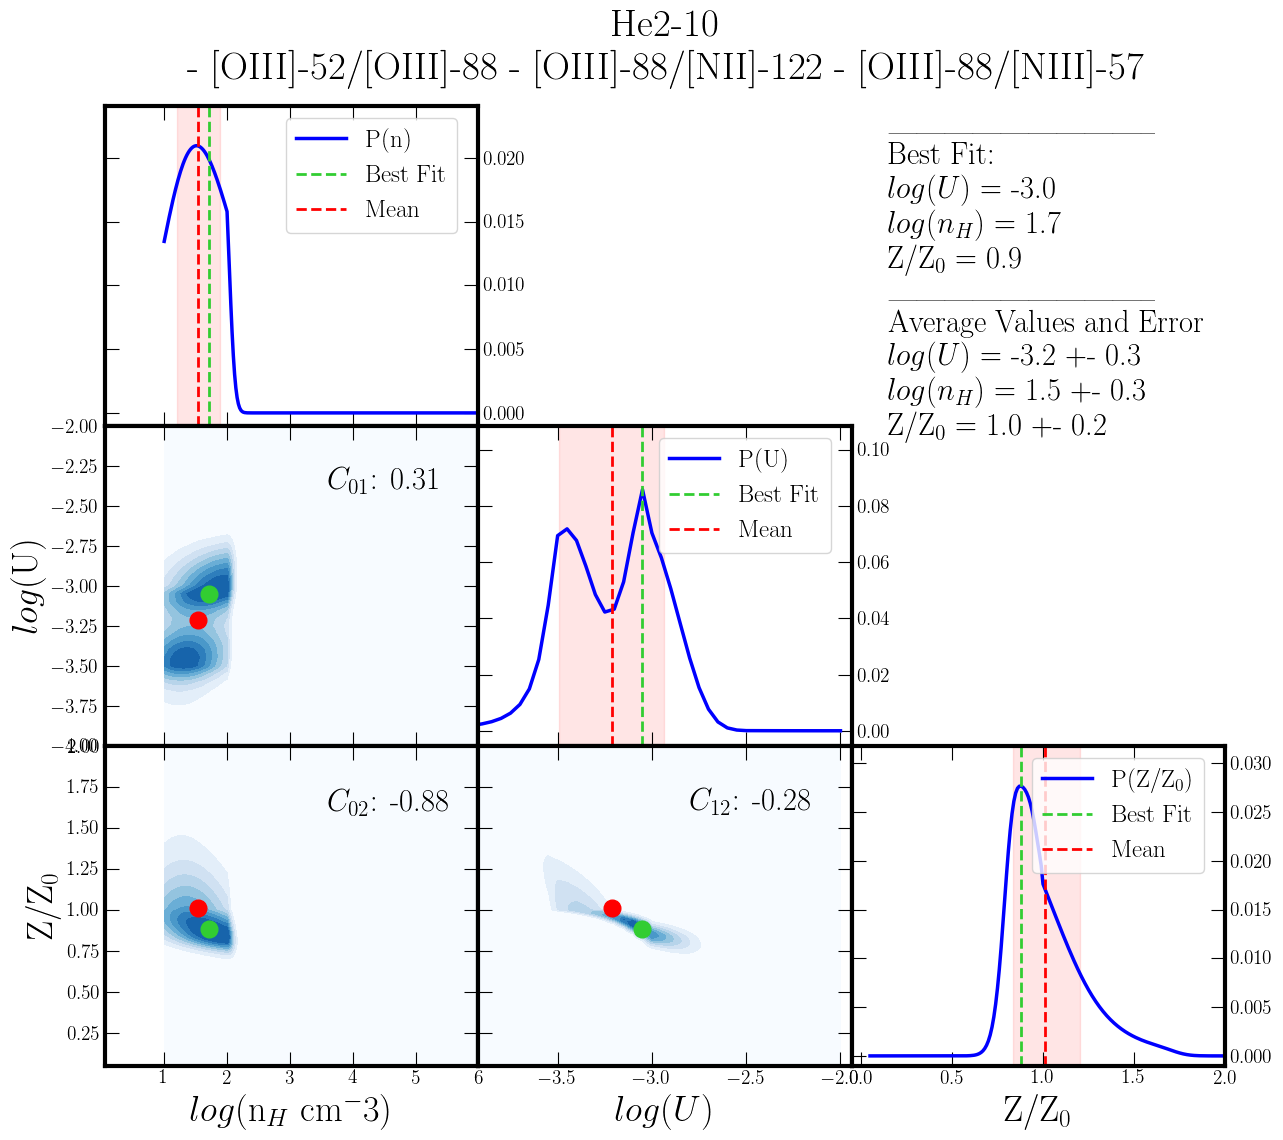




 ----------------------------running 3/9

 Results will be written in files:
/Users/admin/Scripts/GalaxyISM_0914/Plots/20240314_He2-10__Pplots_Fx6_Mod-02
/Users/admin/Scripts/GalaxyISM_0914/Plots/20240314_He2-10__Tplots_Fx6_Mod-02
UNZ_He-2-10_a_20240314.txt



 Y_obs [ 0.7817  0.2943  0.0614  2.6561 12.7273  4.7917 16.2821  3.3979 10.1316] 
 Y_sig [0.1706 0.0625 0.013  0.5792 2.775  1.0169 3.4574 0.7217 2.6832]

 Selected lines: 
 Y_obs: [ 0.7817  0.2943  0.0614  2.6561 12.7273  4.7917 16.2821  3.3979 10.1316] 
 Y_sig [1.7056e-01 1.0000e+06 1.0000e+06 1.0000e+06 1.0000e+06 1.0000e+06
 1.0000e+06 1.0000e+06 2.6832e+00]

Lines:   
 - [OIII]-52/[OIII]-88 - (2.2x[OIII]-88+[OIII]-52)/[NIII]-57 
 - OIII52/OIII88- (2.2OIII88+OIII52)/NIII57
(5, 6, 5, 9)
u 5 41 10
n 6 251 50
z 5 196 48
(41, 251, 196, 9)


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:00<00:00,  7.32it/s]


Models Cube Shape:  (5, 6, 5, 9)  Interpolate to Size: [ 41 251 196] 



 z: [0.05 0.2  0.4  1.   2.  ] (5,)

 new z 
 Shape: (196,)


New Cube shape:  (41, 251, 196, 9)

 u shape: (41,) 
 n shape: (251,) 
 z shape: (196,)
Models refined shape:   (41, 251, 196, 9)
Chi shape:    (41, 251, 196, 9)
Chi^2 shape:  (41, 251, 196, 9) 	 Sum Chi^2 = 0.0E+00
Prob Shape:   (41, 251, 196) 	 Sum Prob = 1.00000E+00
Chi^2_min = 6.01E-05 
Chi^2_max = 0.00000E+00
Prob Dimensions: Pn (251,)  Pu (41,) Pz (196,)
BestSol Indexes: n-> [41] u-> [1] z-> [77] Chi_min^2 0.000
Parameters Dimensions  (251,)   (41,)   (196,)
_______________________________________________________________________

Best Fit 
 <n> = 1.82 		 <u> = -2.0500 		 <Z/Z> = 0.82
_______________________________________________________________________

Average Values, Standard Deviation
	 <u> = -3.0 +- 0.6  <n> = 1.6  +-  0.3 	 <Z/Z> = 1.0124  +-  0.2409
_______________________________________________________________________

Percentiles (Mean)

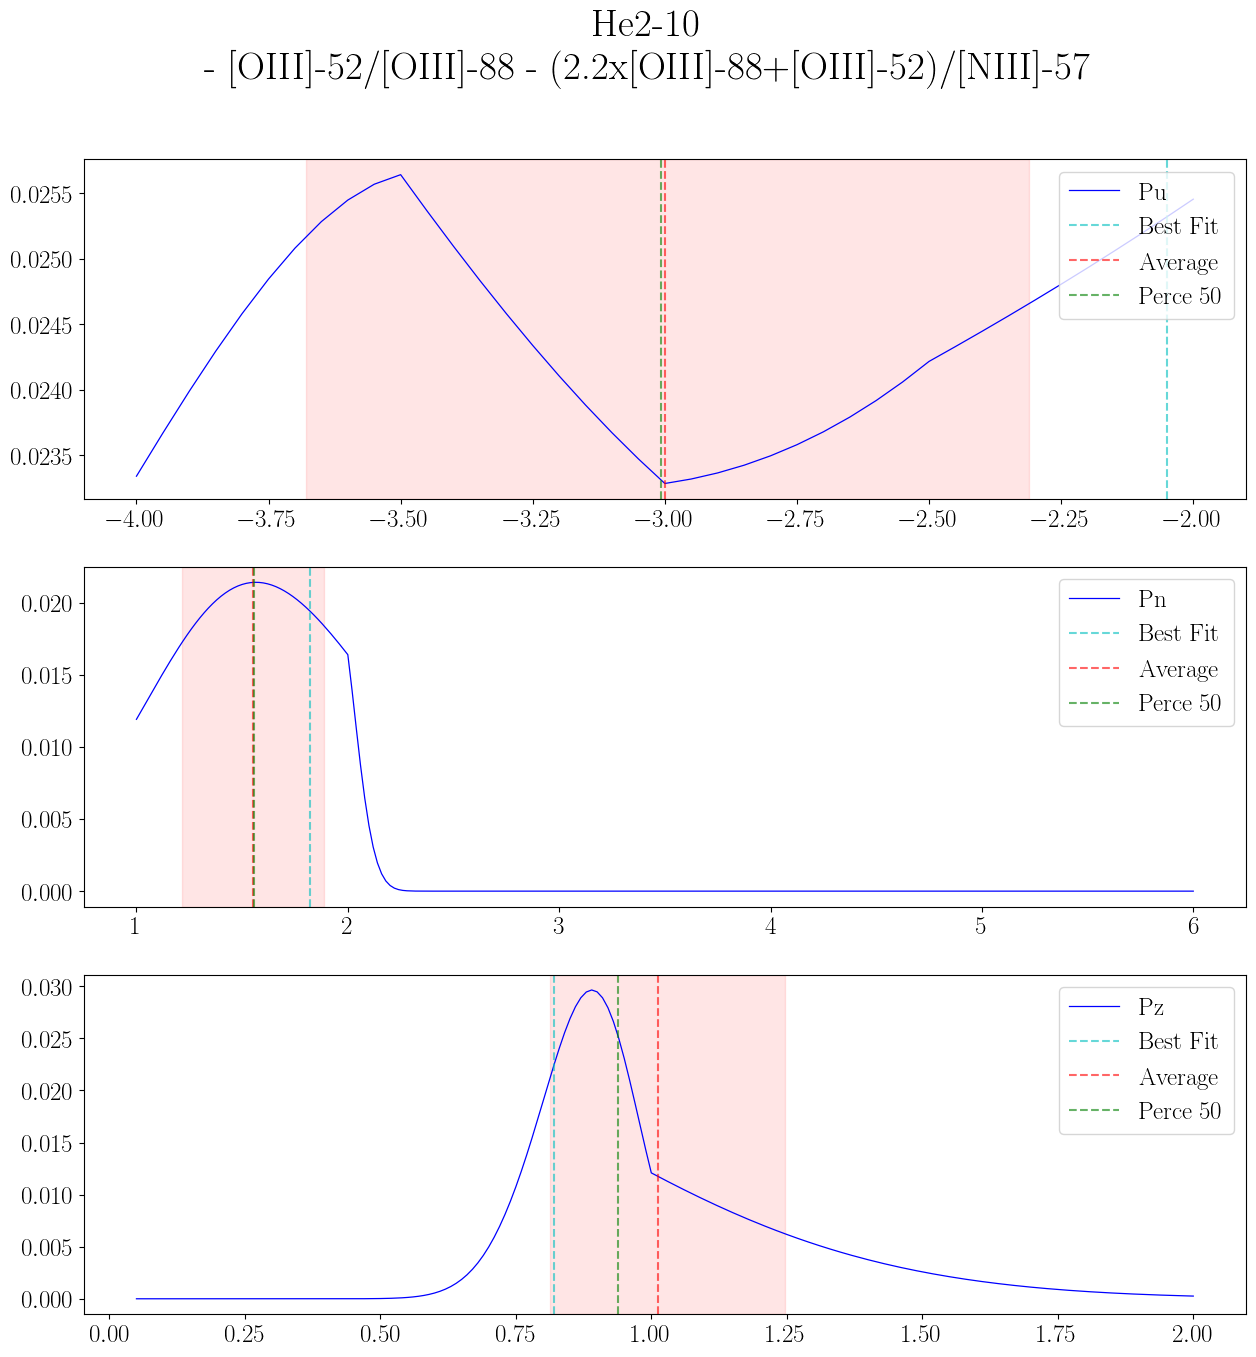

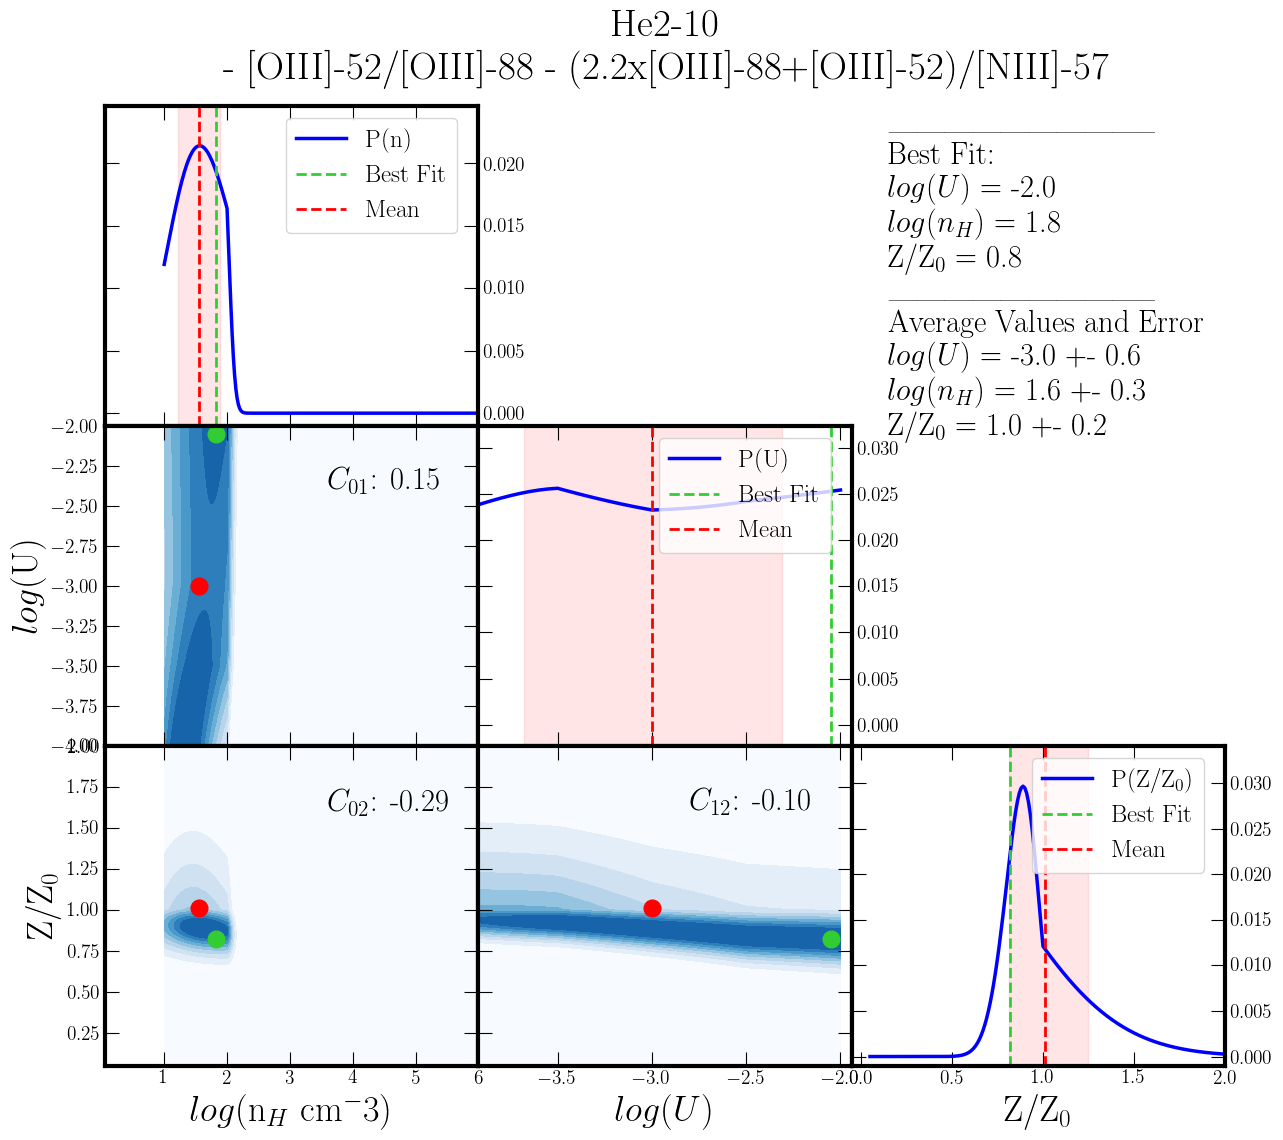




 ----------------------------running 4/9

 Results will be written in files:
/Users/admin/Scripts/GalaxyISM_0914/Plots/20240314_He2-10__Pplots_Fx6_Mod-03
/Users/admin/Scripts/GalaxyISM_0914/Plots/20240314_He2-10__Tplots_Fx6_Mod-03
UNZ_He-2-10_a_20240314.txt



 Y_obs [ 0.7817  0.2943  0.0614  2.6561 12.7273  4.7917 16.2821  3.3979 10.1316] 
 Y_sig [0.1706 0.0625 0.013  0.5792 2.775  1.0169 3.4574 0.7217 2.6832]

 Selected lines: 
 Y_obs: [ 0.7817  0.2943  0.0614  2.6561 12.7273  4.7917 16.2821  3.3979 10.1316] 
 Y_sig [1.7056e-01 6.2505e-02 1.0000e+06 1.0000e+06 1.0000e+06 1.0000e+06
 1.0000e+06 1.0000e+06 1.0000e+06]

Lines:   
 - [OIII]-52/[OIII]-88 - [NIII]-57/[OIII]-88 
 - OIII52/OIII88- NIII57/OIII88
(5, 6, 5, 9)
u 5 41 10
n 6 251 50
z 5 196 48
(41, 251, 196, 9)


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:00<00:00,  6.05it/s]


Models Cube Shape:  (5, 6, 5, 9)  Interpolate to Size: [ 41 251 196] 



 z: [0.05 0.2  0.4  1.   2.  ] (5,)

 new z 
 Shape: (196,)


New Cube shape:  (41, 251, 196, 9)

 u shape: (41,) 
 n shape: (251,) 
 z shape: (196,)
Models refined shape:   (41, 251, 196, 9)
Chi shape:    (41, 251, 196, 9)
Chi^2 shape:  (41, 251, 196, 9) 	 Sum Chi^2 = 0.0E+00
Prob Shape:   (41, 251, 196) 	 Sum Prob = 1.00000E+00
Chi^2_min = 1.54E-06 
Chi^2_max = 0.00000E+00
Prob Dimensions: Pn (251,)  Pu (41,) Pz (196,)
BestSol Indexes: n-> [34] u-> [25] z-> [67] Chi_min^2 0.000
Parameters Dimensions  (251,)   (41,)   (196,)
_______________________________________________________________________

Best Fit 
 <n> = 1.68 		 <u> = -3.2500 		 <Z/Z> = 0.72
_______________________________________________________________________

Average Values, Standard Deviation
	 <u> = -3.0 +- 0.6  <n> = 1.6  +-  0.3 	 <Z/Z> = 0.7048  +-  0.1222
_______________________________________________________________________

Percentiles (Mean

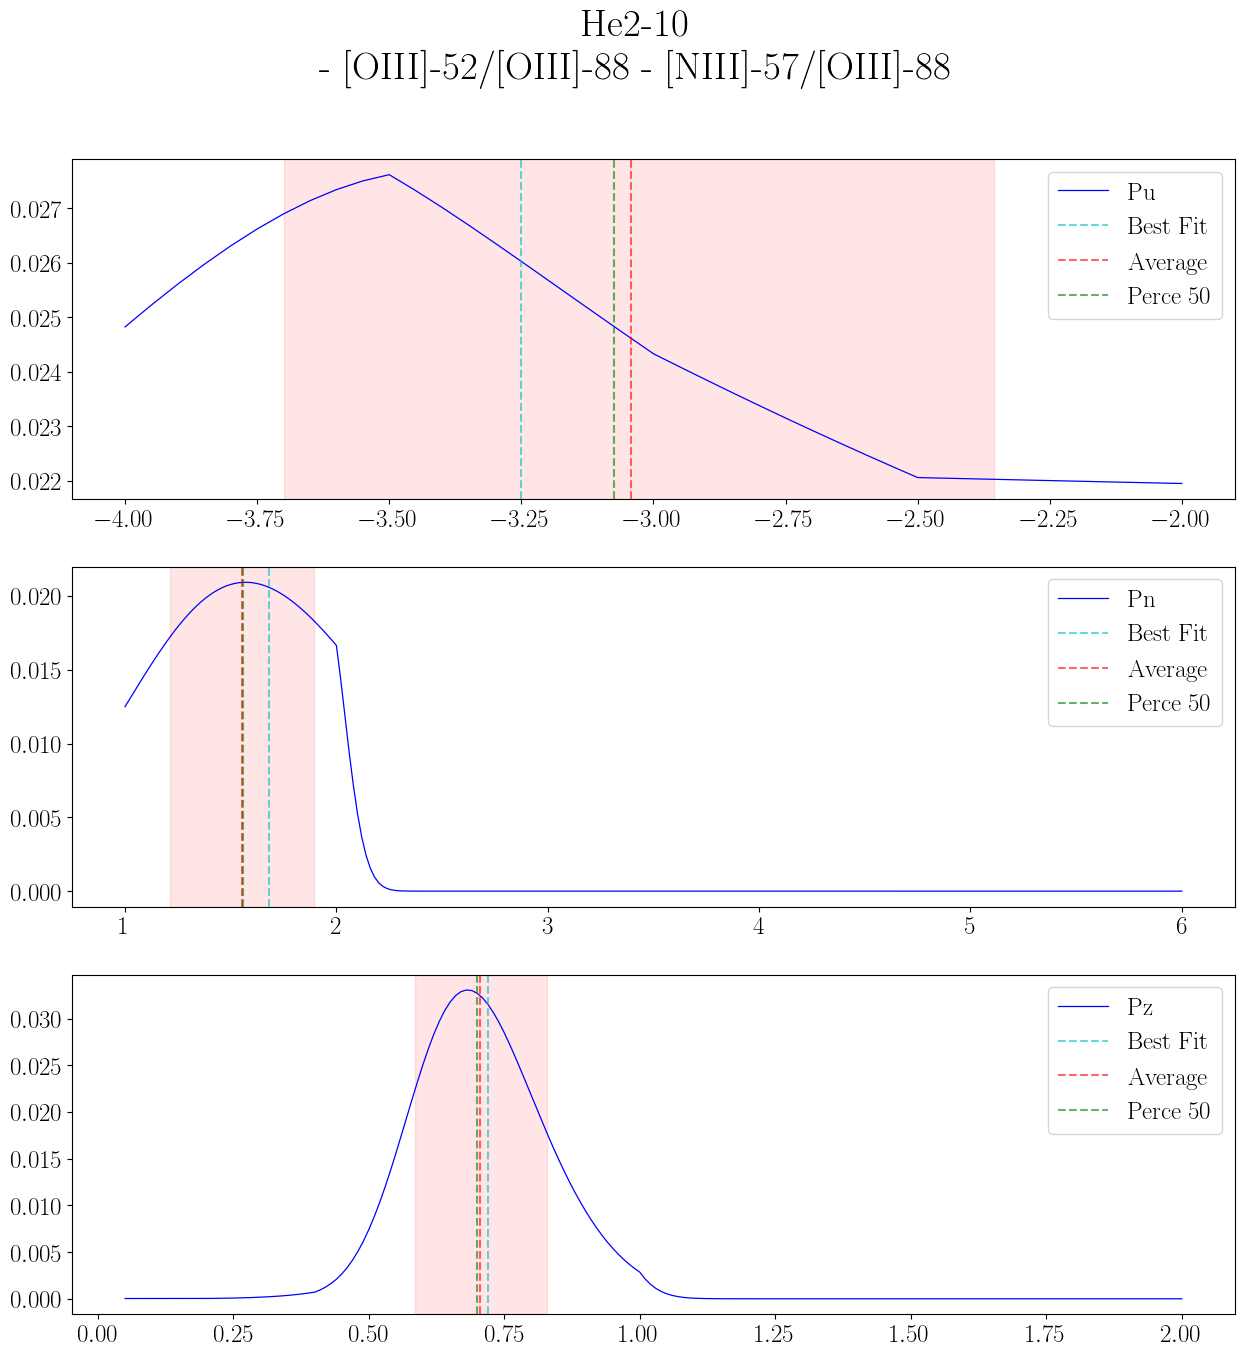

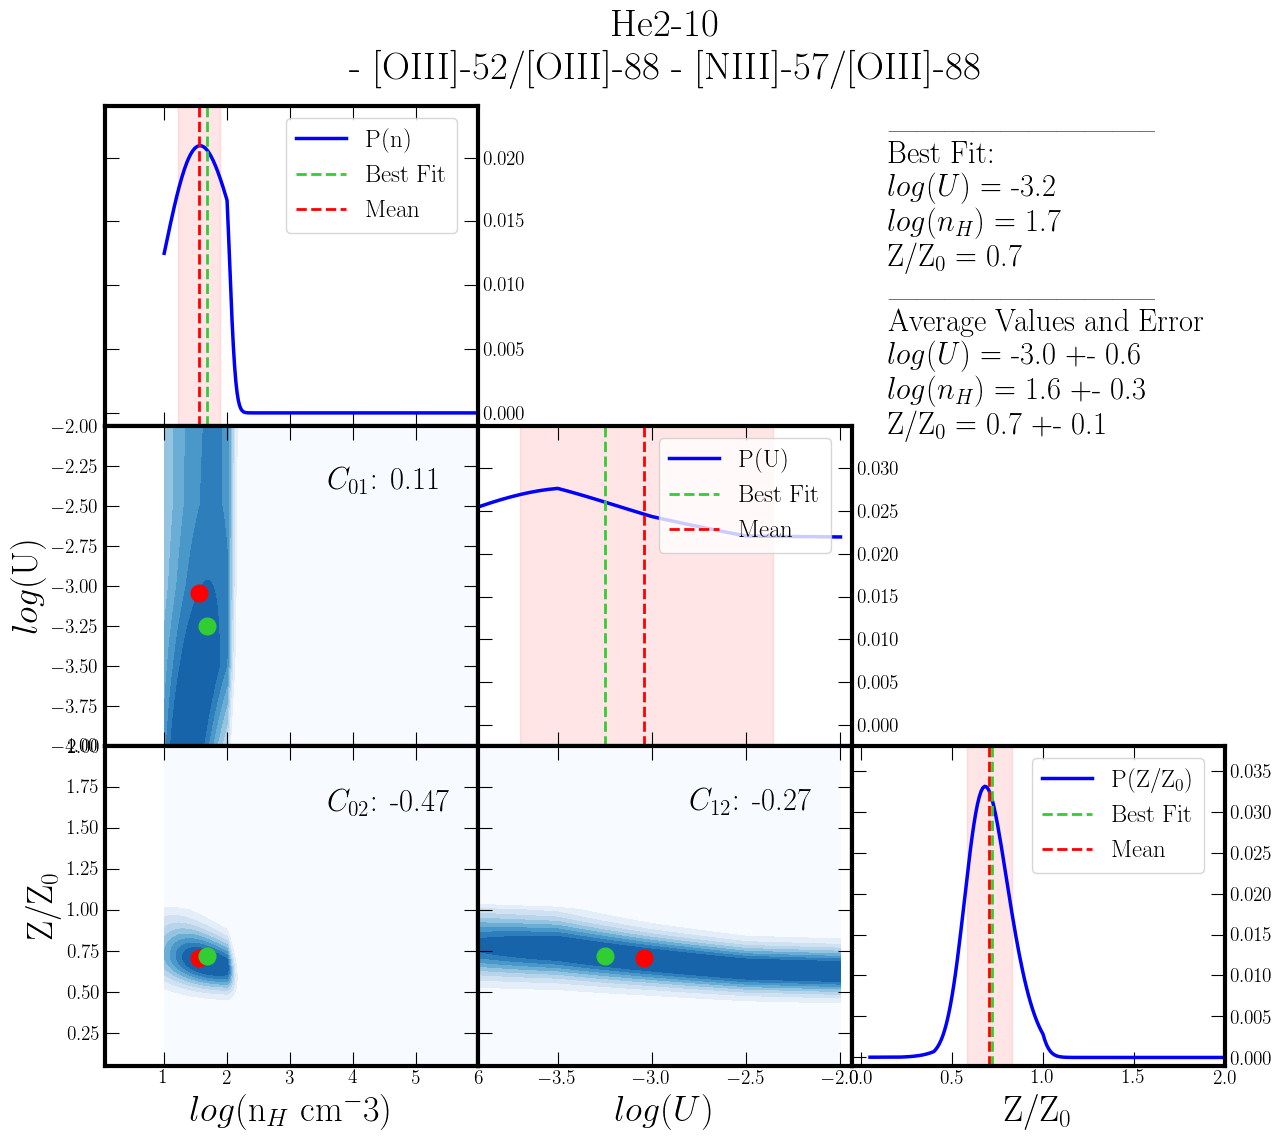




 ----------------------------running 5/9

 Results will be written in files:
/Users/admin/Scripts/GalaxyISM_0914/Plots/20240314_He2-10__Pplots_Fx6_Mod-04
/Users/admin/Scripts/GalaxyISM_0914/Plots/20240314_He2-10__Tplots_Fx6_Mod-04
UNZ_He-2-10_a_20240314.txt



 Y_obs [ 0.7817  0.2943  0.0614  2.6561 12.7273  4.7917 16.2821  3.3979 10.1316] 
 Y_sig [0.1706 0.0625 0.013  0.5792 2.775  1.0169 3.4574 0.7217 2.6832]

 Selected lines: 
 Y_obs: [ 0.7817  0.2943  0.0614  2.6561 12.7273  4.7917 16.2821  3.3979 10.1316] 
 Y_sig [1.7056e-01 1.0000e+06 1.3042e-02 1.0000e+06 1.0000e+06 1.0000e+06
 1.0000e+06 1.0000e+06 1.0000e+06]

Lines:   
 - [OIII]-52/[OIII]-88 - [NII]-122/[OIII]-88 
 - OIII52/OIII88- NII122/OIII88
(5, 6, 5, 9)
u 5 41 10
n 6 251 50
z 5 196 48
(41, 251, 196, 9)


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:00<00:00,  7.28it/s]


Models Cube Shape:  (5, 6, 5, 9)  Interpolate to Size: [ 41 251 196] 



 z: [0.05 0.2  0.4  1.   2.  ] (5,)

 new z 
 Shape: (196,)


New Cube shape:  (41, 251, 196, 9)

 u shape: (41,) 
 n shape: (251,) 
 z shape: (196,)
Models refined shape:   (41, 251, 196, 9)
Chi shape:    (41, 251, 196, 9)
Chi^2 shape:  (41, 251, 196, 9) 	 Sum Chi^2 = 0.0E+00
Prob Shape:   (41, 251, 196) 	 Sum Prob = 1.00000E+00
Chi^2_min = 3.70E-05 
Chi^2_max = 0.00000E+00
Prob Dimensions: Pn (251,)  Pu (41,) Pz (196,)
BestSol Indexes: n-> [34] u-> [26] z-> [64] Chi_min^2 0.000
Parameters Dimensions  (251,)   (41,)   (196,)
_______________________________________________________________________

Best Fit 
 <n> = 1.68 		 <u> = -3.3000 		 <Z/Z> = 0.69
_______________________________________________________________________

Average Values, Standard Deviation
	 <u> = -3.2 +- 0.4  <n> = 1.6  +-  0.3 	 <Z/Z> = 0.6087  +-  0.3184
_______________________________________________________________________

Percentiles (Mean

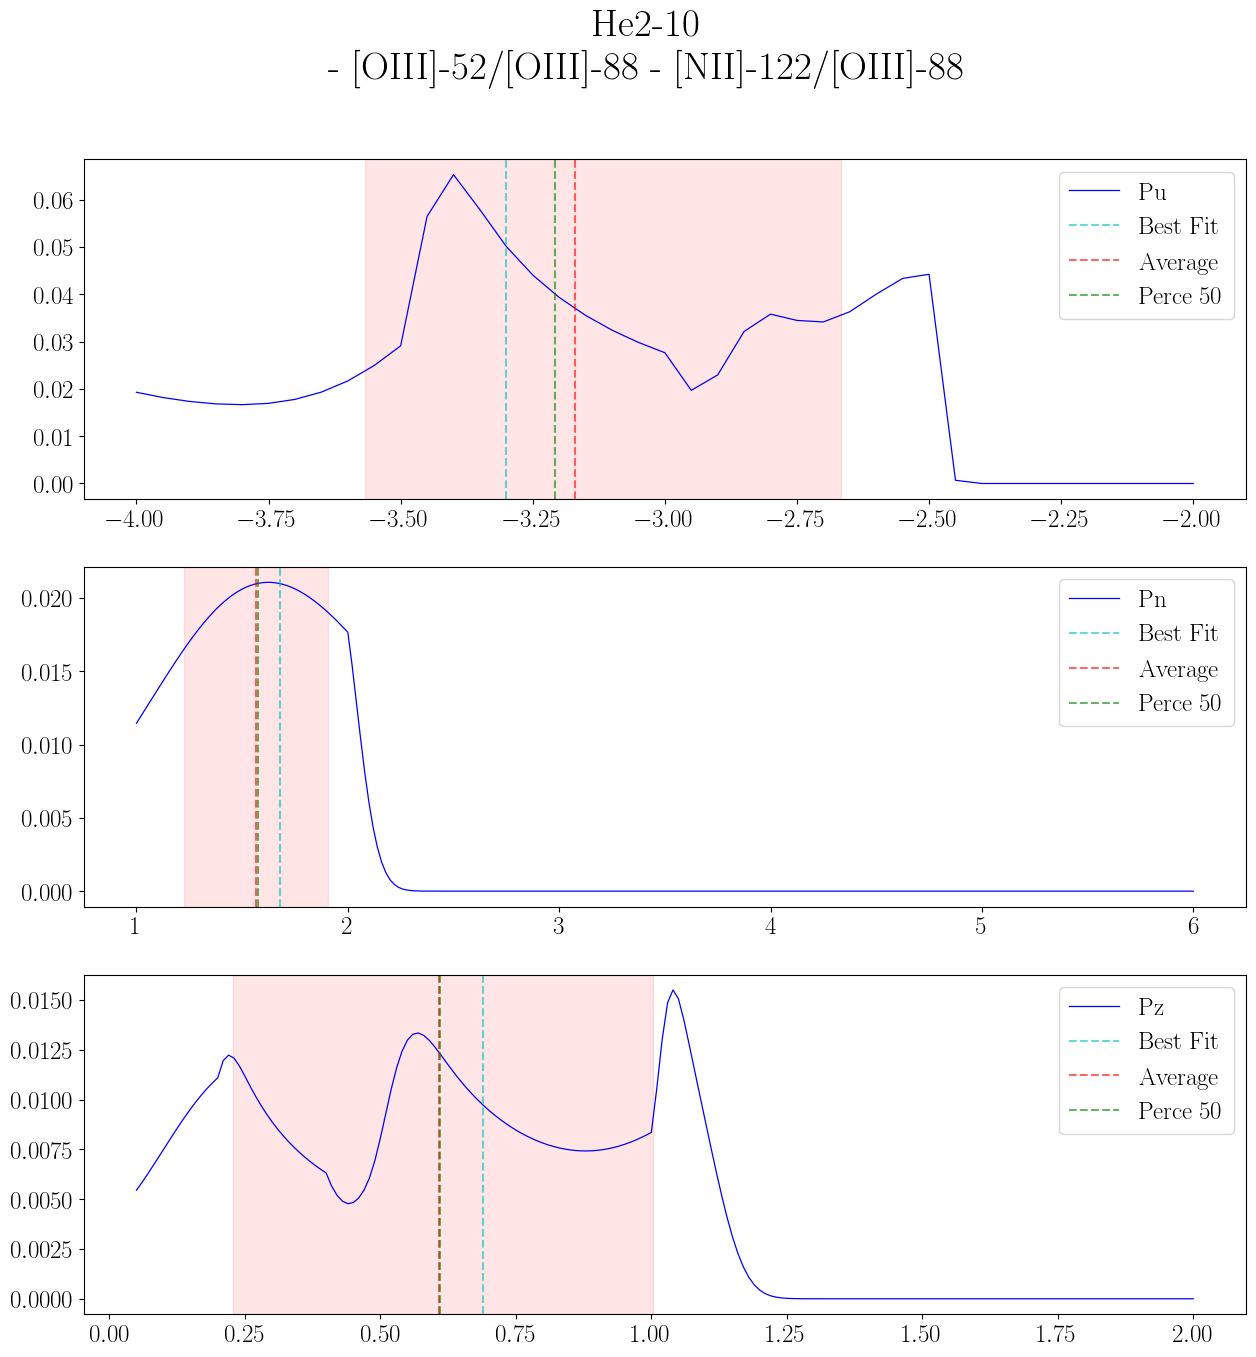

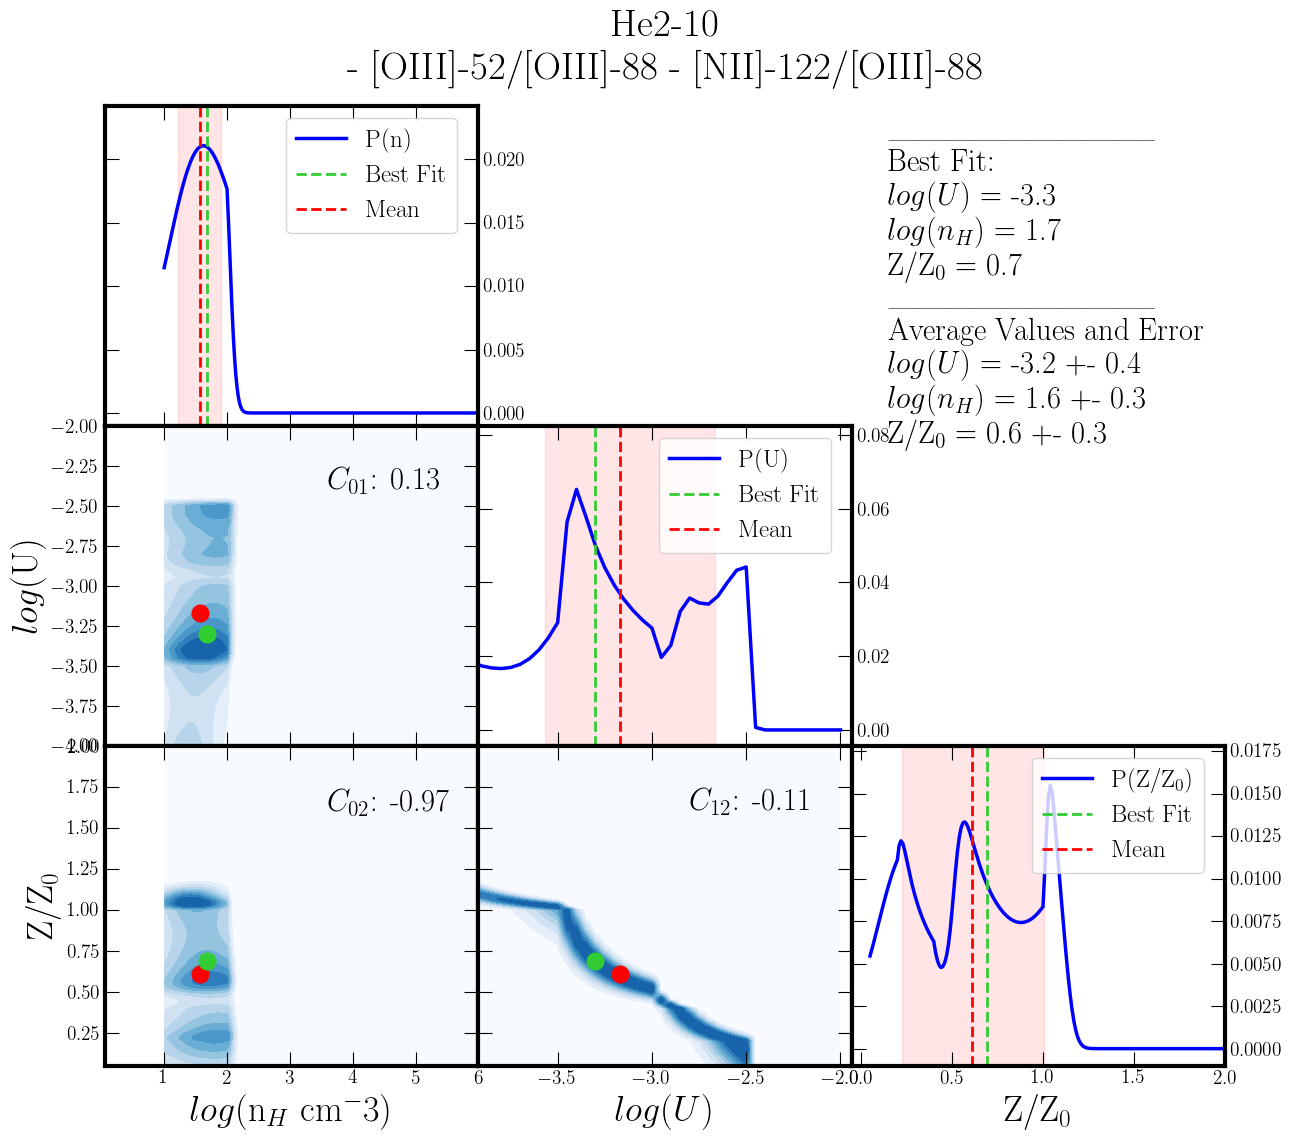




 ----------------------------running 6/9

 Results will be written in files:
/Users/admin/Scripts/GalaxyISM_0914/Plots/20240314_He2-10__Pplots_Fx6_Mod-05
/Users/admin/Scripts/GalaxyISM_0914/Plots/20240314_He2-10__Tplots_Fx6_Mod-05
UNZ_He-2-10_a_20240314.txt



 Y_obs [ 0.7817  0.2943  0.0614  2.6561 12.7273  4.7917 16.2821  3.3979 10.1316] 
 Y_sig [0.1706 0.0625 0.013  0.5792 2.775  1.0169 3.4574 0.7217 2.6832]

 Selected lines: 
 Y_obs: [ 0.7817  0.2943  0.0614  2.6561 12.7273  4.7917 16.2821  3.3979 10.1316] 
 Y_sig [1.7056e-01 1.0000e+06 1.0000e+06 1.0000e+06 1.0000e+06 1.0000e+06
 3.4574e+00 1.0000e+06 1.0000e+06]

Lines:   
 - [OIII]-52/[OIII]-88 - [OIII]-88/[NII]-122 
 - OIII52/OIII88- OIII88/NII122
(5, 6, 5, 9)
u 5 41 10
n 6 251 50
z 5 196 48
(41, 251, 196, 9)


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:00<00:00,  7.74it/s]


Models Cube Shape:  (5, 6, 5, 9)  Interpolate to Size: [ 41 251 196] 



 z: [0.05 0.2  0.4  1.   2.  ] (5,)

 new z 
 Shape: (196,)


New Cube shape:  (41, 251, 196, 9)

 u shape: (41,) 
 n shape: (251,) 
 z shape: (196,)
Models refined shape:   (41, 251, 196, 9)
Chi shape:    (41, 251, 196, 9)
Chi^2 shape:  (41, 251, 196, 9) 	 Sum Chi^2 = 0.0E+00
Prob Shape:   (41, 251, 196) 	 Sum Prob = 1.00000E+00
Chi^2_min = 7.52E-07 
Chi^2_max = 0.00000E+00
Prob Dimensions: Pn (251,)  Pu (41,) Pz (196,)
BestSol Indexes: n-> [28] u-> [30] z-> [117] Chi_min^2 0.000
Parameters Dimensions  (251,)   (41,)   (196,)
_______________________________________________________________________

Best Fit 
 <n> = 1.56 		 <u> = -3.5000 		 <Z/Z> = 1.22
_______________________________________________________________________

Average Values, Standard Deviation
	 <u> = -3.2 +- 0.5  <n> = 1.5  +-  0.3 	 <Z/Z> = 1.0080  +-  0.4975
_______________________________________________________________________

Percentiles (Mea

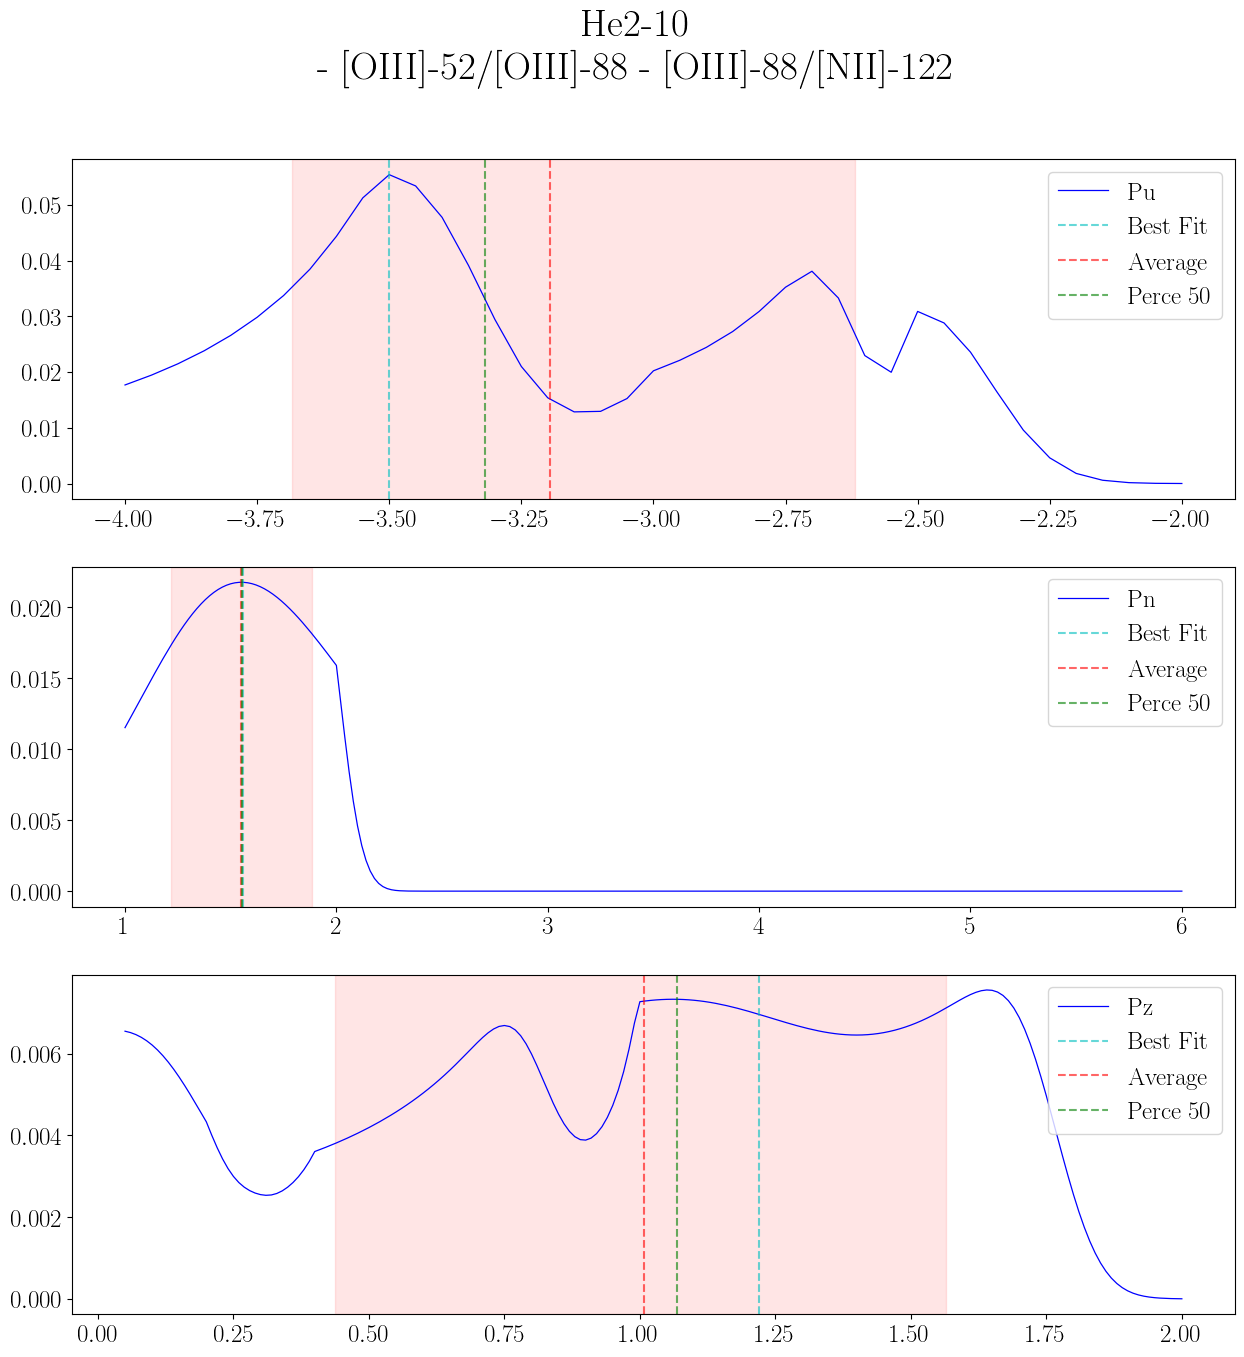

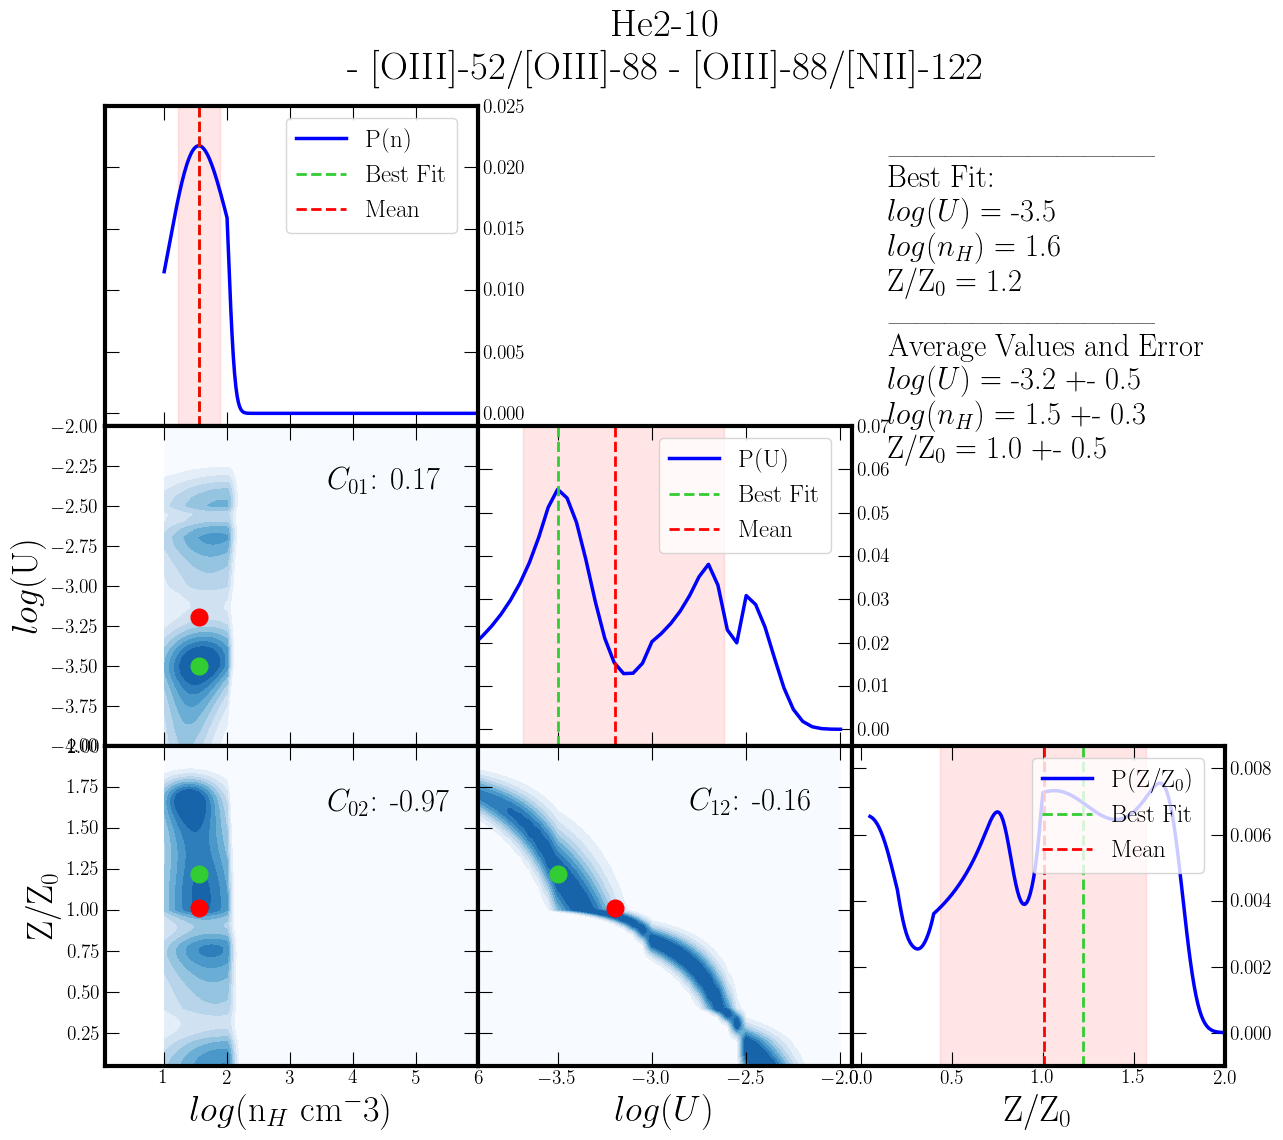




 ----------------------------running 7/9

 Results will be written in files:
/Users/admin/Scripts/GalaxyISM_0914/Plots/20240314_He2-10__Pplots_Fx6_Mod-06
/Users/admin/Scripts/GalaxyISM_0914/Plots/20240314_He2-10__Tplots_Fx6_Mod-06
UNZ_He-2-10_a_20240314.txt



 Y_obs [ 0.7817  0.2943  0.0614  2.6561 12.7273  4.7917 16.2821  3.3979 10.1316] 
 Y_sig [0.1706 0.0625 0.013  0.5792 2.775  1.0169 3.4574 0.7217 2.6832]

 Selected lines: 
 Y_obs: [ 0.7817  0.2943  0.0614  2.6561 12.7273  4.7917 16.2821  3.3979 10.1316] 
 Y_sig [1.0000e+06 6.2505e-02 1.3042e-02 1.0000e+06 1.0000e+06 1.0000e+06
 1.0000e+06 1.0000e+06 1.0000e+06]

Lines:   
 - [NIII]-57/[OIII]-88 - [NII]-122/[OIII]-88 
 - NIII57/OIII88- NII122/OIII88
(5, 6, 5, 9)
u 5 41 10
n 6 251 50
z 5 196 48
(41, 251, 196, 9)


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:00<00:00,  6.13it/s]


Models Cube Shape:  (5, 6, 5, 9)  Interpolate to Size: [ 41 251 196] 



 z: [0.05 0.2  0.4  1.   2.  ] (5,)

 new z 
 Shape: (196,)


New Cube shape:  (41, 251, 196, 9)

 u shape: (41,) 
 n shape: (251,) 
 z shape: (196,)
Models refined shape:   (41, 251, 196, 9)
Chi shape:    (41, 251, 196, 9)
Chi^2 shape:  (41, 251, 196, 9) 	 Sum Chi^2 = 0.0E+00
Prob Shape:   (41, 251, 196) 	 Sum Prob = 1.00000E+00
Chi^2_min = 7.18E-05 
Chi^2_max = 0.00000E+00
Prob Dimensions: Pn (251,)  Pu (41,) Pz (196,)
BestSol Indexes: n-> [221] u-> [19] z-> [25] Chi_min^2 0.000
Parameters Dimensions  (251,)   (41,)   (196,)
_______________________________________________________________________

Best Fit 
 <n> = 5.42 		 <u> = -2.9500 		 <Z/Z> = 0.30
_______________________________________________________________________

Average Values, Standard Deviation
	 <u> = -3.1 +- 0.3  <n> = 3.5  +-  1.7 	 <Z/Z> = 0.4789  +-  0.2305
_______________________________________________________________________

Percentiles (Mea

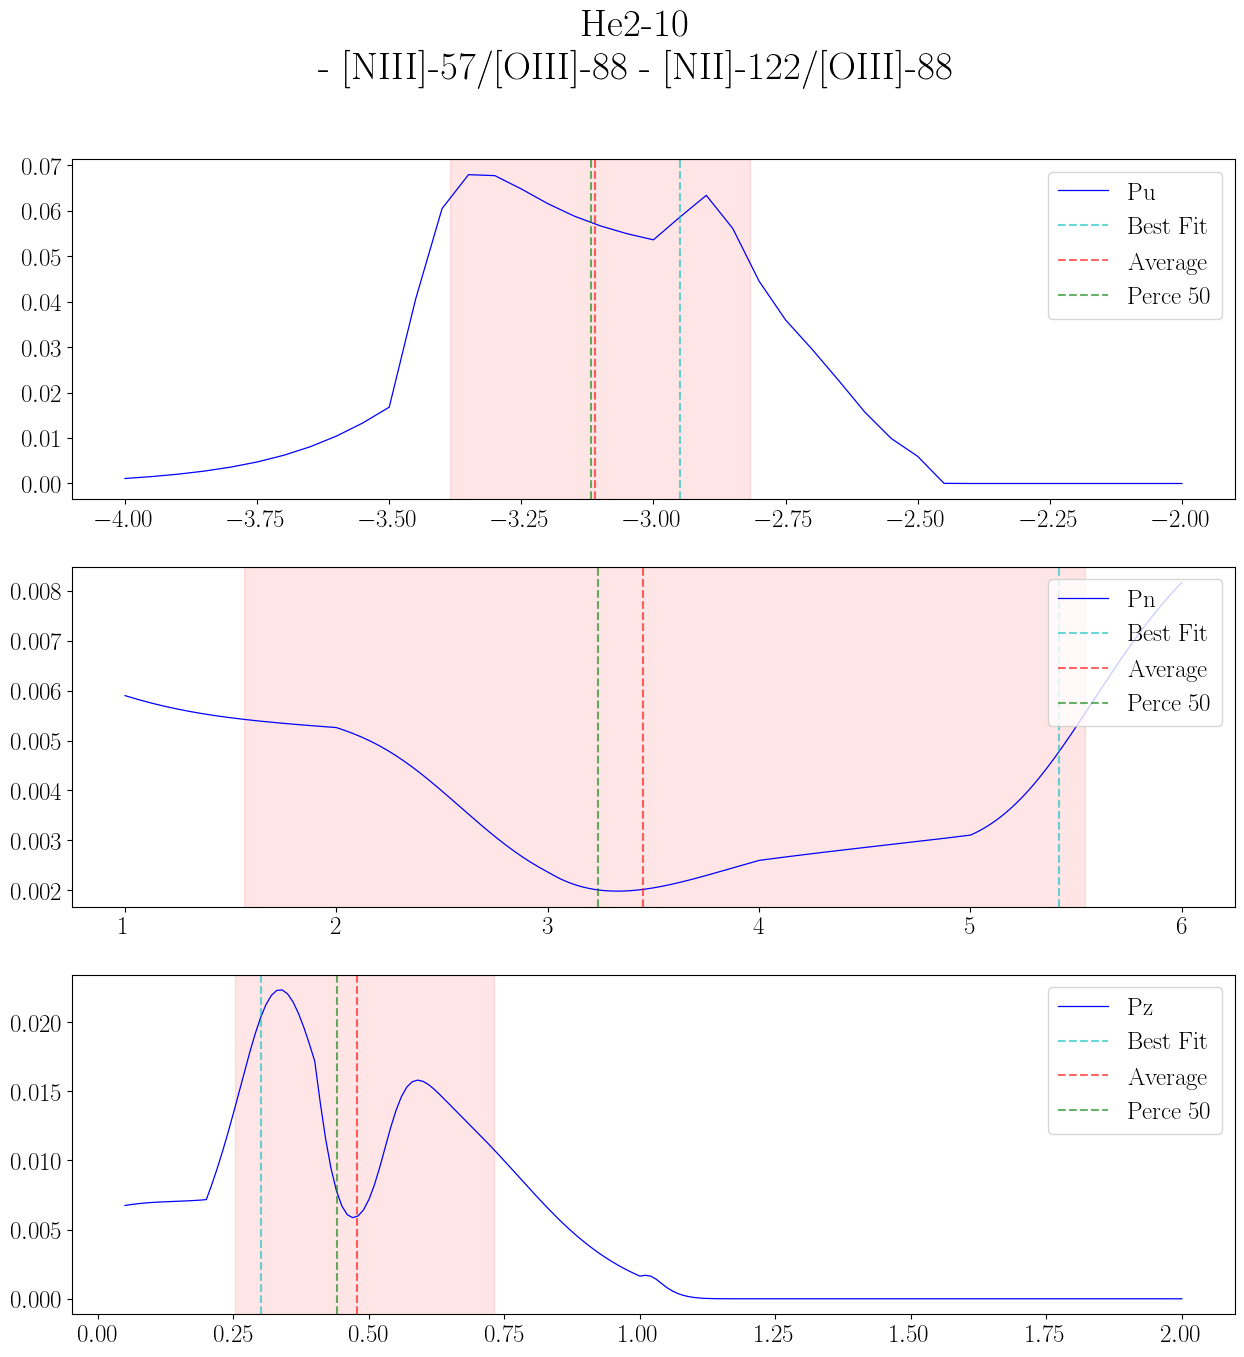

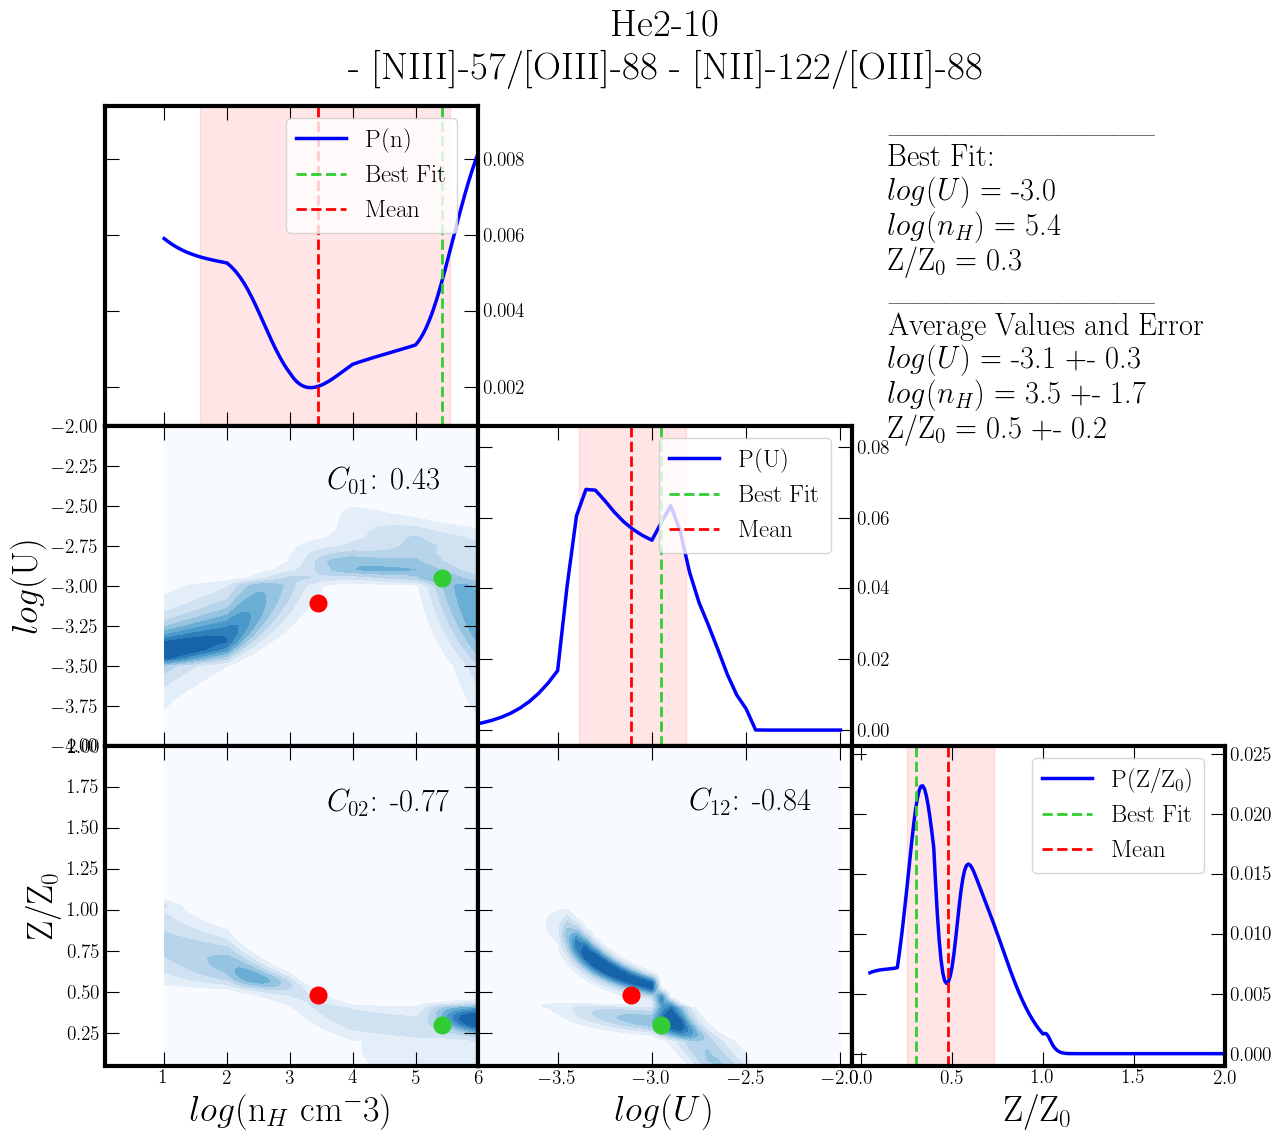




 ----------------------------running 8/9

 Results will be written in files:
/Users/admin/Scripts/GalaxyISM_0914/Plots/20240314_He2-10__Pplots_Fx6_Mod-07
/Users/admin/Scripts/GalaxyISM_0914/Plots/20240314_He2-10__Tplots_Fx6_Mod-07
UNZ_He-2-10_a_20240314.txt



 Y_obs [ 0.7817  0.2943  0.0614  2.6561 12.7273  4.7917 16.2821  3.3979 10.1316] 
 Y_sig [0.1706 0.0625 0.013  0.5792 2.775  1.0169 3.4574 0.7217 2.6832]

 Selected lines: 
 Y_obs: [ 0.7817  0.2943  0.0614  2.6561 12.7273  4.7917 16.2821  3.3979 10.1316] 
 Y_sig [1.0000e+06 1.0000e+06 1.0000e+06 1.0000e+06 1.0000e+06 1.0000e+06
 3.4574e+00 7.2168e-01 1.0000e+06]

Lines:   
 - [OIII]-88/[NII]-122 - [OIII]-88/[NIII]-57 
 - OIII88/NII122- OIII88/NIII57
(5, 6, 5, 9)
u 5 41 10
n 6 251 50
z 5 196 48
(41, 251, 196, 9)


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:00<00:00,  5.43it/s]


Models Cube Shape:  (5, 6, 5, 9)  Interpolate to Size: [ 41 251 196] 



 z: [0.05 0.2  0.4  1.   2.  ] (5,)

 new z 
 Shape: (196,)


New Cube shape:  (41, 251, 196, 9)

 u shape: (41,) 
 n shape: (251,) 
 z shape: (196,)
Models refined shape:   (41, 251, 196, 9)
Chi shape:    (41, 251, 196, 9)
Chi^2 shape:  (41, 251, 196, 9) 	 Sum Chi^2 = 0.0E+00
Prob Shape:   (41, 251, 196) 	 Sum Prob = 1.00000E+00
Chi^2_min = 2.21E-04 
Chi^2_max = 0.00000E+00
Prob Dimensions: Pn (251,)  Pu (41,) Pz (196,)
BestSol Indexes: n-> [120] u-> [14] z-> [49] Chi_min^2 0.000
Parameters Dimensions  (251,)   (41,)   (196,)
_______________________________________________________________________

Best Fit 
 <n> = 3.40 		 <u> = -2.7000 		 <Z/Z> = 0.54
_______________________________________________________________________

Average Values, Standard Deviation
	 <u> = -2.9 +- 0.3  <n> = 3.6  +-  1.6 	 <Z/Z> = 0.6455  +-  0.2902
_______________________________________________________________________

Percentiles (Mea

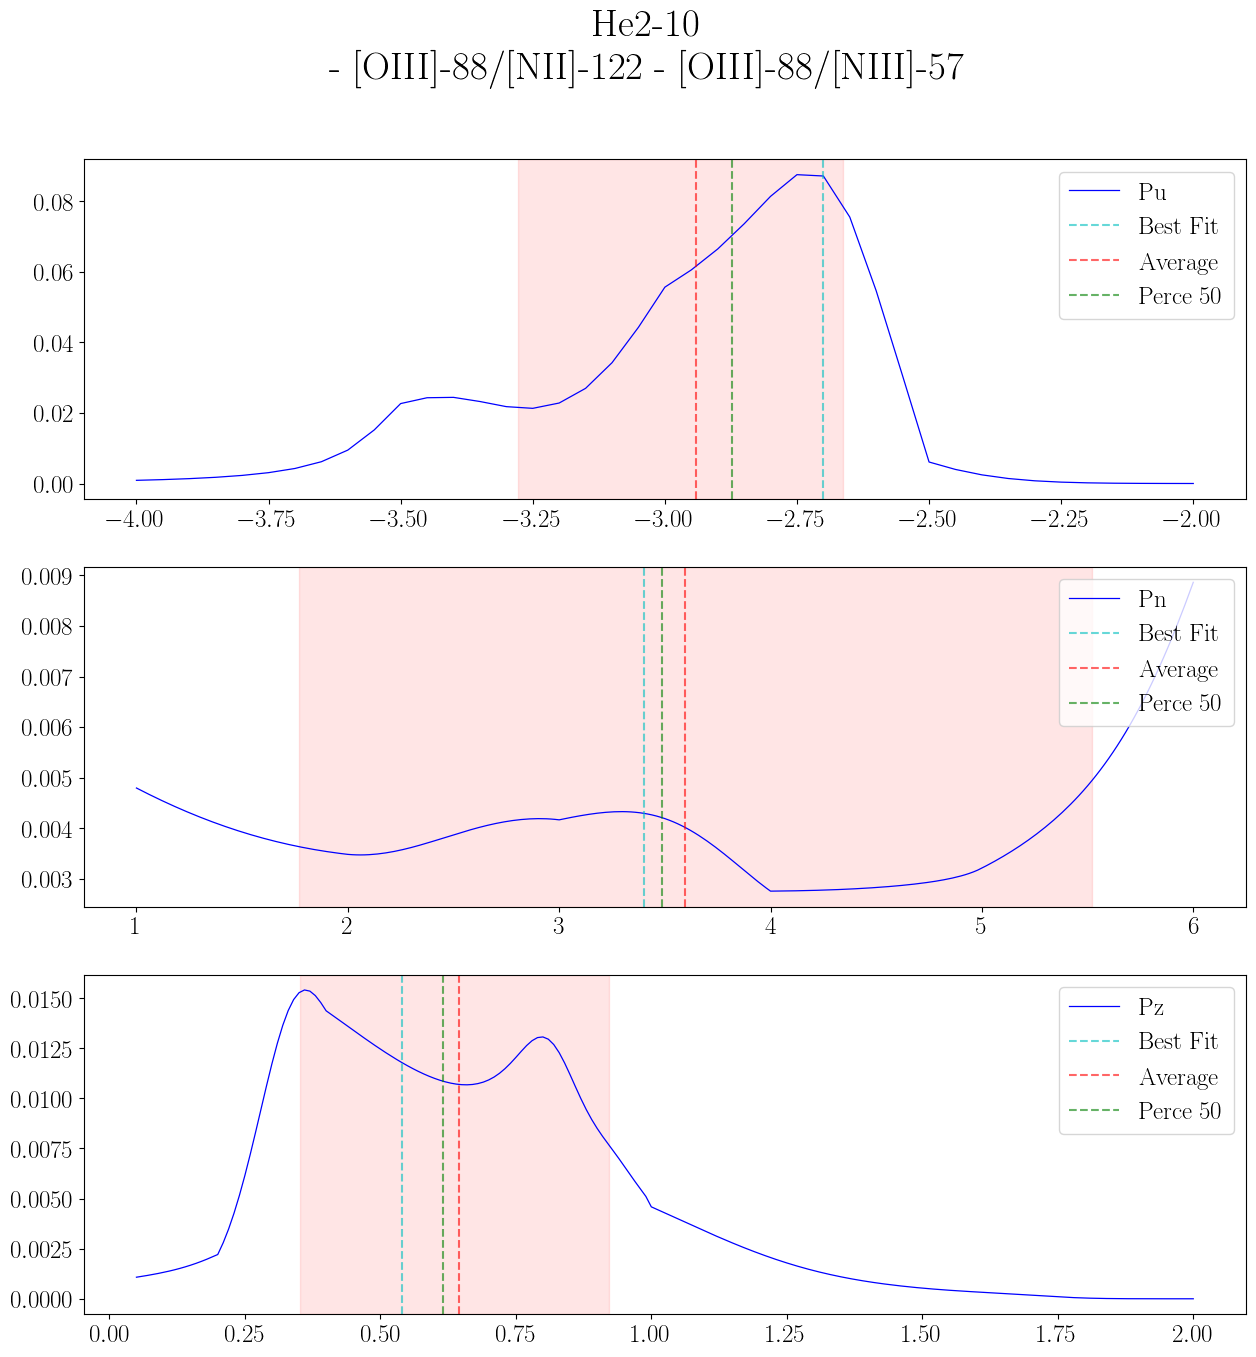

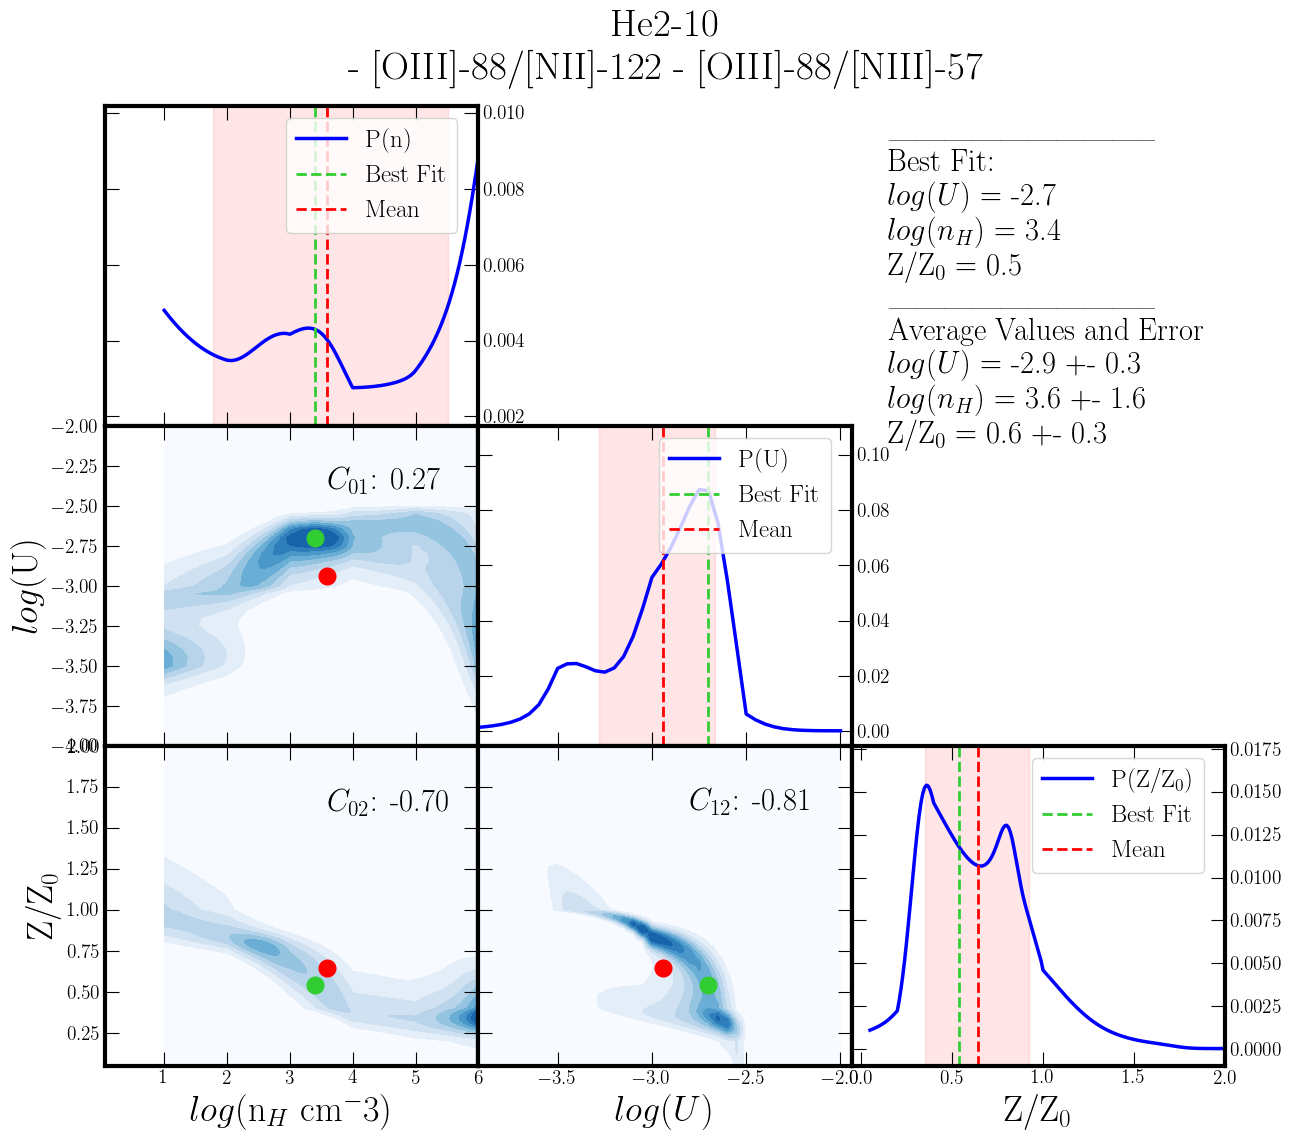




 ----------------------------running 9/9

 Results will be written in files:
/Users/admin/Scripts/GalaxyISM_0914/Plots/20240314_He2-10__Pplots_Fx6_Mod-08
/Users/admin/Scripts/GalaxyISM_0914/Plots/20240314_He2-10__Tplots_Fx6_Mod-08
UNZ_He-2-10_a_20240314.txt



 Y_obs [ 0.7817  0.2943  0.0614  2.6561 12.7273  4.7917 16.2821  3.3979 10.1316] 
 Y_sig [0.1706 0.0625 0.013  0.5792 2.775  1.0169 3.4574 0.7217 2.6832]

 Selected lines: 
 Y_obs: [ 0.7817  0.2943  0.0614  2.6561 12.7273  4.7917 16.2821  3.3979 10.1316] 
 Y_sig [1.0000e+06 1.0000e+06 1.3042e-02 1.0000e+06 1.0000e+06 1.0169e+00
 1.0000e+06 1.0000e+06 1.0000e+06]

Lines:   
 - [NII]-122/[OIII]-88 - [NIII]-57/[NII]-122 
 - NII122/OIII88- NIII57/NII122
(5, 6, 5, 9)
u 5 41 10
n 6 251 50
z 5 196 48
(41, 251, 196, 9)


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:00<00:00,  7.39it/s]


Models Cube Shape:  (5, 6, 5, 9)  Interpolate to Size: [ 41 251 196] 



 z: [0.05 0.2  0.4  1.   2.  ] (5,)

 new z 
 Shape: (196,)


New Cube shape:  (41, 251, 196, 9)

 u shape: (41,) 
 n shape: (251,) 
 z shape: (196,)
Models refined shape:   (41, 251, 196, 9)
Chi shape:    (41, 251, 196, 9)
Chi^2 shape:  (41, 251, 196, 9) 	 Sum Chi^2 = 0.0E+00
Prob Shape:   (41, 251, 196) 	 Sum Prob = 1.00000E+00
Chi^2_min = 1.88E-04 
Chi^2_max = 0.00000E+00
Prob Dimensions: Pn (251,)  Pu (41,) Pz (196,)
BestSol Indexes: n-> [247] u-> [20] z-> [23] Chi_min^2 0.000
Parameters Dimensions  (251,)   (41,)   (196,)
_______________________________________________________________________

Best Fit 
 <n> = 5.94 		 <u> = -3.0000 		 <Z/Z> = 0.28
_______________________________________________________________________

Average Values, Standard Deviation
	 <u> = -2.8 +- 0.2  <n> = 3.3  +-  1.5 	 <Z/Z> = 0.2819  +-  0.1498
_______________________________________________________________________

Percentiles (Mea

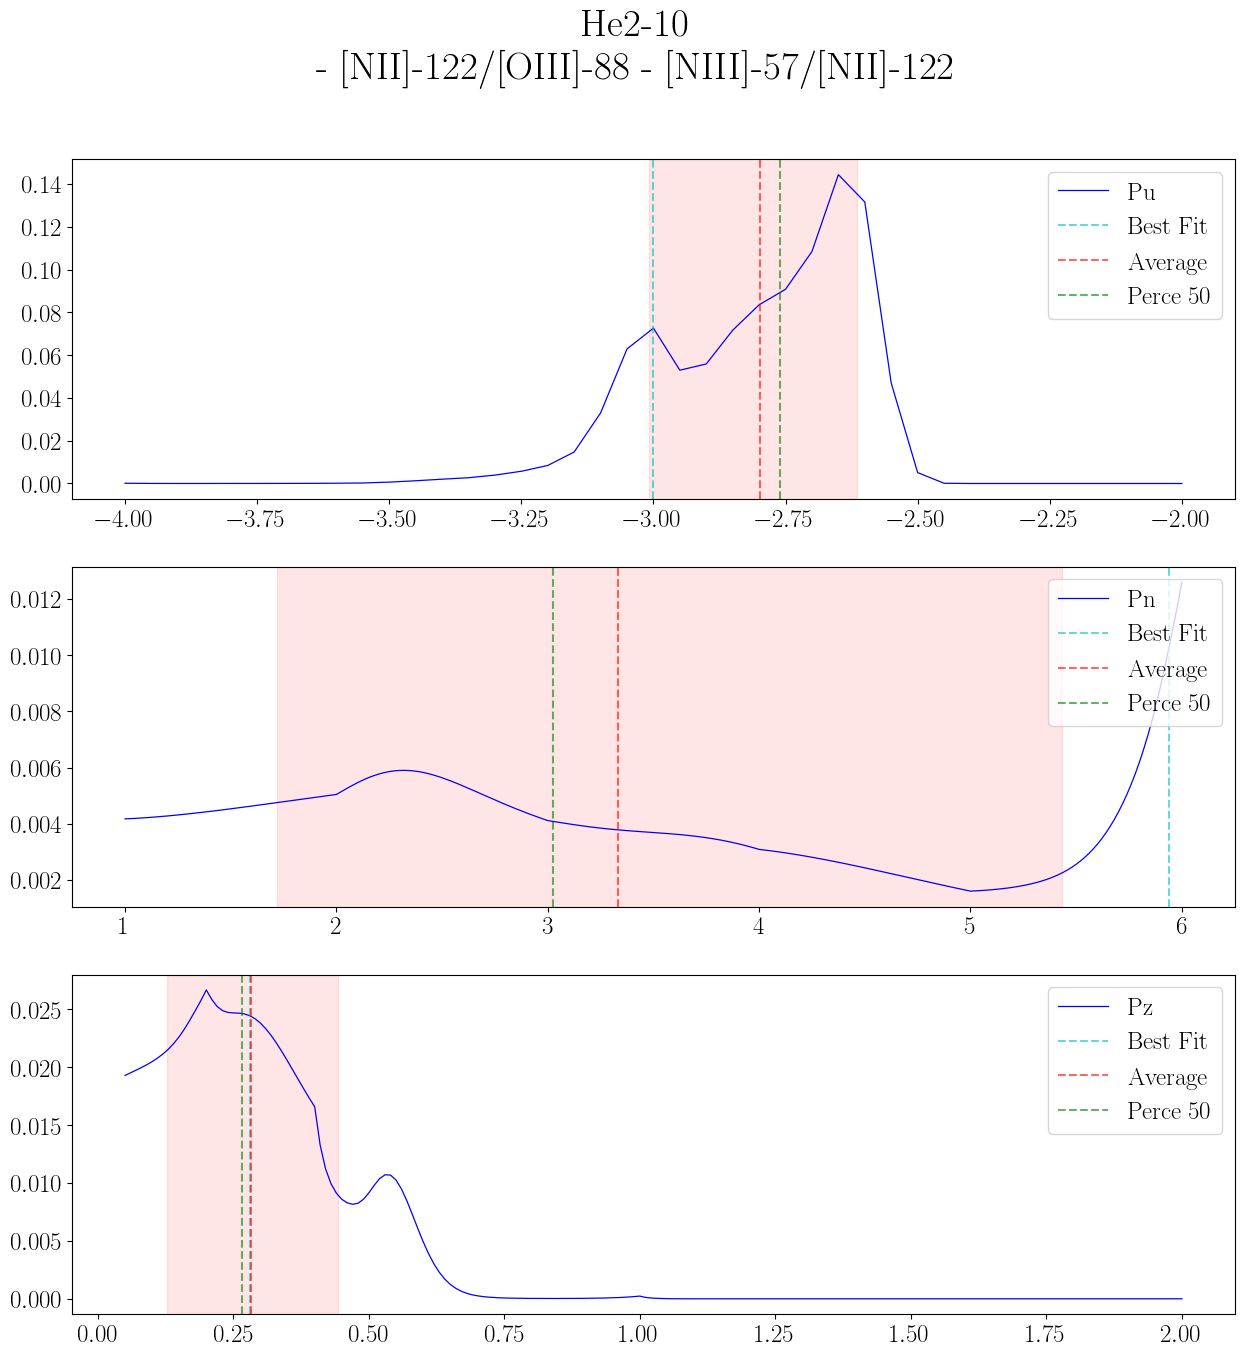

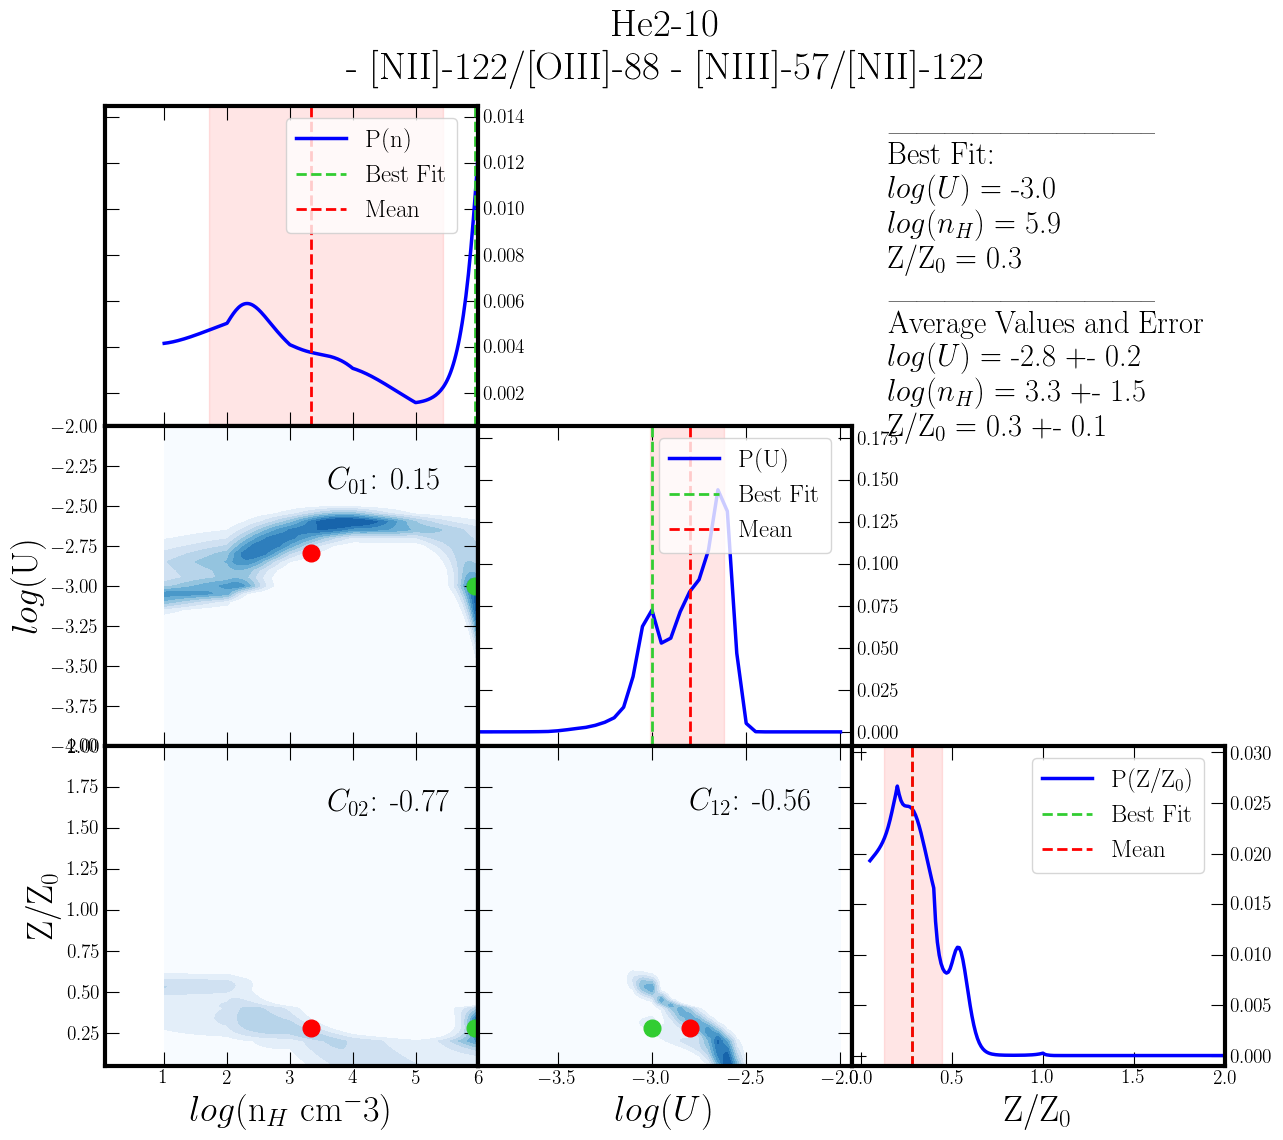

In [ ]:

# GALAXY Options for He2-10 
FluxData = '6'                 
name     = 'He2-10'
notes    = '--'+date+'-' 
gali     = int(FluxData) - 1

# ------------------------------------------------------
#       
#                Output Plots
#       create the SummaryFile headers
#
#------------------------------------------------------
#path_output =  '/Users/smotinof/Documents/Scripts/GalaxyISM/Plots/' 

createNewSummaryFile = True
SummaryFile = 'UNZ_He-2-10_a_'+date+'.txt'


if createNewSummaryFile:
    with open( path+SummaryFile, 'w') as f: # 'w' create new file, 'a' add to file
            f.write('Galaxy,Flux_ID,u_bs,n_bs,z_bs,u_mn,u_unc,n_mn,n_unc,z_mn,z_unc,u_50p,u_16p,u_84p,n_50p,n_16p,n_84p,z_50p,z_16p,z_84p,LinesRatiosUsed\n')
            f.close()

num_models = len(UseLinesArrays)
printgrids = False


for index in range(num_models):
    
        UseLines = UseLinesArrays[index]
        ModN = np.sum(UseLines) 
        strindex = str(index) 
        
        print('\n\n\n ----------------------------running '+str(index+1)+'/'+str(num_models))
        
        # Results table file:
        pltFileName1 = path+'Plots/'+date+'_'+name+'__Pplots_Fx'+str(FluxData)+'_Mod-0'+strindex
        pltFileName2 = path+'Plots/'+date+'_'+name+'__Tplots_Fx'+str(FluxData)+'_Mod-0'+strindex

        print('\n Results will be written in files:')
        print(pltFileName1)
        print(pltFileName2)
        print(SummaryFile)
        print('\n\n')

        #Old format
        #Y_obs, Y_sig, TxtLines , TxtLinesShort  = LineDataGalaxy(gali,Gal,UseLines)
        Y_obs, Y_sig, TxtLines , TxtLinesShort  = LineDataGalaxy2(gali,Gal,UseLines)
        Ny = len(Y_obs) #  Number of lines 

        # Run the model
        %run  "model-part-1.ipynb"


In [ ]:
Gal

,index,id,Galaxy,date,OIII52,OIII52_unc,OIII52_inst,OIII88,OIII88_unc,OIII88_inst,...,(2.2OIII88+OIII52)/NIII57,OIII52/OIII88_ERR,NIII57/OIII88_ERR,NII122/OIII88_ERR,OIII52/NIII57_ERR,OIII52/NII122_ERR,NIII57/NII122_ERR,OIII88/NII122_ERR,OIII88/NIII57_ERR,(2.2OIII88+OIII52)/NIII57_ERR
0,0,6,Haro 3,30-Nov,26.370,4.105604,FIFI,26.700,4.005012,PACS,...,41.517073,0.213523,0.016326,0.002099,2.787363,22.271398,1.703760,22.139526,2.769461,10.941491
1,1,7,Haro 10,30-Nov,86.373,13.131498,FIFI,109.918,16.487729,PACS,...,18.378933,0.167826,0.036421,0.001442,1.090972,24.706943,5.361537,31.229925,1.379967,4.978390
2,2,8,He 2-10,30-Nov,40.801,6.456266,FIFI,54.150,8.141100,AVG,...,10.436635,0.164463,0.060123,0.012544,0.580736,2.782039,1.016974,3.596421,0.750745,2.764746
3,3,9,Haro 3,15-Dec,26.524,4.112029,FIFI,26.704,4.005691,PACS,...,41.637109,0.214267,0.016303,0.002091,2.799412,22.442632,1.708381,22.231283,2.771773,10.954785
4,4,10,Haro 10,15-Dec,85.517,12.914374,FIFI,109.918,16.488447,PACS,...,54.556100,0.165603,0.021568,0.001442,5.636932,24.379372,3.174022,31.230605,7.238312,23.076570
5,5,11,He 2-10,15-Dec,40.702,6.439324,FIFI,52.070,7.824628,AVG,...,10.131558,0.170561,0.062505,0.013042,0.579227,2.774999,1.016901,3.457445,0.721682,2.683200



# 2 - Haro 03


In [ ]:


# GALAXY Options for Haro-03 
FluxData = '4' 
name     = 'Haro-03-'
notes    = '-a-'+date+'-' 
gali     = int(FluxData) - 1


# ------------------------------------------------------
#       
#                Output Plots
#       create the SummaryFile headers
#
#------------------------------------------------------
#path_output =  '/Users/smotinof/Documents/Scripts/GalaxyISM/Plots/' 

createNewSummaryFile = True
SummaryFile = 'UNZ_'+name+'a_'+date+'.txt'


if createNewSummaryFile:
    with open( path+SummaryFile, 'w') as f: # 'w' create new file, 'a' add to file
            f.write('Galaxy,Flux_ID,u_bs,n_bs,z_bs,u_mn,u_unc,n_mn,n_unc,z_mn,z_unc,u_50p,u_16p,u_84p,n_50p,n_16p,n_84p,z_50p,z_16p,z_84p,LinesRatiosUsed\n')
            f.close()

num_models = len(UseLinesArrays)
printgrids = False

for index in range(num_models):
        UseLines = UseLinesArrays[index]
        ModN = np.sum(UseLines) 
        strindex = str(index) 
        
        print('\n\n\n ----------------------------running '+str(index+1)+'/'+str(num_models))
        
        # Results table file:
        pltFileName1 = path+'Plots/'+date+'_'+name+'__Pplots_Fx'+str(FluxData)+'_Mod-0'+strindex
        pltFileName2 = path+'Plots/'+date+'_'+name+'__Tplots_Fx'+str(FluxData)+'_Mod-0'+strindex

        print('\n Results will be written in files:')
        print(pltFileName1)
        print(pltFileName2)
        print(SummaryFile)
        print('\n\n')

        #Old format
        #Y_obs, Y_sig, TxtLines , TxtLinesShort  = LineDataGalaxy(gali,Gal,UseLines)
        Y_obs, Y_sig, TxtLines , TxtLinesShort  = LineDataGalaxy2(gali,Gal,UseLines)
        Ny = len(Y_obs) #  Number of lines 

        # Run the model

        %run  "model-part-1.ipynb"




 ----------------------------running 1/8

 Results will be written in files:
/Users/admin/Desktop/GalaxyUNZ/GalaxyUNZ_toolPlots/20250110_Haro-03-__Pplots_Fx4_Mod-00
/Users/admin/Desktop/GalaxyUNZ/GalaxyUNZ_toolPlots/20250110_Haro-03-__Tplots_Fx4_Mod-00
UNZ_Haro-03-a_20250110.txt



 Y_obs [9.93e-01 7.67e-02 9.70e-03 1.30e+01 1.02e+02 7.91e+00 1.03e+02 1.30e+01
 4.16e+01] 
 Y_sig [2.14e-01 1.63e-02 2.09e-03 2.80e+00 2.24e+01 1.71e+00 2.22e+01 2.77e+00
 1.10e+01]

 Selected lines: 
 Y_obs: [9.93e-01 7.67e-02 9.70e-03 1.30e+01 1.02e+02 7.91e+00 1.03e+02 1.30e+01
 4.16e+01] 
 Y_sig [2.14e-01 1.63e-02 2.09e-03 1.00e+06 1.00e+06 1.00e+06 1.00e+06 1.00e+06
 1.00e+06]

Lines:   
 - [OIII]-52/[OIII]-88 - [NIII]-57/[OIII]-88 - [NII]-122/[OIII]-88 
 - OIII52/OIII88- NIII57/OIII88- NII122/OIII88


ModuleNotFoundError: No module named 'nbformat'


# 3 - Haro 10





 ----------------------------running 1/9

 Results will be written in files:
/Users/admin/Scripts/GalaxyISM_0914/Plots/20240314_Haro-10-__Pplots_Fx5_Mod-00
/Users/admin/Scripts/GalaxyISM_0914/Plots/20240314_Haro-10-__Tplots_Fx5_Mod-00
UNZ_Haro-10-a_20240314.txt



 Y_obs [7.7801e-01 5.4586e-02 6.7960e-03 1.4253e+01 1.1448e+02 8.0321e+00
 1.4715e+02 1.8320e+01 5.4556e+01] 
 Y_sig [1.6560e-01 2.1568e-02 1.4424e-03 5.6369e+00 2.4379e+01 3.1740e+00
 3.1231e+01 7.2383e+00 2.3077e+01]

 Selected lines: 
 Y_obs: [7.7801e-01 5.4586e-02 6.7960e-03 1.4253e+01 1.1448e+02 8.0321e+00
 1.4715e+02 1.8320e+01 5.4556e+01] 
 Y_sig [1.6560e-01 2.1568e-02 1.4424e-03 1.0000e+06 1.0000e+06 1.0000e+06
 1.0000e+06 1.0000e+06 1.0000e+06]

Lines:   
 - [OIII]-52/[OIII]-88 - [NIII]-57/[OIII]-88 - [NII]-122/[OIII]-88 
 - OIII52/OIII88- NIII57/OIII88- NII122/OIII88
(5, 6, 5, 9)
u 5 41 10
n 6 251 50
z 5 196 48
(41, 251, 196, 9)


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:00<00:00,  5.90it/s]


Models Cube Shape:  (5, 6, 5, 9)  Interpolate to Size: [ 41 251 196] 



 z: [0.05 0.2  0.4  1.   2.  ] (5,)

 new z 
 Shape: (196,)


New Cube shape:  (41, 251, 196, 9)

 u shape: (41,) 
 n shape: (251,) 
 z shape: (196,)
Models refined shape:   (41, 251, 196, 9)
Chi shape:    (41, 251, 196, 9)
Chi^2 shape:  (41, 251, 196, 9) 	 Sum Chi^2 = 0.0E+00
Prob Shape:   (41, 251, 196) 	 Sum Prob = 1.00000E+00
Chi^2_min = 1.18E-03 
Chi^2_max = 0.00000E+00
Prob Dimensions: Pn (251,)  Pu (41,) Pz (196,)
BestSol Indexes: n-> [43] u-> [23] z-> [11] Chi_min^2 0.001
Parameters Dimensions  (251,)   (41,)   (196,)
_______________________________________________________________________

Best Fit 
 <n> = 1.86 		 <u> = -3.1500 		 <Z/Z> = 0.16
_______________________________________________________________________

Average Values, Standard Deviation
	 <u> = -3.2 +- 0.1  <n> = 1.6  +-  0.3 	 <Z/Z> = 0.1775  +-  0.0865
_______________________________________________________________________

Percentiles (Mean

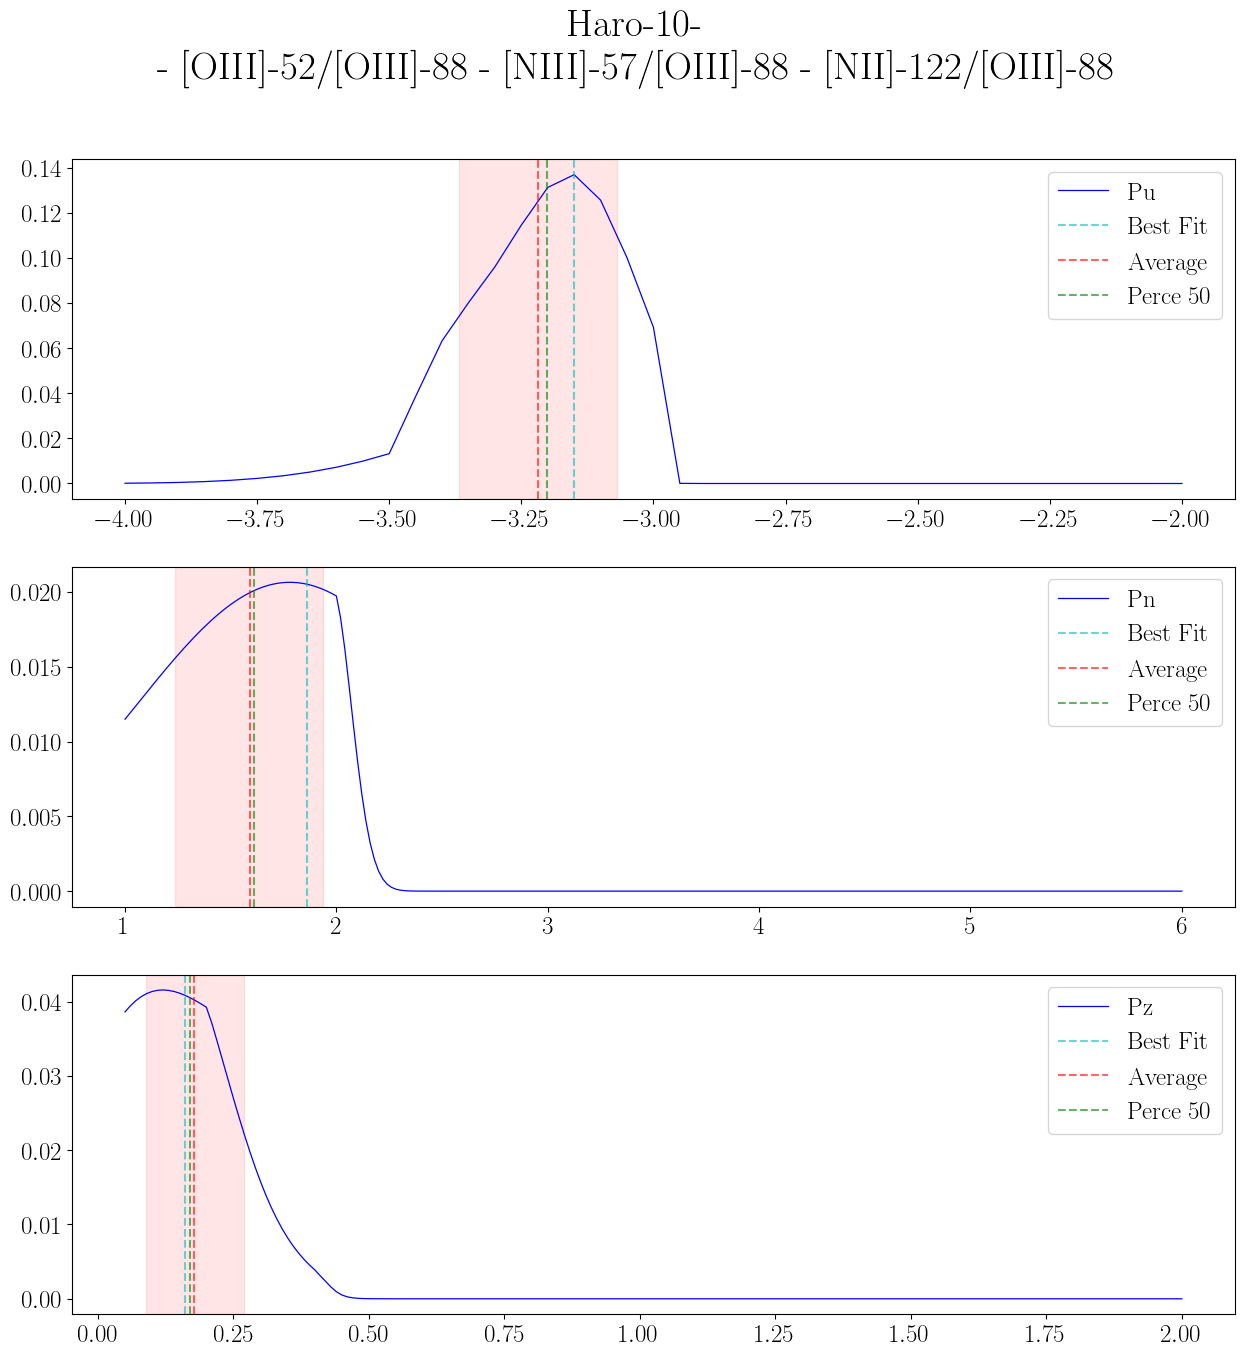

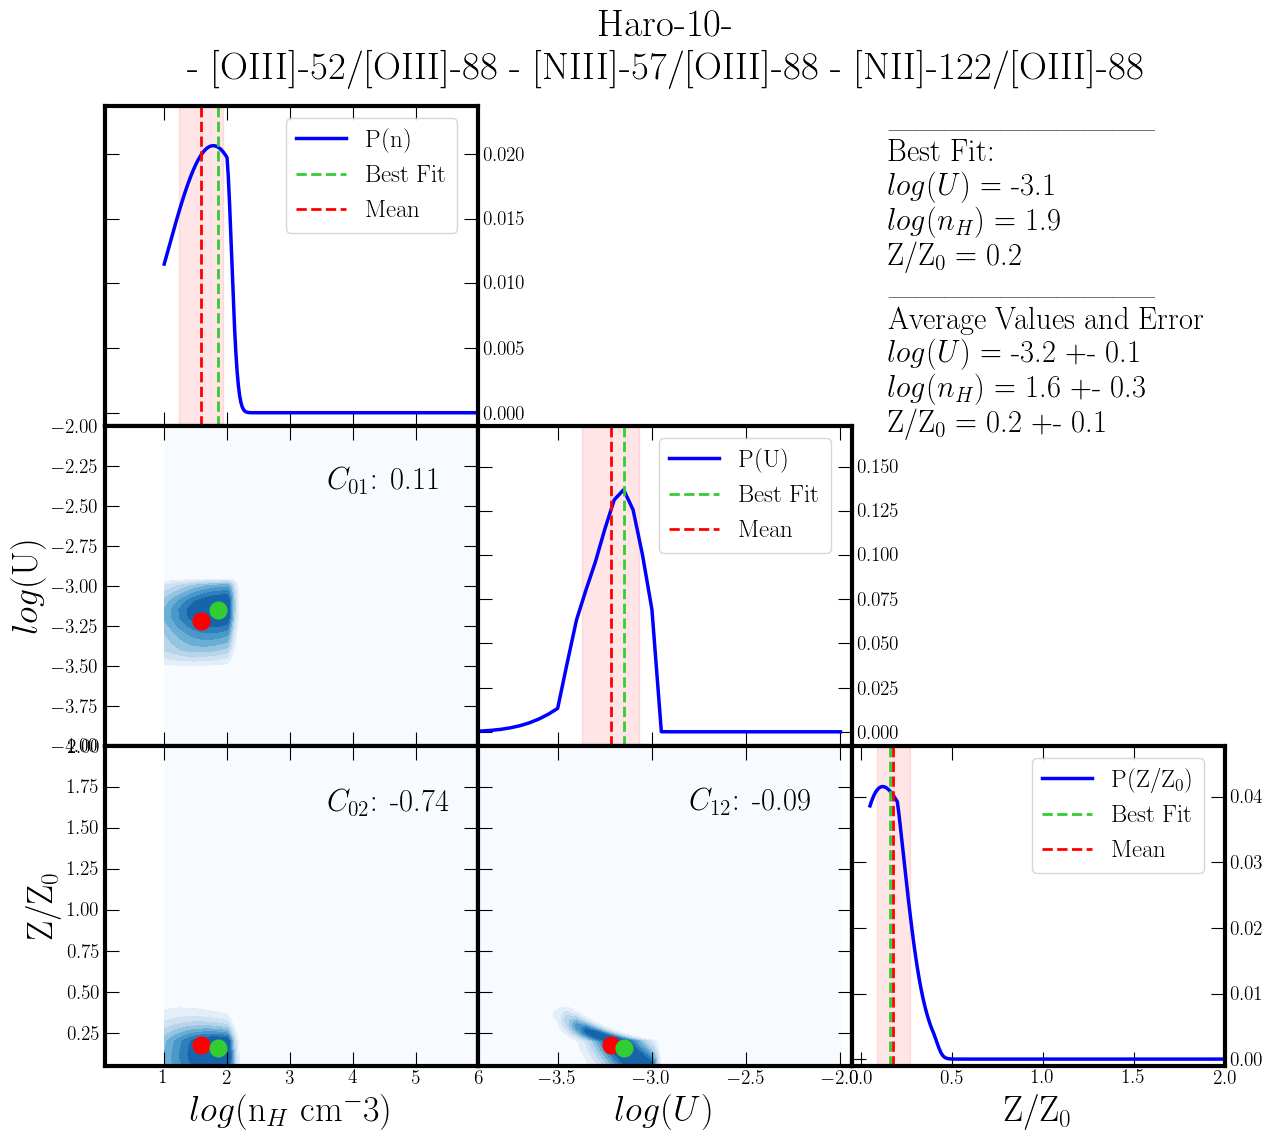




 ----------------------------running 2/9

 Results will be written in files:
/Users/admin/Scripts/GalaxyISM_0914/Plots/20240314_Haro-10-__Pplots_Fx5_Mod-01
/Users/admin/Scripts/GalaxyISM_0914/Plots/20240314_Haro-10-__Tplots_Fx5_Mod-01
UNZ_Haro-10-a_20240314.txt



 Y_obs [7.7801e-01 5.4586e-02 6.7960e-03 1.4253e+01 1.1448e+02 8.0321e+00
 1.4715e+02 1.8320e+01 5.4556e+01] 
 Y_sig [1.6560e-01 2.1568e-02 1.4424e-03 5.6369e+00 2.4379e+01 3.1740e+00
 3.1231e+01 7.2383e+00 2.3077e+01]

 Selected lines: 
 Y_obs: [7.7801e-01 5.4586e-02 6.7960e-03 1.4253e+01 1.1448e+02 8.0321e+00
 1.4715e+02 1.8320e+01 5.4556e+01] 
 Y_sig [1.6560e-01 1.0000e+06 1.0000e+06 1.0000e+06 1.0000e+06 1.0000e+06
 3.1231e+01 7.2383e+00 1.0000e+06]

Lines:   
 - [OIII]-52/[OIII]-88 - [OIII]-88/[NII]-122 - [OIII]-88/[NIII]-57 
 - OIII52/OIII88- OIII88/NII122- OIII88/NIII57
(5, 6, 5, 9)
u 5 41 10
n 6 251 50
z 5 196 48
(41, 251, 196, 9)


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:01<00:00,  4.62it/s]


Models Cube Shape:  (5, 6, 5, 9)  Interpolate to Size: [ 41 251 196] 



 z: [0.05 0.2  0.4  1.   2.  ] (5,)

 new z 
 Shape: (196,)


New Cube shape:  (41, 251, 196, 9)

 u shape: (41,) 
 n shape: (251,) 
 z shape: (196,)
Models refined shape:   (41, 251, 196, 9)
Chi shape:    (41, 251, 196, 9)
Chi^2 shape:  (41, 251, 196, 9) 	 Sum Chi^2 = 0.0E+00
Prob Shape:   (41, 251, 196) 	 Sum Prob = 1.00000E+00
Chi^2_min = 2.57E-03 
Chi^2_max = 0.00000E+00
Prob Dimensions: Pn (251,)  Pu (41,) Pz (196,)
BestSol Indexes: n-> [42] u-> [21] z-> [13] Chi_min^2 0.003
Parameters Dimensions  (251,)   (41,)   (196,)
_______________________________________________________________________

Best Fit 
 <n> = 1.84 		 <u> = -3.0500 		 <Z/Z> = 0.18
_______________________________________________________________________

Average Values, Standard Deviation
	 <u> = -3.3 +- 0.3  <n> = 1.6  +-  0.3 	 <Z/Z> = 0.3755  +-  0.2254
_______________________________________________________________________

Percentiles (Mean

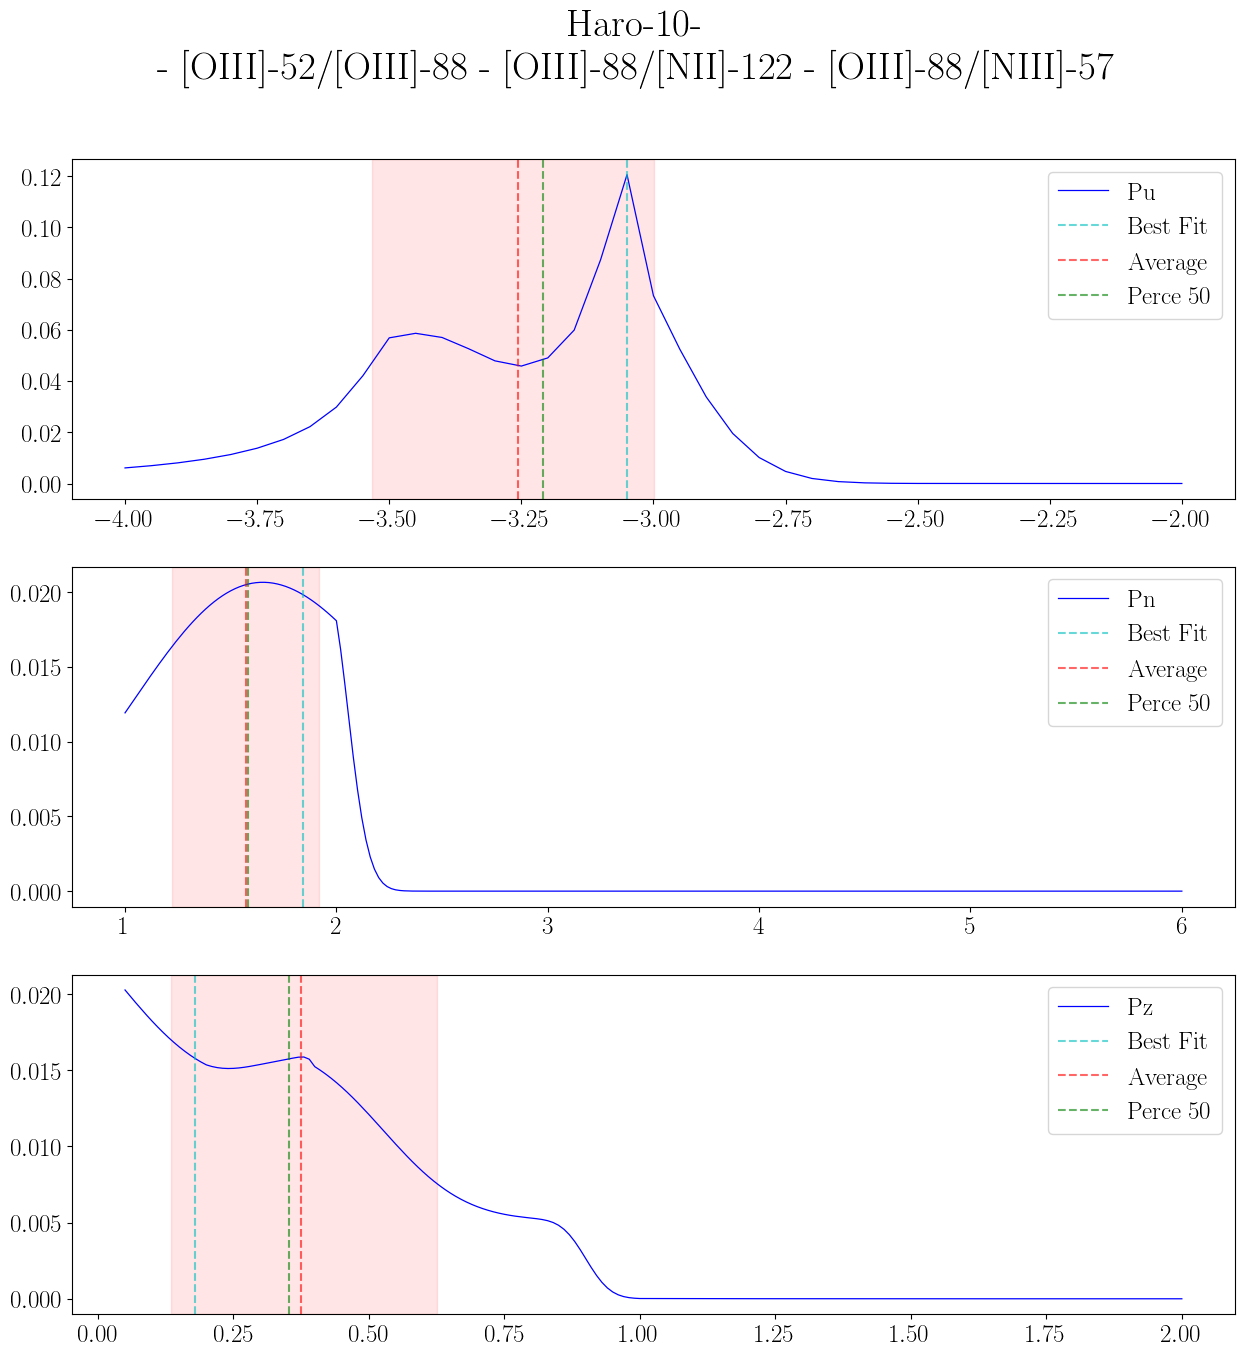

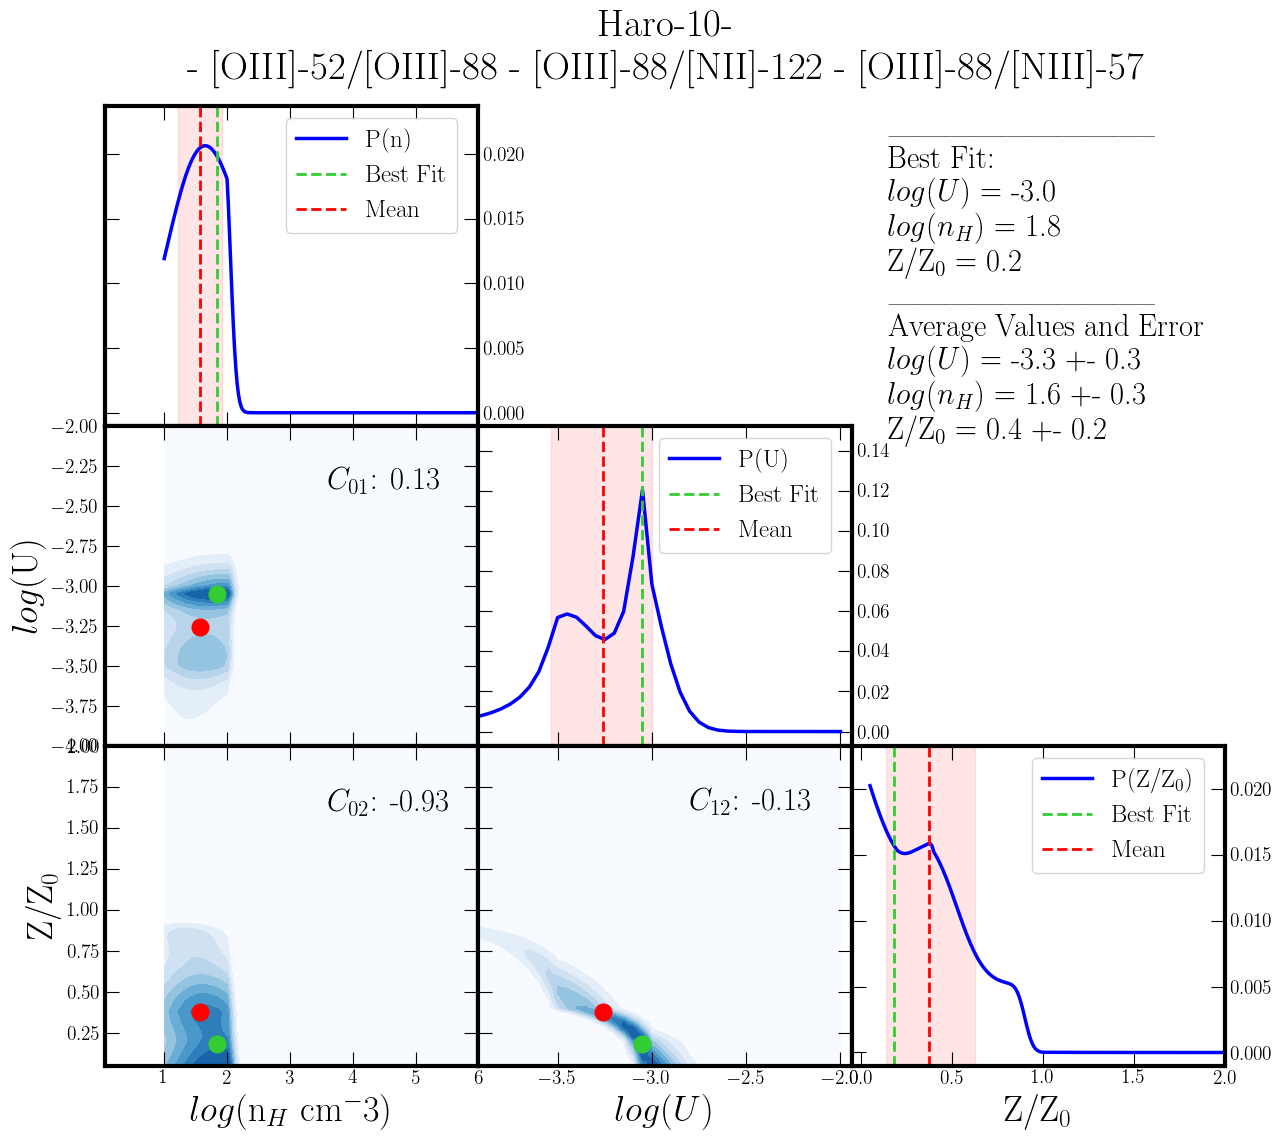




 ----------------------------running 3/9

 Results will be written in files:
/Users/admin/Scripts/GalaxyISM_0914/Plots/20240314_Haro-10-__Pplots_Fx5_Mod-02
/Users/admin/Scripts/GalaxyISM_0914/Plots/20240314_Haro-10-__Tplots_Fx5_Mod-02
UNZ_Haro-10-a_20240314.txt



 Y_obs [7.7801e-01 5.4586e-02 6.7960e-03 1.4253e+01 1.1448e+02 8.0321e+00
 1.4715e+02 1.8320e+01 5.4556e+01] 
 Y_sig [1.6560e-01 2.1568e-02 1.4424e-03 5.6369e+00 2.4379e+01 3.1740e+00
 3.1231e+01 7.2383e+00 2.3077e+01]

 Selected lines: 
 Y_obs: [7.7801e-01 5.4586e-02 6.7960e-03 1.4253e+01 1.1448e+02 8.0321e+00
 1.4715e+02 1.8320e+01 5.4556e+01] 
 Y_sig [1.6560e-01 1.0000e+06 1.0000e+06 1.0000e+06 1.0000e+06 1.0000e+06
 1.0000e+06 1.0000e+06 2.3077e+01]

Lines:   
 - [OIII]-52/[OIII]-88 - (2.2x[OIII]-88+[OIII]-52)/[NIII]-57 
 - OIII52/OIII88- (2.2OIII88+OIII52)/NIII57
(5, 6, 5, 9)
u 5 41 10
n 6 251 50
z 5 196 48
(41, 251, 196, 9)


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:00<00:00,  7.48it/s]


Models Cube Shape:  (5, 6, 5, 9)  Interpolate to Size: [ 41 251 196] 



 z: [0.05 0.2  0.4  1.   2.  ] (5,)

 new z 
 Shape: (196,)


New Cube shape:  (41, 251, 196, 9)

 u shape: (41,) 
 n shape: (251,) 
 z shape: (196,)
Models refined shape:   (41, 251, 196, 9)
Chi shape:    (41, 251, 196, 9)
Chi^2 shape:  (41, 251, 196, 9) 	 Sum Chi^2 = 0.0E+00
Prob Shape:   (41, 251, 196) 	 Sum Prob = 1.00000E+00
Chi^2_min = 1.61E-06 
Chi^2_max = 0.00000E+00
Prob Dimensions: Pn (251,)  Pu (41,) Pz (196,)
BestSol Indexes: n-> [46] u-> [20] z-> [0] Chi_min^2 0.000
Parameters Dimensions  (251,)   (41,)   (196,)
_______________________________________________________________________

Best Fit 
 <n> = 1.92 		 <u> = -3.0000 		 <Z/Z> = 0.05
_______________________________________________________________________

Average Values, Standard Deviation
	 <u> = -3.0 +- 0.6  <n> = 1.6  +-  0.3 	 <Z/Z> = 0.5239  +-  0.4693
_______________________________________________________________________

Percentiles (Mean)

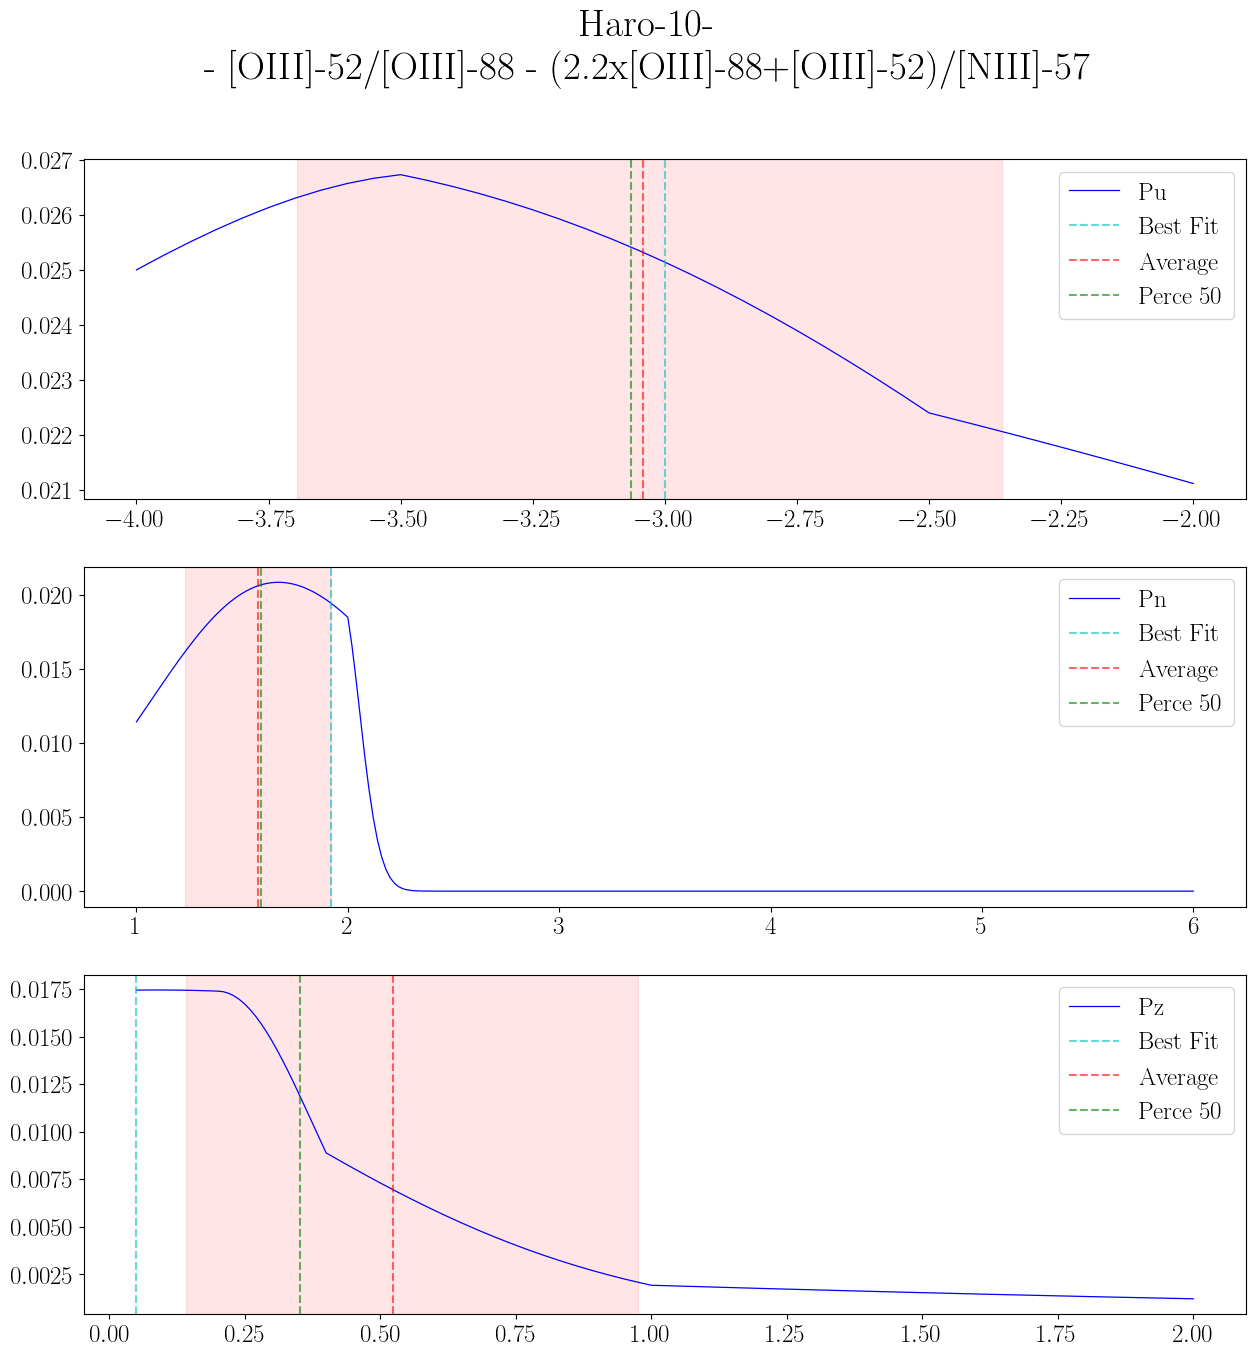

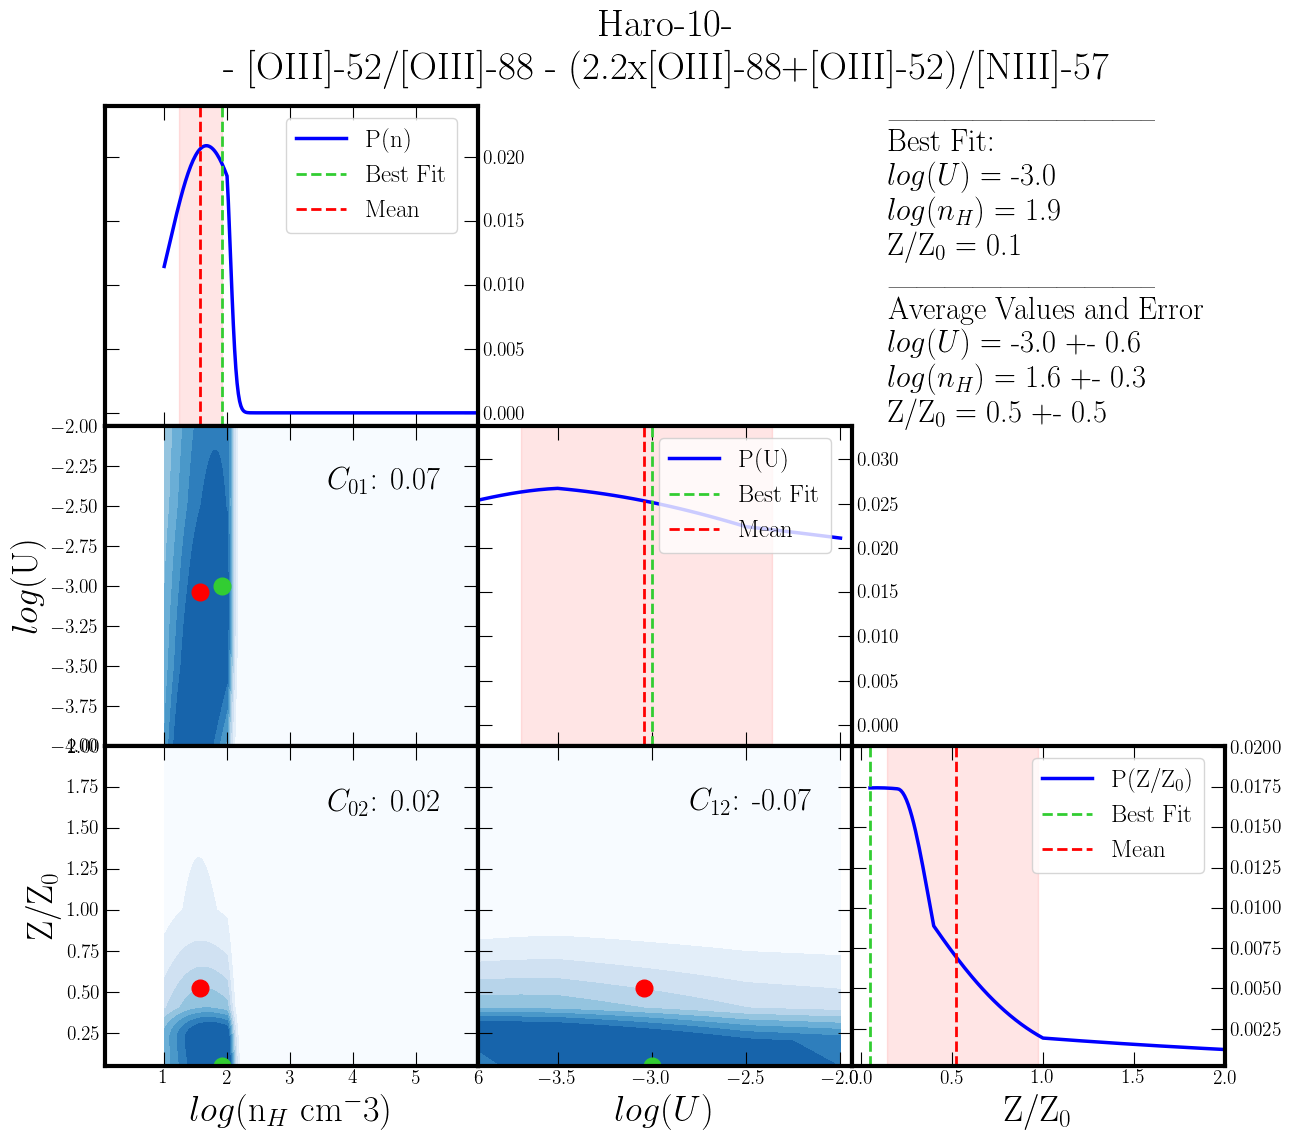




 ----------------------------running 4/9

 Results will be written in files:
/Users/admin/Scripts/GalaxyISM_0914/Plots/20240314_Haro-10-__Pplots_Fx5_Mod-03
/Users/admin/Scripts/GalaxyISM_0914/Plots/20240314_Haro-10-__Tplots_Fx5_Mod-03
UNZ_Haro-10-a_20240314.txt



 Y_obs [7.7801e-01 5.4586e-02 6.7960e-03 1.4253e+01 1.1448e+02 8.0321e+00
 1.4715e+02 1.8320e+01 5.4556e+01] 
 Y_sig [1.6560e-01 2.1568e-02 1.4424e-03 5.6369e+00 2.4379e+01 3.1740e+00
 3.1231e+01 7.2383e+00 2.3077e+01]

 Selected lines: 
 Y_obs: [7.7801e-01 5.4586e-02 6.7960e-03 1.4253e+01 1.1448e+02 8.0321e+00
 1.4715e+02 1.8320e+01 5.4556e+01] 
 Y_sig [1.6560e-01 2.1568e-02 1.0000e+06 1.0000e+06 1.0000e+06 1.0000e+06
 1.0000e+06 1.0000e+06 1.0000e+06]

Lines:   
 - [OIII]-52/[OIII]-88 - [NIII]-57/[OIII]-88 
 - OIII52/OIII88- NIII57/OIII88
(5, 6, 5, 9)
u 5 41 10
n 6 251 50
z 5 196 48
(41, 251, 196, 9)


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:00<00:00,  5.16it/s]


Models Cube Shape:  (5, 6, 5, 9)  Interpolate to Size: [ 41 251 196] 



 z: [0.05 0.2  0.4  1.   2.  ] (5,)

 new z 
 Shape: (196,)


New Cube shape:  (41, 251, 196, 9)

 u shape: (41,) 
 n shape: (251,) 
 z shape: (196,)
Models refined shape:   (41, 251, 196, 9)
Chi shape:    (41, 251, 196, 9)
Chi^2 shape:  (41, 251, 196, 9) 	 Sum Chi^2 = 0.0E+00
Prob Shape:   (41, 251, 196) 	 Sum Prob = 1.00000E+00
Chi^2_min = 1.27E-06 
Chi^2_max = 0.00000E+00
Prob Dimensions: Pn (251,)  Pu (41,) Pz (196,)
BestSol Indexes: n-> [46] u-> [20] z-> [0] Chi_min^2 0.000
Parameters Dimensions  (251,)   (41,)   (196,)
_______________________________________________________________________

Best Fit 
 <n> = 1.92 		 <u> = -3.0000 		 <Z/Z> = 0.05
_______________________________________________________________________

Average Values, Standard Deviation
	 <u> = -3.1 +- 0.6  <n> = 1.6  +-  0.3 	 <Z/Z> = 0.1797  +-  0.0853
_______________________________________________________________________

Percentiles (Mean)

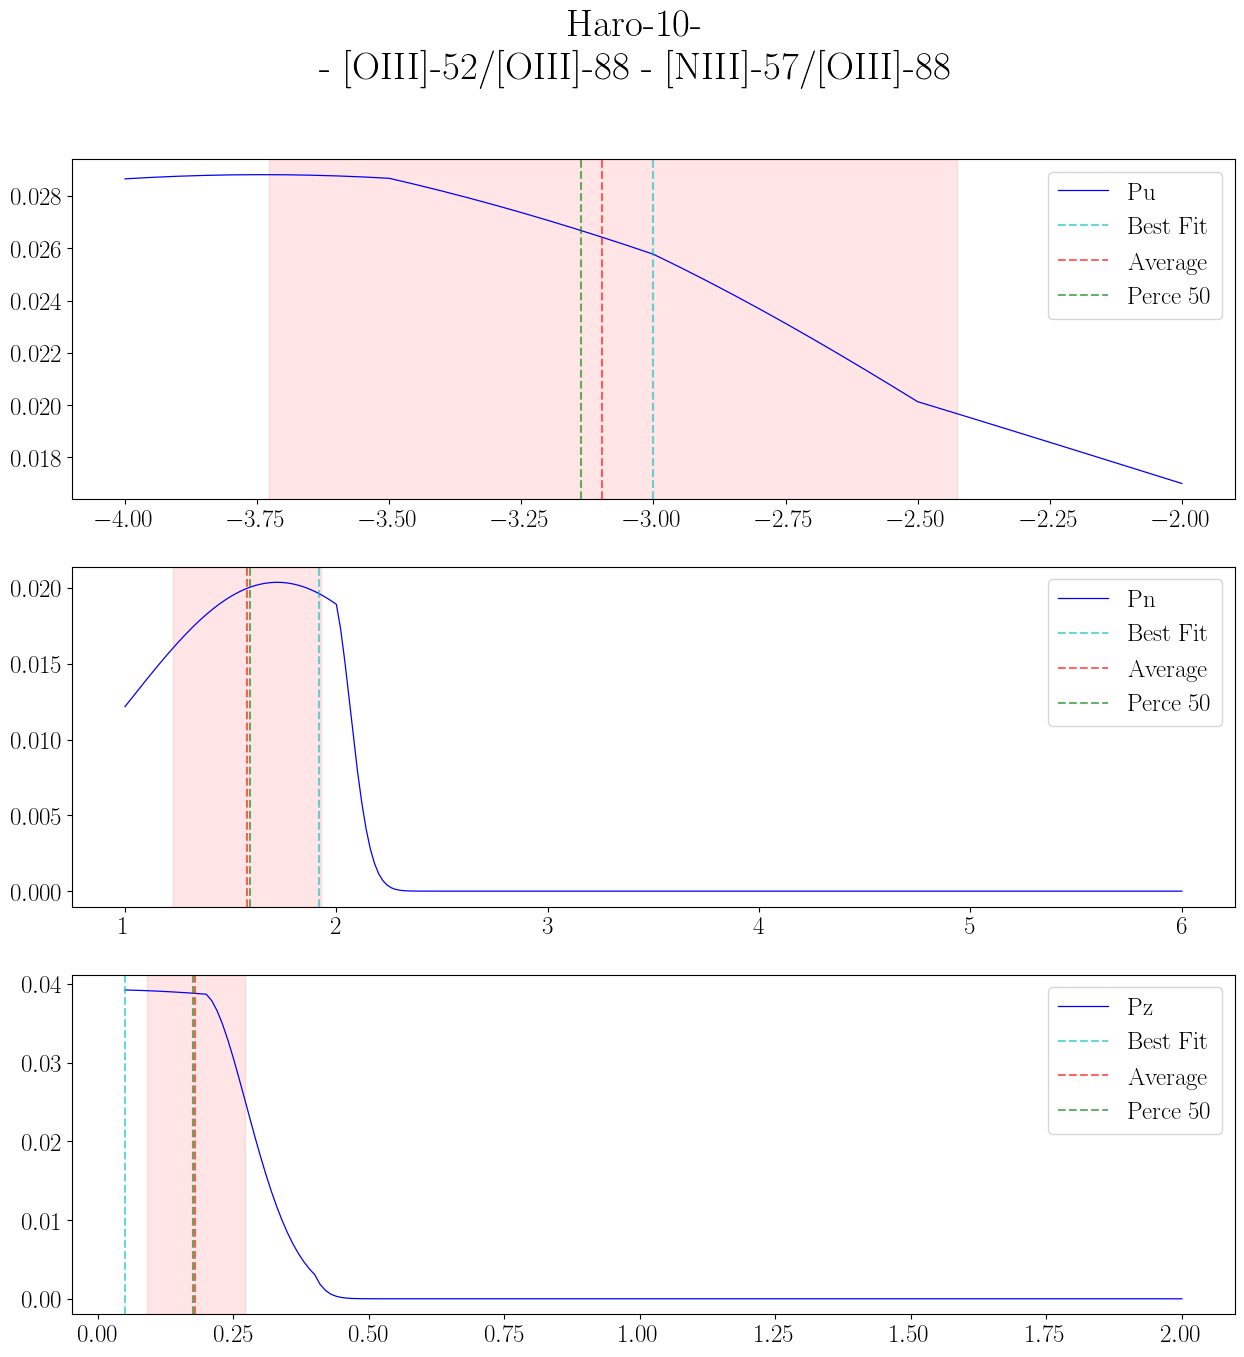

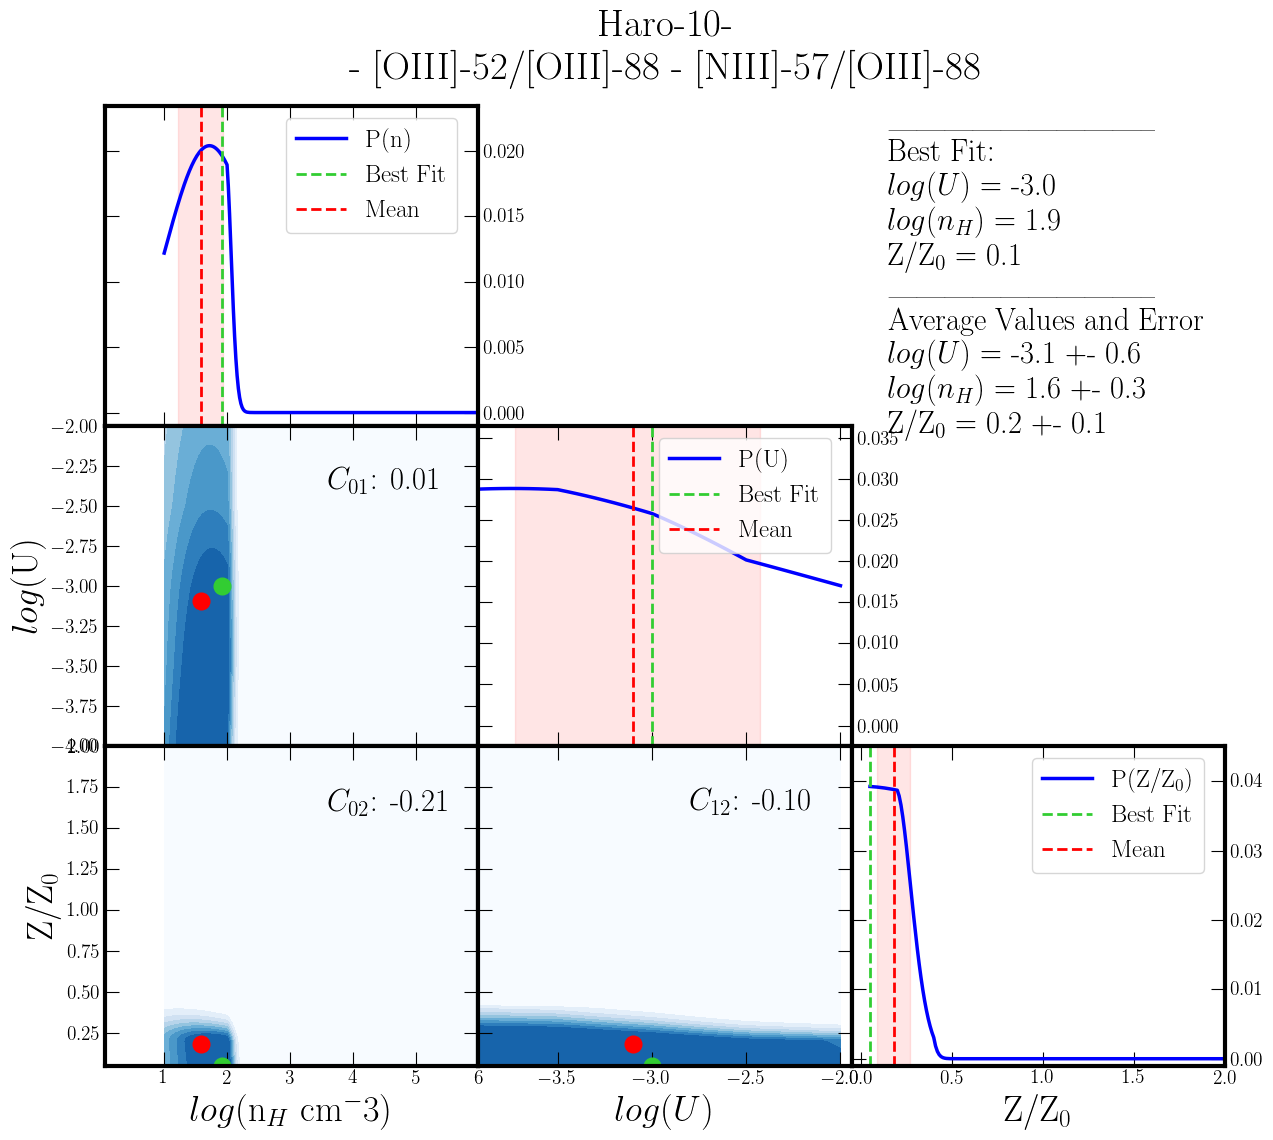




 ----------------------------running 5/9

 Results will be written in files:
/Users/admin/Scripts/GalaxyISM_0914/Plots/20240314_Haro-10-__Pplots_Fx5_Mod-04
/Users/admin/Scripts/GalaxyISM_0914/Plots/20240314_Haro-10-__Tplots_Fx5_Mod-04
UNZ_Haro-10-a_20240314.txt



 Y_obs [7.7801e-01 5.4586e-02 6.7960e-03 1.4253e+01 1.1448e+02 8.0321e+00
 1.4715e+02 1.8320e+01 5.4556e+01] 
 Y_sig [1.6560e-01 2.1568e-02 1.4424e-03 5.6369e+00 2.4379e+01 3.1740e+00
 3.1231e+01 7.2383e+00 2.3077e+01]

 Selected lines: 
 Y_obs: [7.7801e-01 5.4586e-02 6.7960e-03 1.4253e+01 1.1448e+02 8.0321e+00
 1.4715e+02 1.8320e+01 5.4556e+01] 
 Y_sig [1.6560e-01 1.0000e+06 1.4424e-03 1.0000e+06 1.0000e+06 1.0000e+06
 1.0000e+06 1.0000e+06 1.0000e+06]

Lines:   
 - [OIII]-52/[OIII]-88 - [NII]-122/[OIII]-88 
 - OIII52/OIII88- NII122/OIII88
(5, 6, 5, 9)
u 5 41 10
n 6 251 50
z 5 196 48
(41, 251, 196, 9)


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:00<00:00,  5.52it/s]


Models Cube Shape:  (5, 6, 5, 9)  Interpolate to Size: [ 41 251 196] 



 z: [0.05 0.2  0.4  1.   2.  ] (5,)

 new z 
 Shape: (196,)


New Cube shape:  (41, 251, 196, 9)

 u shape: (41,) 
 n shape: (251,) 
 z shape: (196,)
Models refined shape:   (41, 251, 196, 9)
Chi shape:    (41, 251, 196, 9)
Chi^2 shape:  (41, 251, 196, 9) 	 Sum Chi^2 = 0.0E+00
Prob Shape:   (41, 251, 196) 	 Sum Prob = 1.00000E+00
Chi^2_min = 1.01E-04 
Chi^2_max = 0.00000E+00
Prob Dimensions: Pn (251,)  Pu (41,) Pz (196,)
BestSol Indexes: n-> [42] u-> [23] z-> [11] Chi_min^2 0.000
Parameters Dimensions  (251,)   (41,)   (196,)
_______________________________________________________________________

Best Fit 
 <n> = 1.84 		 <u> = -3.1500 		 <Z/Z> = 0.16
_______________________________________________________________________

Average Values, Standard Deviation
	 <u> = -3.4 +- 0.3  <n> = 1.6  +-  0.3 	 <Z/Z> = 0.3053  +-  0.1652
_______________________________________________________________________

Percentiles (Mean

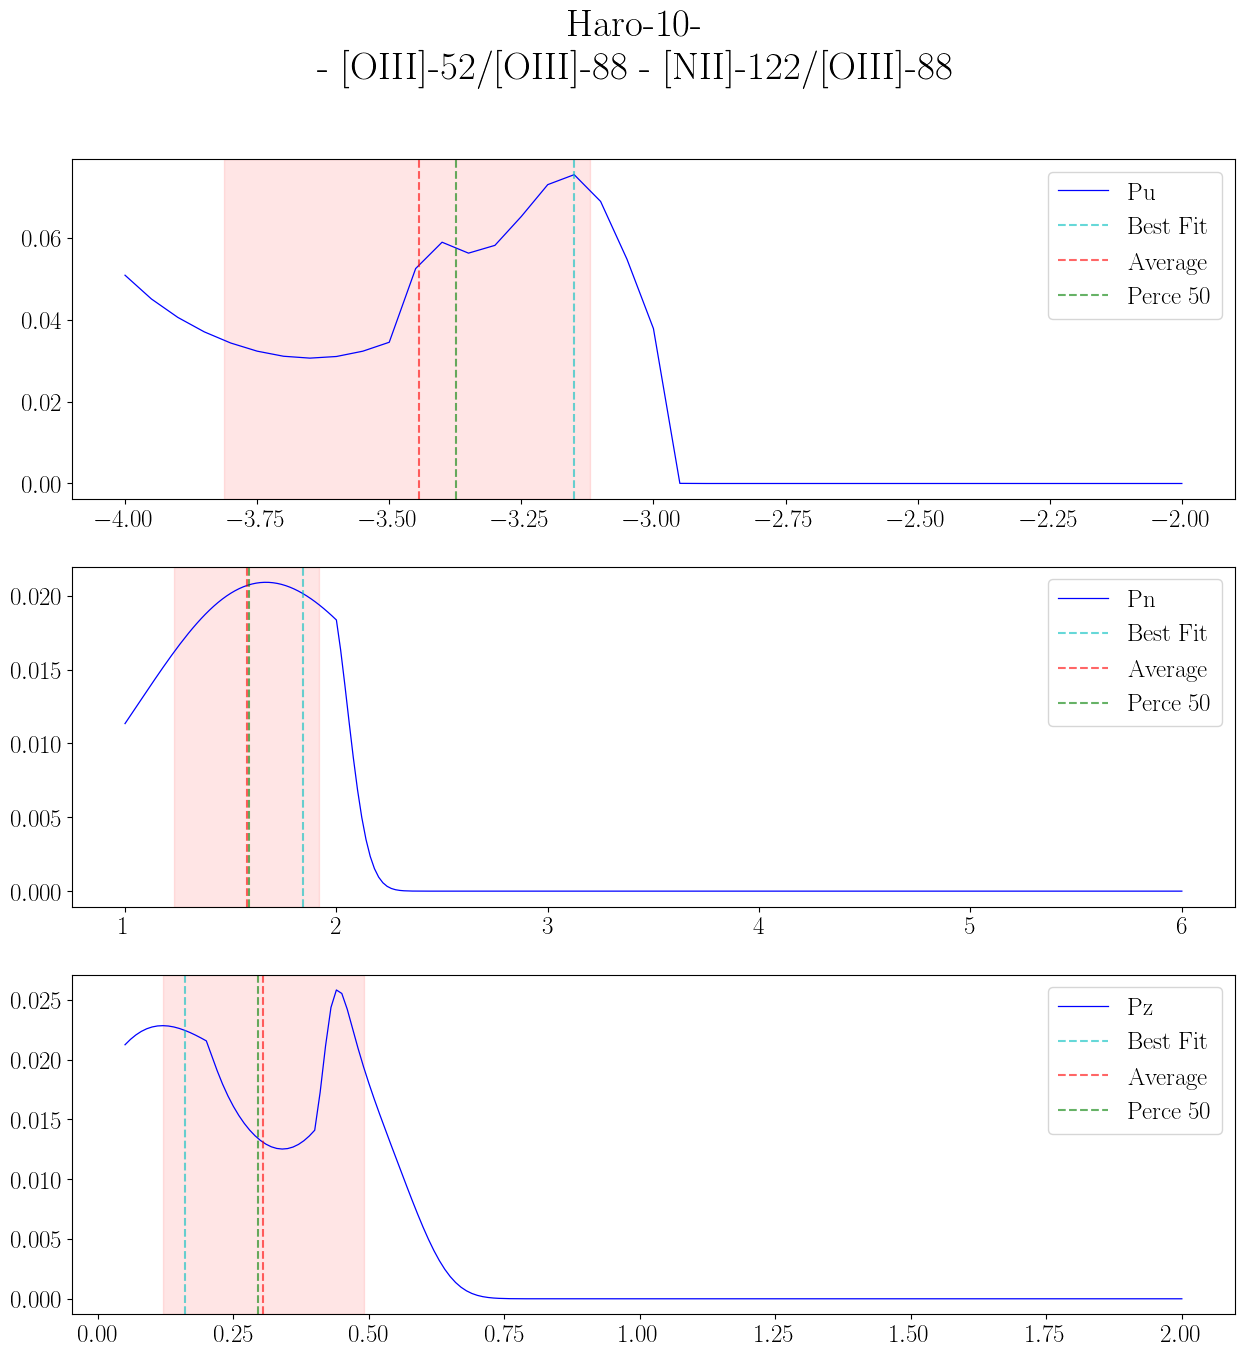

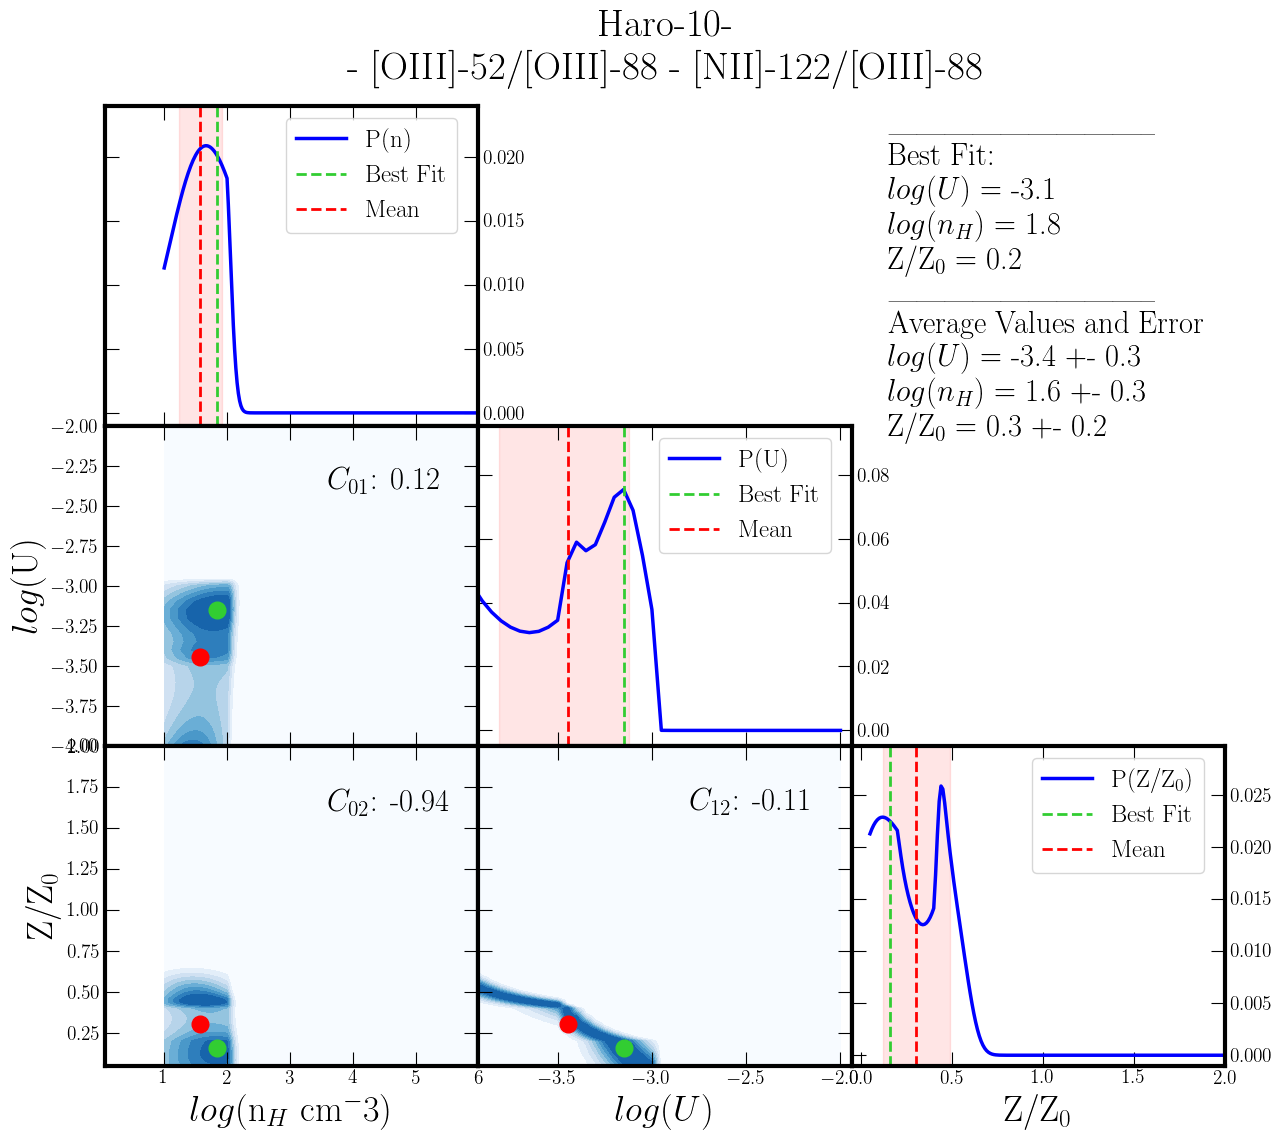




 ----------------------------running 6/9

 Results will be written in files:
/Users/admin/Scripts/GalaxyISM_0914/Plots/20240314_Haro-10-__Pplots_Fx5_Mod-05
/Users/admin/Scripts/GalaxyISM_0914/Plots/20240314_Haro-10-__Tplots_Fx5_Mod-05
UNZ_Haro-10-a_20240314.txt



 Y_obs [7.7801e-01 5.4586e-02 6.7960e-03 1.4253e+01 1.1448e+02 8.0321e+00
 1.4715e+02 1.8320e+01 5.4556e+01] 
 Y_sig [1.6560e-01 2.1568e-02 1.4424e-03 5.6369e+00 2.4379e+01 3.1740e+00
 3.1231e+01 7.2383e+00 2.3077e+01]

 Selected lines: 
 Y_obs: [7.7801e-01 5.4586e-02 6.7960e-03 1.4253e+01 1.1448e+02 8.0321e+00
 1.4715e+02 1.8320e+01 5.4556e+01] 
 Y_sig [1.6560e-01 1.0000e+06 1.0000e+06 1.0000e+06 1.0000e+06 1.0000e+06
 3.1231e+01 1.0000e+06 1.0000e+06]

Lines:   
 - [OIII]-52/[OIII]-88 - [OIII]-88/[NII]-122 
 - OIII52/OIII88- OIII88/NII122
(5, 6, 5, 9)
u 5 41 10
n 6 251 50
z 5 196 48
(41, 251, 196, 9)


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:00<00:00,  7.11it/s]


Models Cube Shape:  (5, 6, 5, 9)  Interpolate to Size: [ 41 251 196] 



 z: [0.05 0.2  0.4  1.   2.  ] (5,)

 new z 
 Shape: (196,)


New Cube shape:  (41, 251, 196, 9)

 u shape: (41,) 
 n shape: (251,) 
 z shape: (196,)
Models refined shape:   (41, 251, 196, 9)
Chi shape:    (41, 251, 196, 9)
Chi^2 shape:  (41, 251, 196, 9) 	 Sum Chi^2 = 0.0E+00
Prob Shape:   (41, 251, 196) 	 Sum Prob = 1.00000E+00
Chi^2_min = 4.79E-06 
Chi^2_max = 0.00000E+00
Prob Dimensions: Pn (251,)  Pu (41,) Pz (196,)
BestSol Indexes: n-> [21] u-> [37] z-> [80] Chi_min^2 0.000
Parameters Dimensions  (251,)   (41,)   (196,)
_______________________________________________________________________

Best Fit 
 <n> = 1.42 		 <u> = -3.8500 		 <Z/Z> = 0.85
_______________________________________________________________________

Average Values, Standard Deviation
	 <u> = -3.4 +- 0.3  <n> = 1.6  +-  0.3 	 <Z/Z> = 0.5195  +-  0.2464
_______________________________________________________________________

Percentiles (Mean

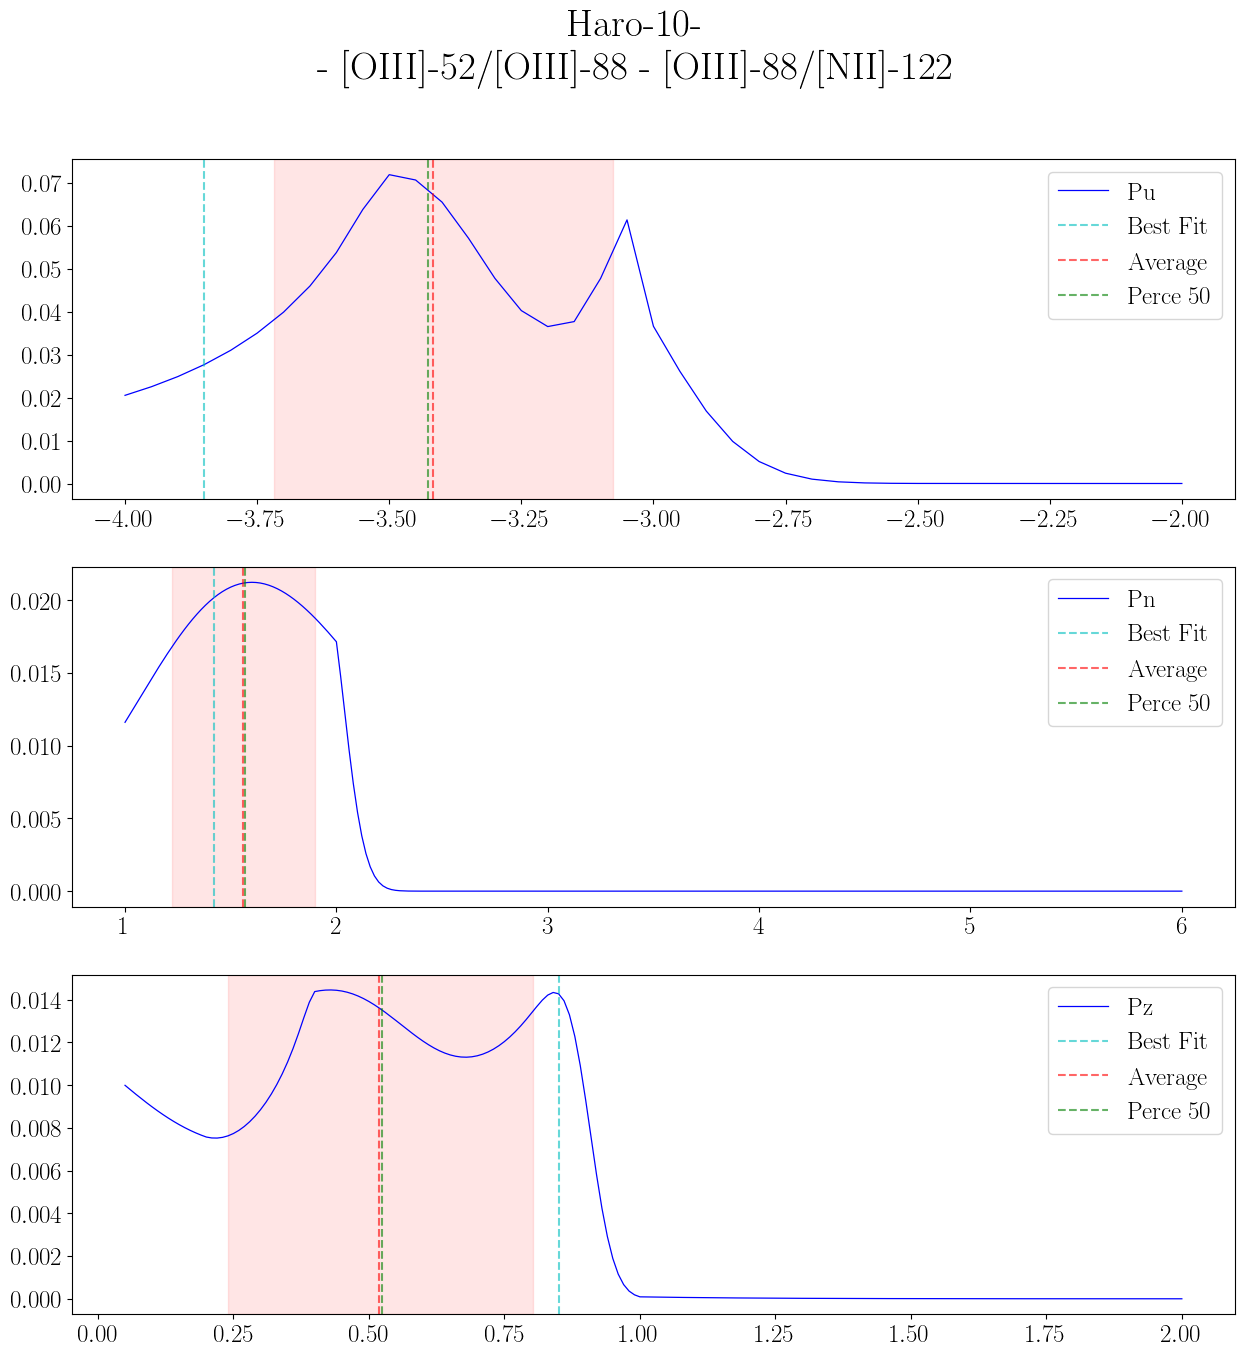

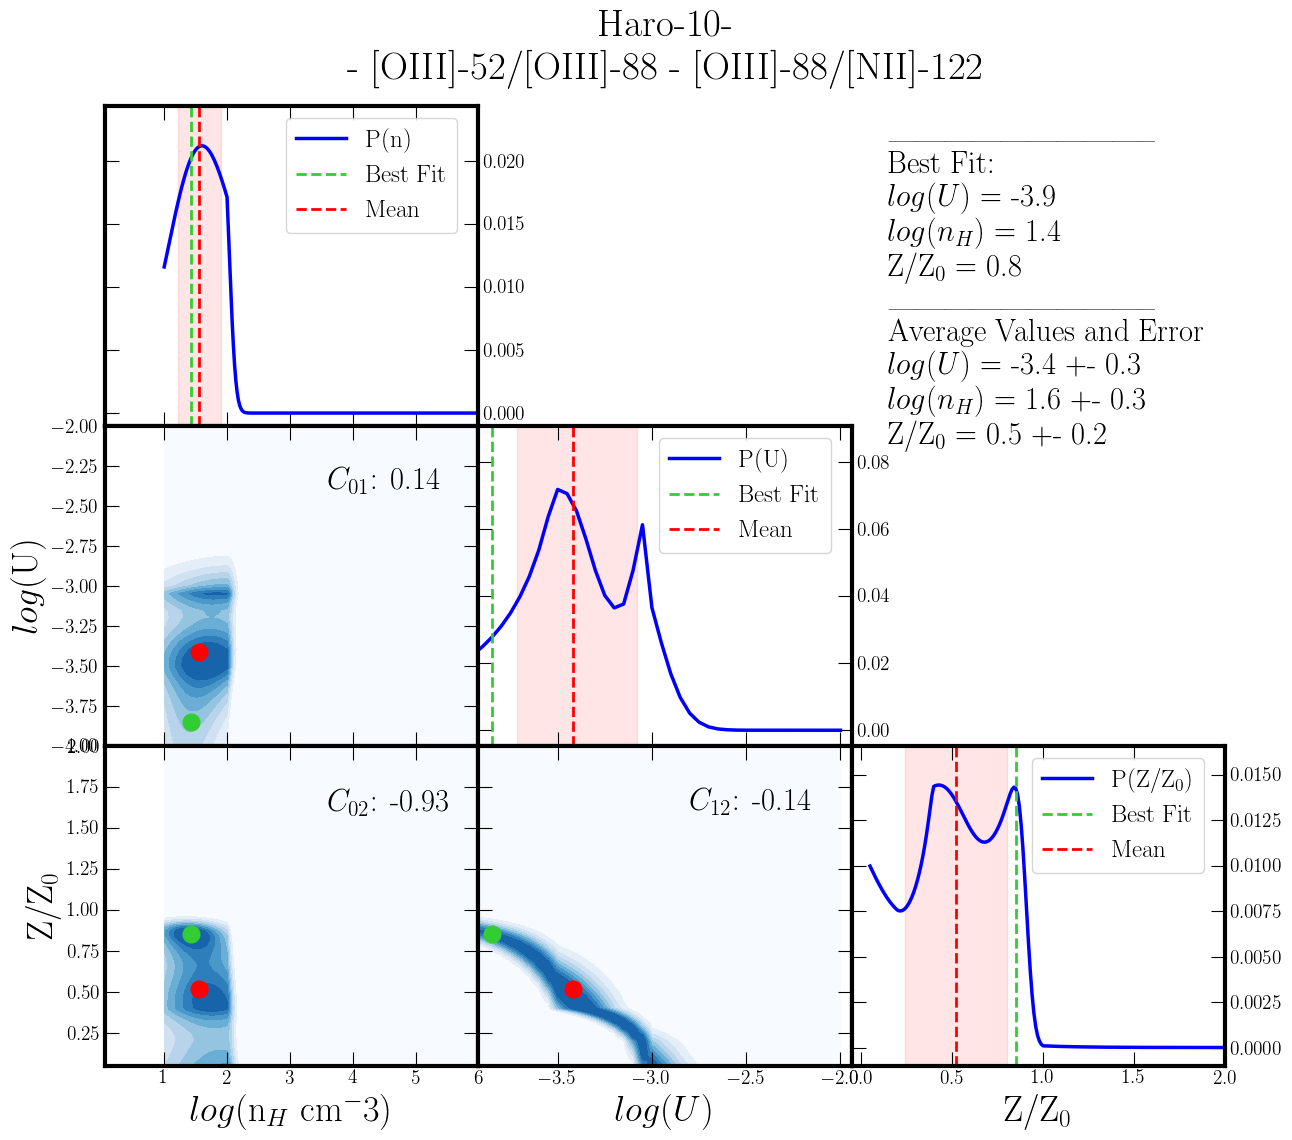




 ----------------------------running 7/9

 Results will be written in files:
/Users/admin/Scripts/GalaxyISM_0914/Plots/20240314_Haro-10-__Pplots_Fx5_Mod-06
/Users/admin/Scripts/GalaxyISM_0914/Plots/20240314_Haro-10-__Tplots_Fx5_Mod-06
UNZ_Haro-10-a_20240314.txt



 Y_obs [7.7801e-01 5.4586e-02 6.7960e-03 1.4253e+01 1.1448e+02 8.0321e+00
 1.4715e+02 1.8320e+01 5.4556e+01] 
 Y_sig [1.6560e-01 2.1568e-02 1.4424e-03 5.6369e+00 2.4379e+01 3.1740e+00
 3.1231e+01 7.2383e+00 2.3077e+01]

 Selected lines: 
 Y_obs: [7.7801e-01 5.4586e-02 6.7960e-03 1.4253e+01 1.1448e+02 8.0321e+00
 1.4715e+02 1.8320e+01 5.4556e+01] 
 Y_sig [1.0000e+06 2.1568e-02 1.4424e-03 1.0000e+06 1.0000e+06 1.0000e+06
 1.0000e+06 1.0000e+06 1.0000e+06]

Lines:   
 - [NIII]-57/[OIII]-88 - [NII]-122/[OIII]-88 
 - NIII57/OIII88- NII122/OIII88
(5, 6, 5, 9)
u 5 41 10
n 6 251 50
z 5 196 48
(41, 251, 196, 9)


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:00<00:00,  5.20it/s]


Models Cube Shape:  (5, 6, 5, 9)  Interpolate to Size: [ 41 251 196] 



 z: [0.05 0.2  0.4  1.   2.  ] (5,)

 new z 
 Shape: (196,)


New Cube shape:  (41, 251, 196, 9)

 u shape: (41,) 
 n shape: (251,) 
 z shape: (196,)
Models refined shape:   (41, 251, 196, 9)
Chi shape:    (41, 251, 196, 9)
Chi^2 shape:  (41, 251, 196, 9) 	 Sum Chi^2 = 0.0E+00
Prob Shape:   (41, 251, 196) 	 Sum Prob = 1.00000E+00
Chi^2_min = 1.62E-04 
Chi^2_max = 0.00000E+00
Prob Dimensions: Pn (251,)  Pu (41,) Pz (196,)
BestSol Indexes: n-> [14] u-> [25] z-> [17] Chi_min^2 0.000
Parameters Dimensions  (251,)   (41,)   (196,)
_______________________________________________________________________

Best Fit 
 <n> = 1.28 		 <u> = -3.2500 		 <Z/Z> = 0.22
_______________________________________________________________________

Average Values, Standard Deviation
	 <u> = -3.2 +- 0.1  <n> = 1.9  +-  0.6 	 <Z/Z> = 0.1689  +-  0.0811
_______________________________________________________________________

Percentiles (Mean

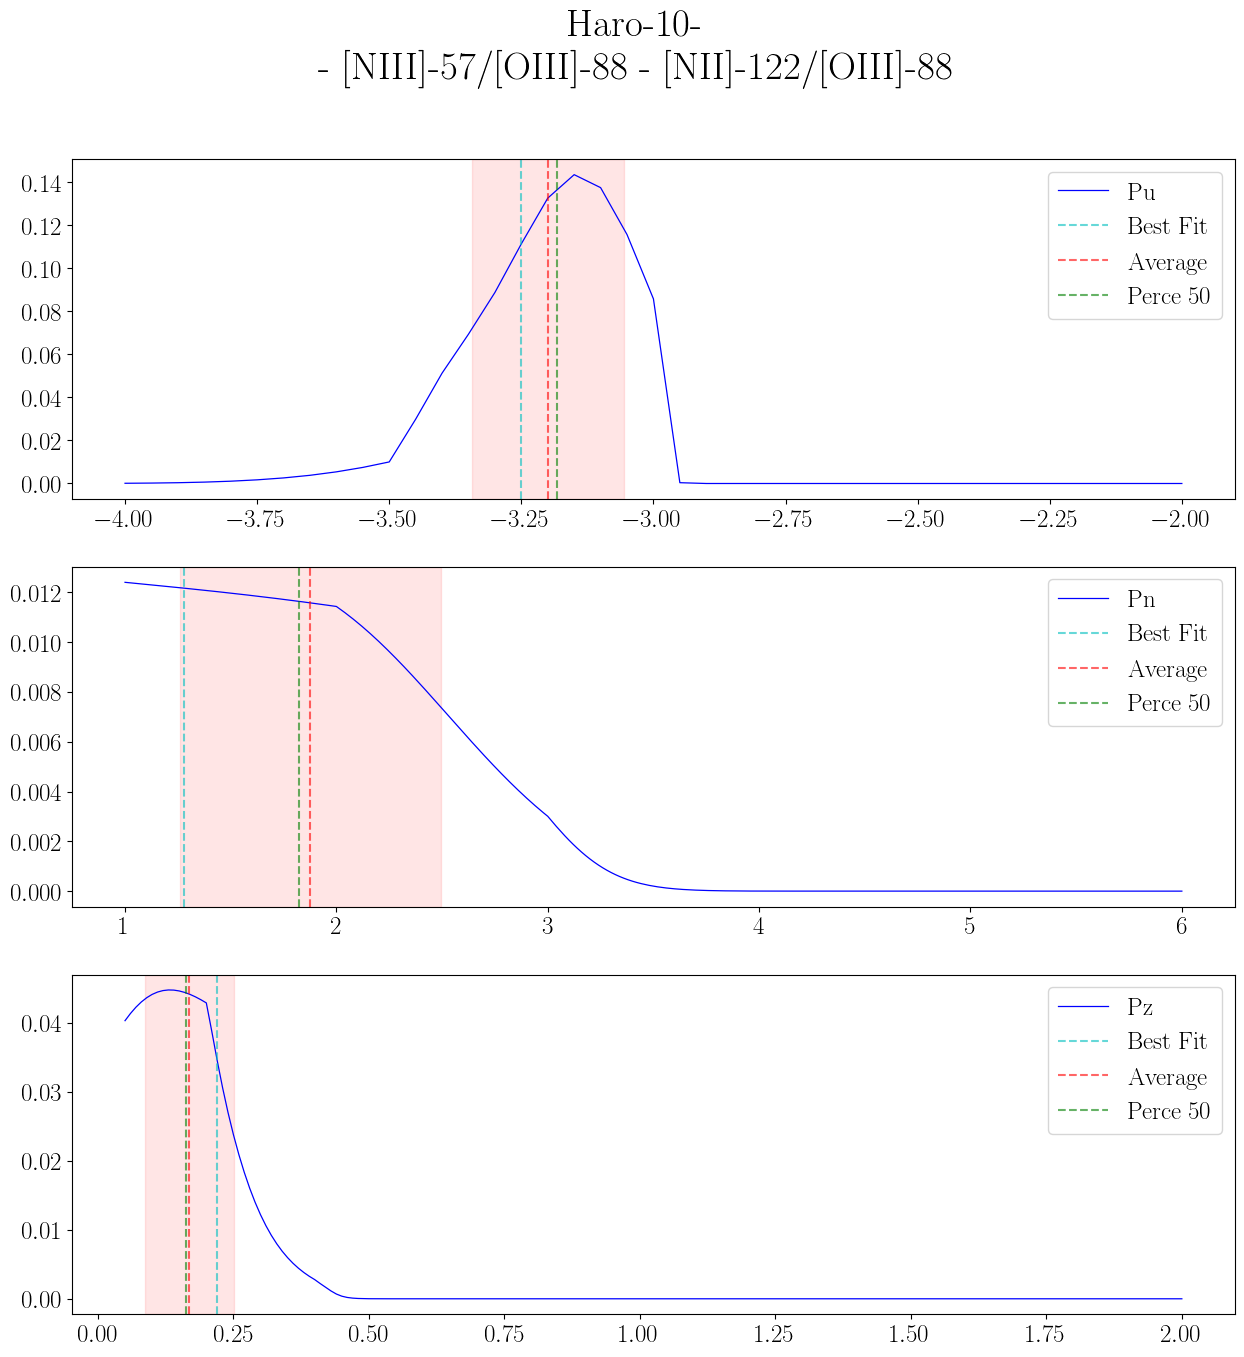

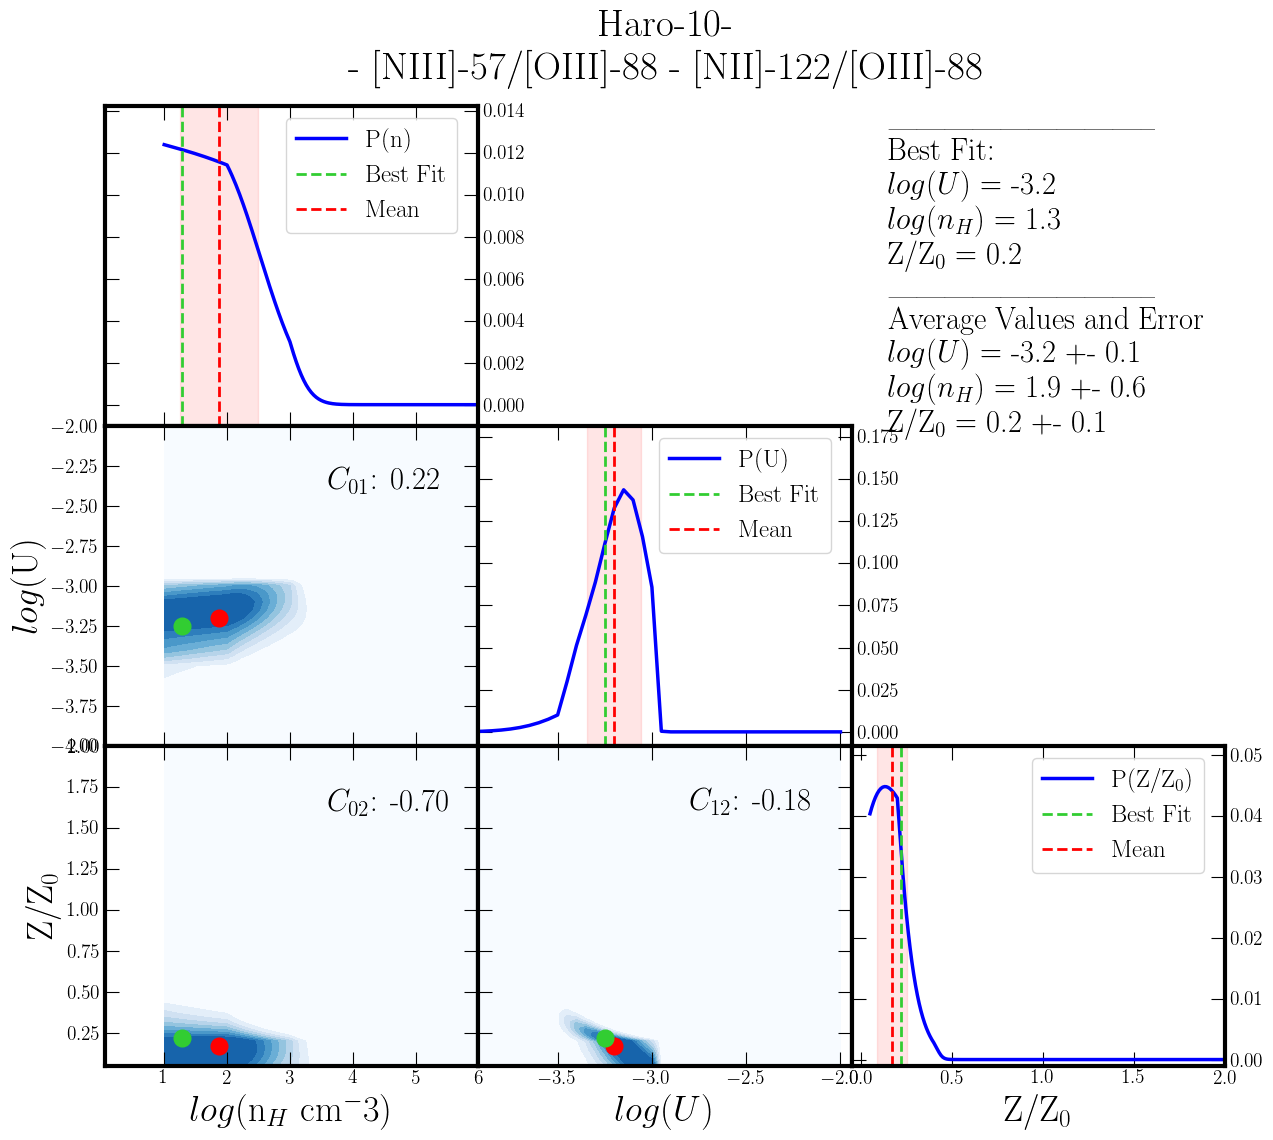




 ----------------------------running 8/9

 Results will be written in files:
/Users/admin/Scripts/GalaxyISM_0914/Plots/20240314_Haro-10-__Pplots_Fx5_Mod-07
/Users/admin/Scripts/GalaxyISM_0914/Plots/20240314_Haro-10-__Tplots_Fx5_Mod-07
UNZ_Haro-10-a_20240314.txt



 Y_obs [7.7801e-01 5.4586e-02 6.7960e-03 1.4253e+01 1.1448e+02 8.0321e+00
 1.4715e+02 1.8320e+01 5.4556e+01] 
 Y_sig [1.6560e-01 2.1568e-02 1.4424e-03 5.6369e+00 2.4379e+01 3.1740e+00
 3.1231e+01 7.2383e+00 2.3077e+01]

 Selected lines: 
 Y_obs: [7.7801e-01 5.4586e-02 6.7960e-03 1.4253e+01 1.1448e+02 8.0321e+00
 1.4715e+02 1.8320e+01 5.4556e+01] 
 Y_sig [1.0000e+06 1.0000e+06 1.0000e+06 1.0000e+06 1.0000e+06 1.0000e+06
 3.1231e+01 7.2383e+00 1.0000e+06]

Lines:   
 - [OIII]-88/[NII]-122 - [OIII]-88/[NIII]-57 
 - OIII88/NII122- OIII88/NIII57
(5, 6, 5, 9)
u 5 41 10
n 6 251 50
z 5 196 48
(41, 251, 196, 9)


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:00<00:00,  7.71it/s]


Models Cube Shape:  (5, 6, 5, 9)  Interpolate to Size: [ 41 251 196] 



 z: [0.05 0.2  0.4  1.   2.  ] (5,)

 new z 
 Shape: (196,)


New Cube shape:  (41, 251, 196, 9)

 u shape: (41,) 
 n shape: (251,) 
 z shape: (196,)
Models refined shape:   (41, 251, 196, 9)
Chi shape:    (41, 251, 196, 9)
Chi^2 shape:  (41, 251, 196, 9) 	 Sum Chi^2 = 0.0E+00
Prob Shape:   (41, 251, 196) 	 Sum Prob = 1.00000E+00
Chi^2_min = 1.15E-04 
Chi^2_max = 0.00000E+00
Prob Dimensions: Pn (251,)  Pu (41,) Pz (196,)
BestSol Indexes: n-> [35] u-> [21] z-> [13] Chi_min^2 0.000
Parameters Dimensions  (251,)   (41,)   (196,)
_______________________________________________________________________

Best Fit 
 <n> = 1.70 		 <u> = -3.0500 		 <Z/Z> = 0.18
_______________________________________________________________________

Average Values, Standard Deviation
	 <u> = -3.3 +- 0.3  <n> = 2.6  +-  1.3 	 <Z/Z> = 0.3557  +-  0.2296
_______________________________________________________________________

Percentiles (Mean

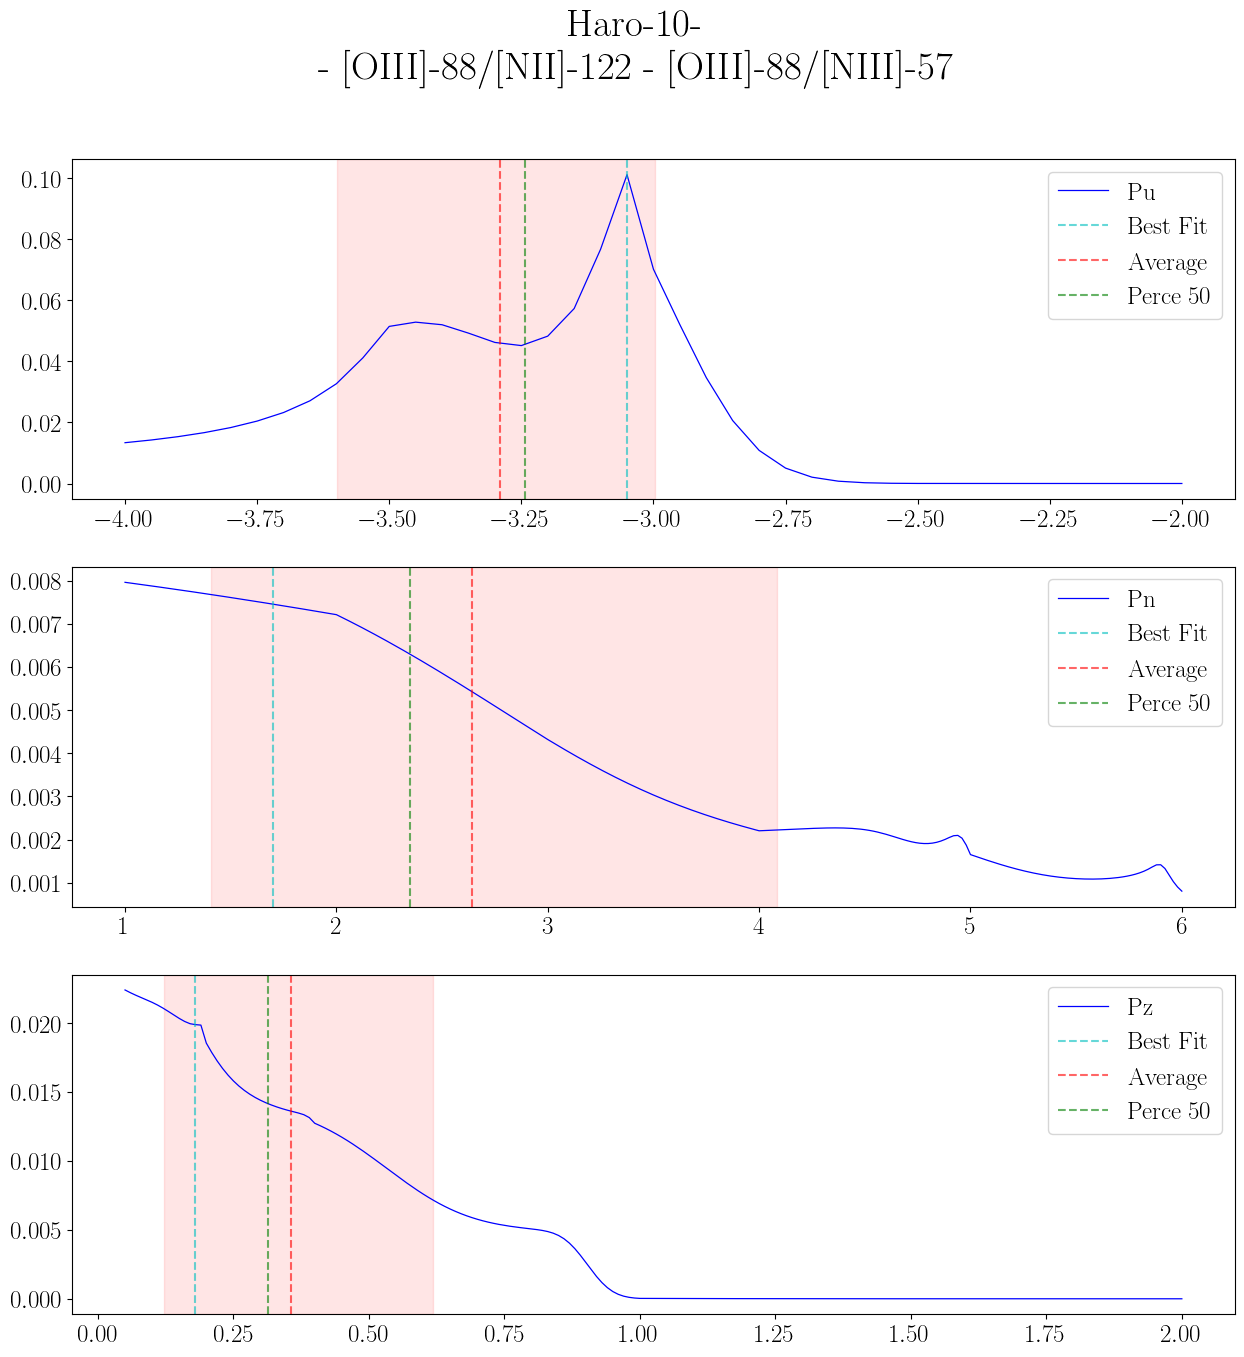

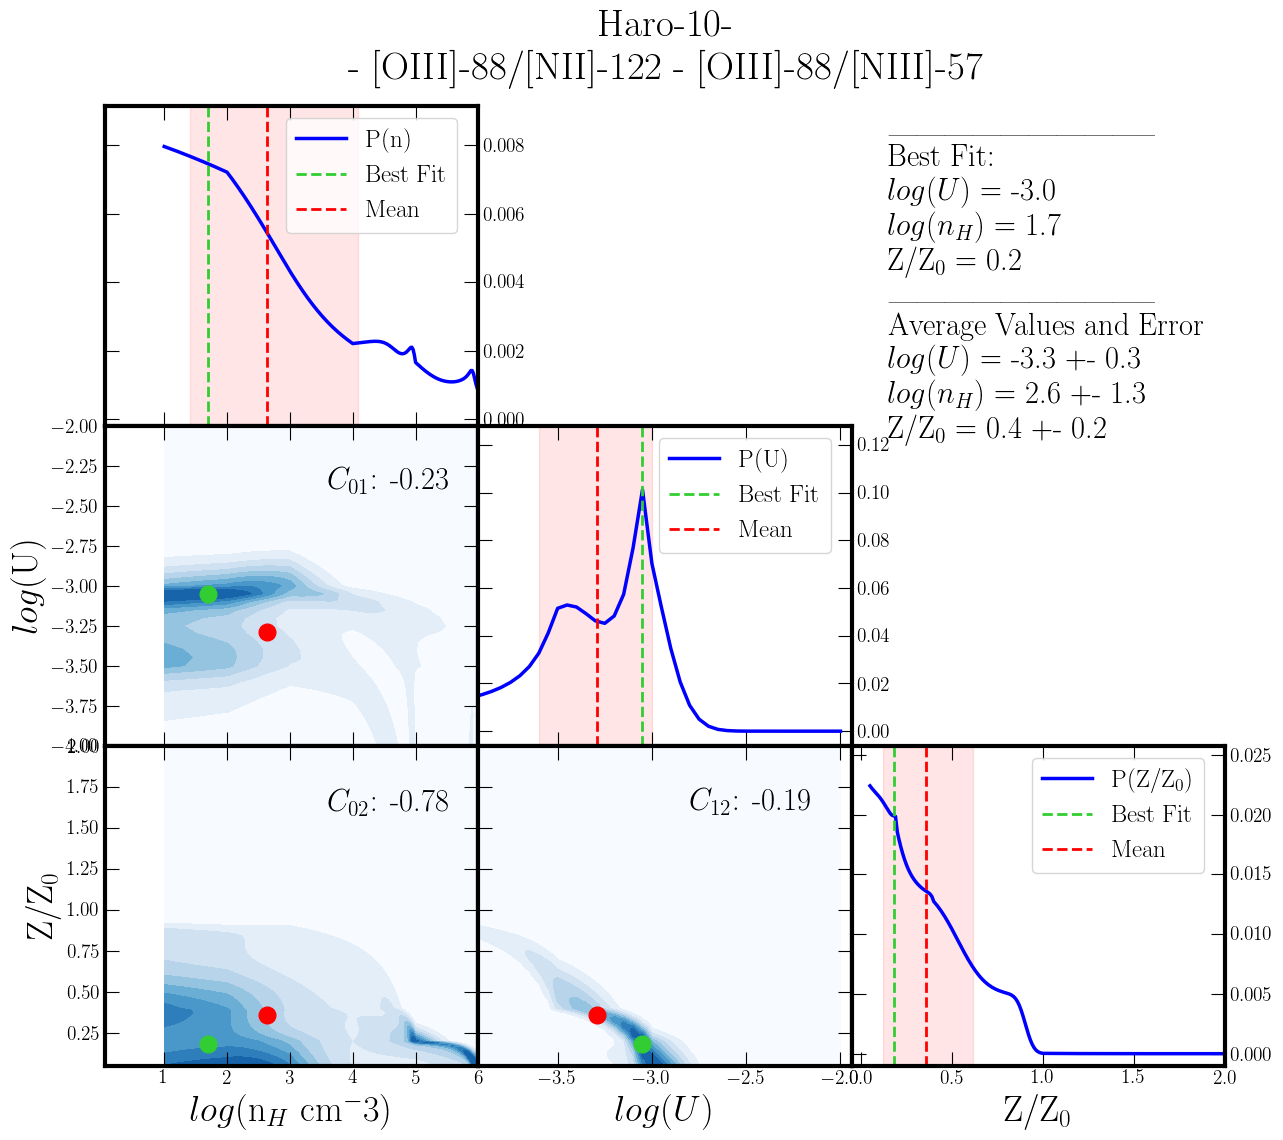




 ----------------------------running 9/9

 Results will be written in files:
/Users/admin/Scripts/GalaxyISM_0914/Plots/20240314_Haro-10-__Pplots_Fx5_Mod-08
/Users/admin/Scripts/GalaxyISM_0914/Plots/20240314_Haro-10-__Tplots_Fx5_Mod-08
UNZ_Haro-10-a_20240314.txt



 Y_obs [7.7801e-01 5.4586e-02 6.7960e-03 1.4253e+01 1.1448e+02 8.0321e+00
 1.4715e+02 1.8320e+01 5.4556e+01] 
 Y_sig [1.6560e-01 2.1568e-02 1.4424e-03 5.6369e+00 2.4379e+01 3.1740e+00
 3.1231e+01 7.2383e+00 2.3077e+01]

 Selected lines: 
 Y_obs: [7.7801e-01 5.4586e-02 6.7960e-03 1.4253e+01 1.1448e+02 8.0321e+00
 1.4715e+02 1.8320e+01 5.4556e+01] 
 Y_sig [1.0000e+06 1.0000e+06 1.4424e-03 1.0000e+06 1.0000e+06 3.1740e+00
 1.0000e+06 1.0000e+06 1.0000e+06]

Lines:   
 - [NII]-122/[OIII]-88 - [NIII]-57/[NII]-122 
 - NII122/OIII88- NIII57/NII122
(5, 6, 5, 9)
u 5 41 10
n 6 251 50
z 5 196 48
(41, 251, 196, 9)


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:00<00:00,  5.47it/s]


Models Cube Shape:  (5, 6, 5, 9)  Interpolate to Size: [ 41 251 196] 



 z: [0.05 0.2  0.4  1.   2.  ] (5,)

 new z 
 Shape: (196,)


New Cube shape:  (41, 251, 196, 9)

 u shape: (41,) 
 n shape: (251,) 
 z shape: (196,)
Models refined shape:   (41, 251, 196, 9)
Chi shape:    (41, 251, 196, 9)
Chi^2 shape:  (41, 251, 196, 9) 	 Sum Chi^2 = 0.0E+00
Prob Shape:   (41, 251, 196) 	 Sum Prob = 1.00000E+00
Chi^2_min = 5.57E-02 
Chi^2_max = 0.00000E+00
Prob Dimensions: Pn (251,)  Pu (41,) Pz (196,)
BestSol Indexes: n-> [56] u-> [20] z-> [0] Chi_min^2 0.056
Parameters Dimensions  (251,)   (41,)   (196,)
_______________________________________________________________________

Best Fit 
 <n> = 2.12 		 <u> = -3.0000 		 <Z/Z> = 0.05
_______________________________________________________________________

Average Values, Standard Deviation
	 <u> = -3.1 +- 0.1  <n> = 1.8  +-  0.6 	 <Z/Z> = 0.1392  +-  0.0608
_______________________________________________________________________

Percentiles (Mean)

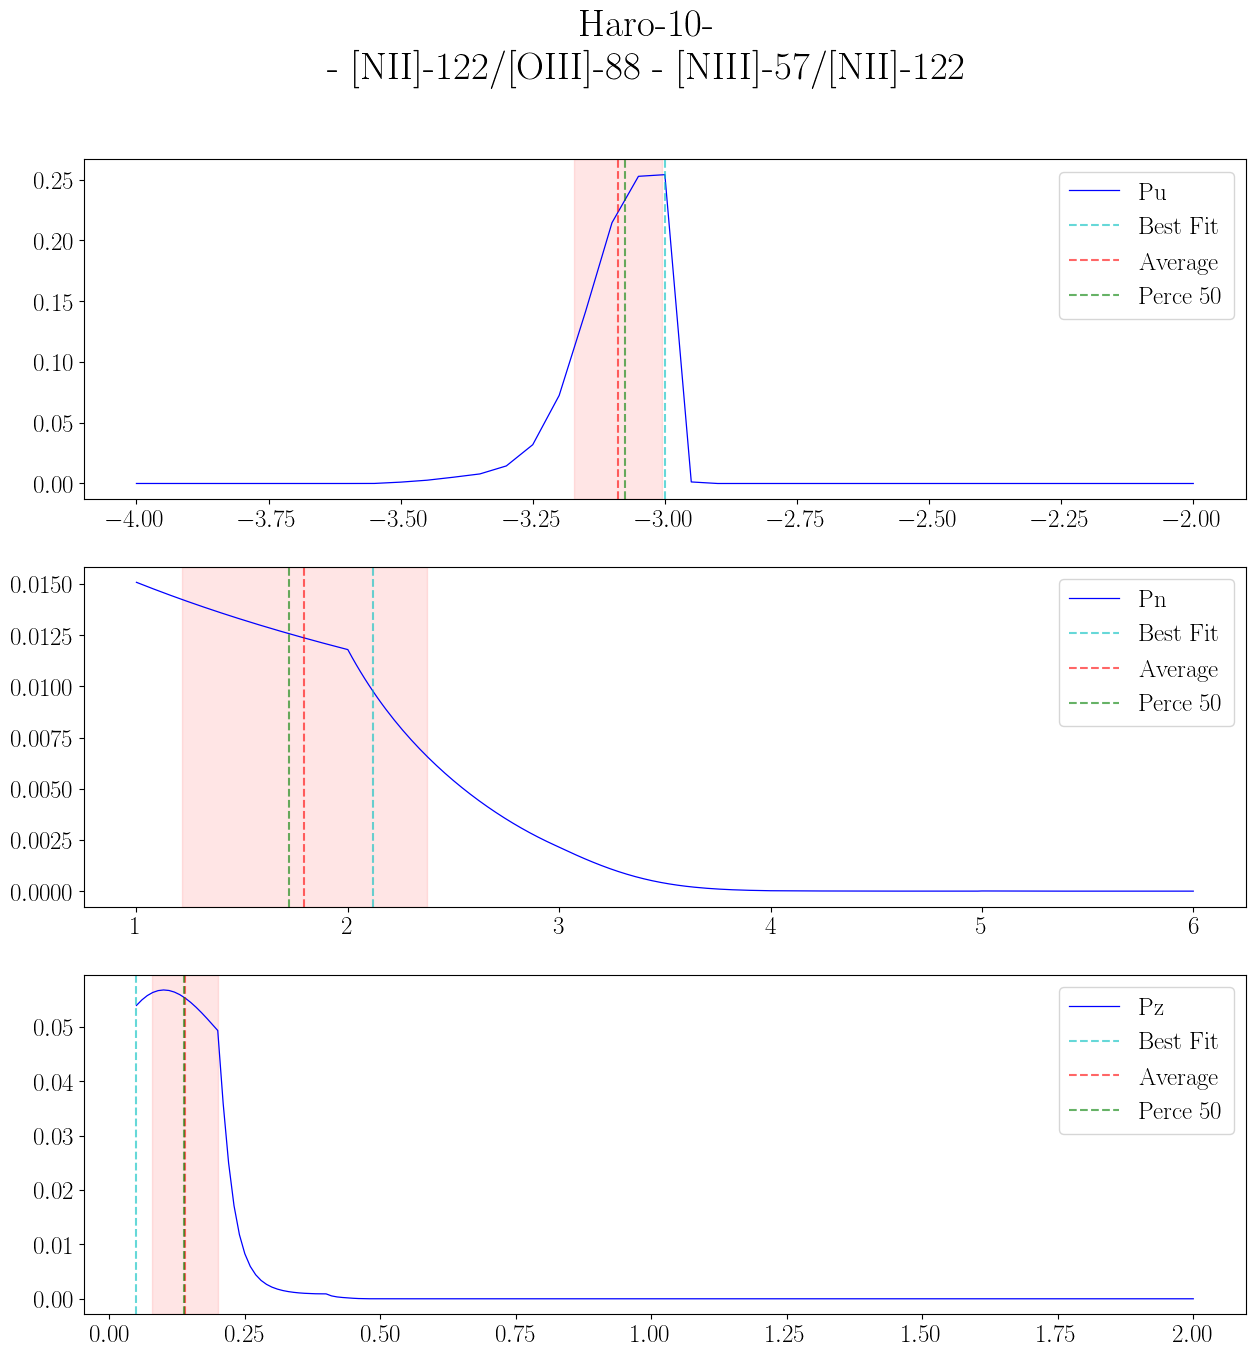

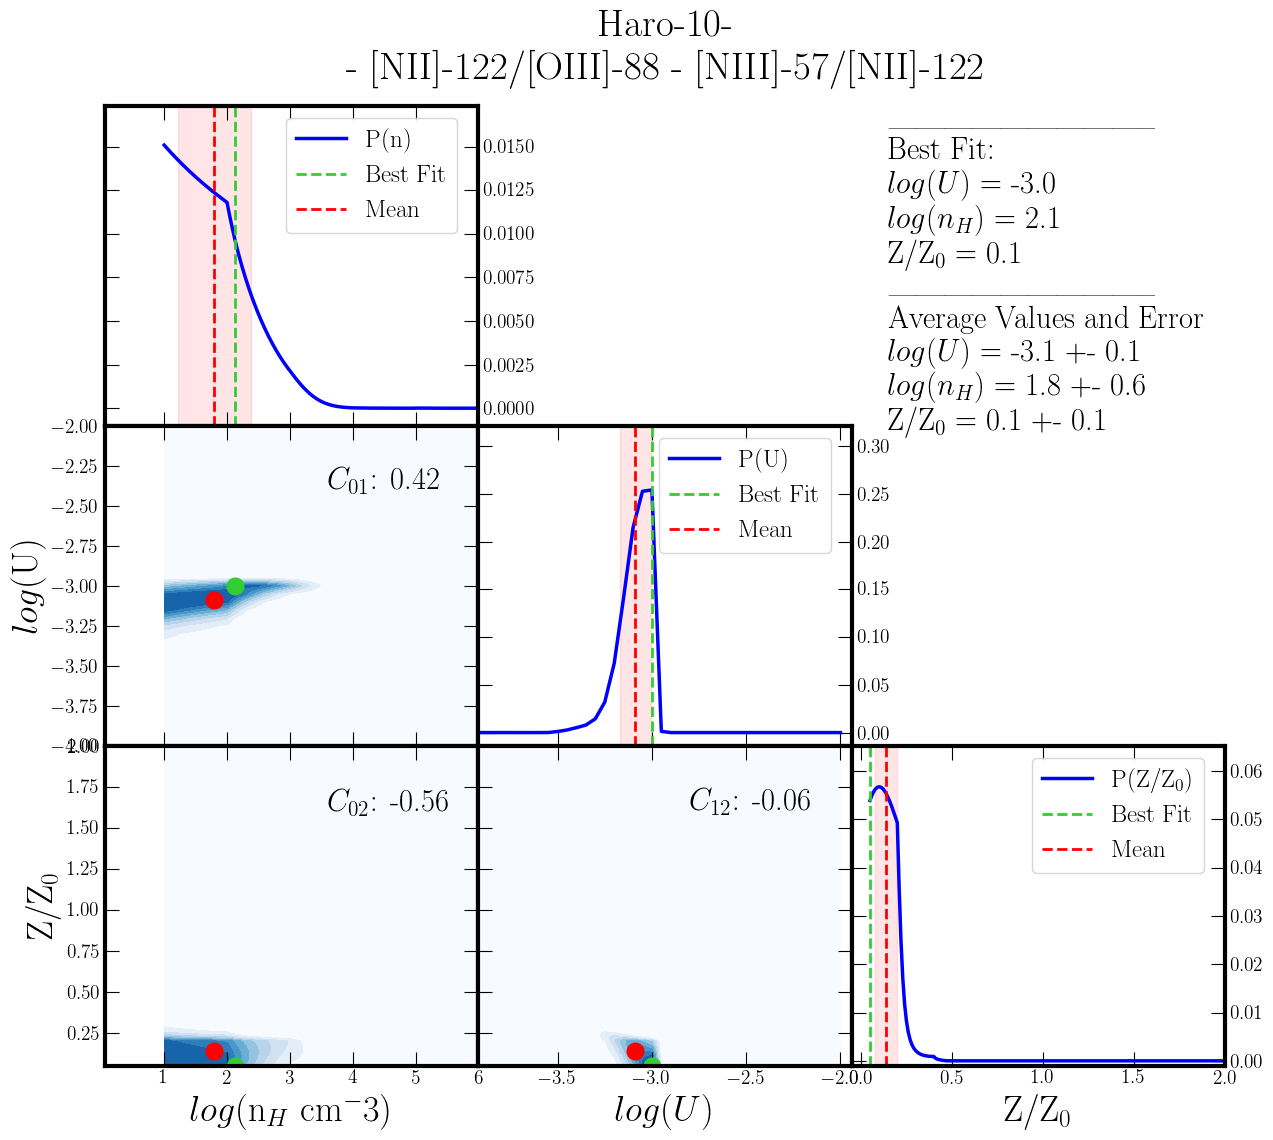

In [ ]:
# GALAXY Options for Haro-10 
FluxData = '5'                 
name     = 'Haro-10-'
notes    = '-a-'+date+'-' 
gali     = int(FluxData) - 1

# ------------------------------------------------------
#       
#                Output Plots
#       create the SummaryFile headers
#
#------------------------------------------------------
#path_output =  '/Users/smotinof/Documents/Scripts/GalaxyISM/Plots/' 

createNewSummaryFile = True
SummaryFile = 'UNZ_'+name+'a_'+date+'.txt'


if createNewSummaryFile:
    with open( path+SummaryFile, 'w') as f: # 'w' create new file, 'a' add to file
            f.write('Galaxy,Flux_ID,u_bs,n_bs,z_bs,u_mn,u_unc,n_mn,n_unc,z_mn,z_unc,u_50p,u_16p,u_84p,n_50p,n_16p,n_84p,z_50p,z_16p,z_84p,LinesRatiosUsed\n')
            f.close()

num_models = len(UseLinesArrays)
printgrids = False

for index in range(num_models):
        UseLines = UseLinesArrays[index]
        ModN = np.sum(UseLines) 
        
        strindex = str(index) 
        
        print('\n\n\n ----------------------------running '+str(index+1)+'/'+str(num_models))
        
        # Results table file:
        pltFileName1 = path+'Plots/'+date+'_'+name+'__Pplots_Fx'+str(FluxData)+'_Mod-0'+strindex
        pltFileName2 = path+'Plots/'+date+'_'+name+'__Tplots_Fx'+str(FluxData)+'_Mod-0'+strindex

        print('\n Results will be written in files:')
        print(pltFileName1)
        print(pltFileName2)
        print(SummaryFile)
        print('\n\n')

        #Old format
        #Y_obs, Y_sig, TxtLines , TxtLinesShort  = LineDataGalaxy(gali,Gal,UseLines)
        Y_obs, Y_sig, TxtLines , TxtLinesShort  = LineDataGalaxy2(gali,Gal,UseLines)
        Ny = len(Y_obs) #  Number of lines 

        # Run the model

        %run  "model-part-1.ipynb"

## ___________________________________________________________________ 
#
#
#
#  
#
#
#
#
## ___________________________________________________________________ 

## ___________________________________________________________________ 
#
#
#
#  Break 2
#
#
#
#
## ___________________________________________________________________ 

# Part III

In [ ]:
# ------------------------------------------------------
#       
#        Extaer un modelo 
#
# ------------------------------------------------------


print ("\nBest Solution ")
print (' <n> = %3.2f'%n_grid[nidx],'\t\t <u> = %3.4f'%u_grid[uidx],'\t\t <z> = %3.2f'%z_grid[zidx] )

#name = 'Model n=%3.2f'%n_grid[nidx]+' u=%3.4f'%u_grid[uidx]+' z=%3.2f'%z_grid[zidx]
print('\n', 'Model n=%3.2f'%n_grid[nidx]+' u=%3.4f'%u_grid[uidx]+' z=%3.2f'%z_grid[zidx])
print('\n Y_model:')

# Model from best solution
Y_mod = ModelsCI[uidx,nidx,zidx,:][0]
print (Y_mod)


Best Solution 
 <n> = 1.62 		 <u> = -3.3500 		 <z> = 0.75

 Model n=1.62 u=-3.3500 z=0.75

 Y_model:
[7.7201e-01 3.0075e-01 6.1484e-02 4.0961e+00 5.1972e+01 9.8314e+00
 6.8766e+01 5.4927e+00 1.6180e+01]


In [ ]:
Y_sig

array([1.7056e-01, 6.2505e-02, 1.3042e-02, 1.0000e+06, 1.0000e+06,
       1.0000e+06, 1.0000e+06, 1.0000e+06, 1.0000e+06])

In [10]:

        
# ------------------------------------------------------
#       
#         
#
# ------------------------------------------------------


Nsize = 5
Nf = Nsize/100


name = 'Model n=%3.2f'%n_grid[nidx]+' u=%3.4f'%u_grid[uidx]+' z=%3.2f'%z_grid[zidx]+str(' nf=%1.2f'%Nf)
print(name,'\n') 

Y_sig_n = (Nf) * Y_mod
Y_mod_n = AddNoiseGaussian(Y_mod, Y_sig, 0, 1, Nf)

#Y_sig_n = Y_sig
#Y_sig_n = Y_sig_n*NotUseLines*999

NotUseLines = [1,0,0,0,1,1,0]
ModN_WN = np.sum(NotUseLines)

Y_sig_n, TxtLines, TxtLinesShort = selectlines(Y_sig_n, NotUseLines)


pltfileName1_WN = pltFileName1[0:-1]+str(ModN_WN)+"_02_N"+str(Nsize)+"added"
pltfileName2_WN = pltFileName2[0:-1]+str(ModN_WN)+"_02_N"+str(Nsize)+"added"
#pltfileName1_WN = '/Users/smotinof/Documents/Scripts/Metallicities//Plots/20230616_Pplots_Fx2_Mod_NLines7_zoomin_3_02_N1added'
#pltfileName2_WN = '/Users/smotinof/Documents/Scripts/Metallicities//Plots/20230616_Tplots_Fx2_Mod_NLines7_zoomin_3_02_N1added'


print ('\n Dim:',Y_mod.shape,' ', Y_mod_n.shape)

print (' Y_mod:\n   ',Y_mod,'\n\n','Y_mod with noyse added:\n   ', Y_mod_n)

print ( '\n Y_sig:\n',Y_sig)
print ( '\n Y_sig_n:\n',Y_sig_n)

print('\nResults on Files:')
print(pltfileName1_WN)
print(pltfileName2_WN)
print(SummaryFile)

# ------------------------------------------------------
#                
#
# ------------------------------------------------------

Model n=1.62 u=-3.3500 z=0.75 nf=0.05 



NameError: name 'Y_mod' is not defined

In [ ]:
name,notes,TxtLines

('Model n=1.62 u=-3.3500 z=0.75 nf=0.05',
 '--20240310-',
 '\n - [OIII]-52/[OIII]-88 -  [OIII]-88/[NII]-122\n - (2.2x[OIII]-88+[OIII]-52)/[NIII]-57')

Models refined shape:   (41, 251, 196, 9)
Chi shape:    (41, 251, 196, 9)
Chi^2 shape:  (41, 251, 196, 9) 	 Sum Chi^2 = 0.0E+00
Prob Shape:   (41, 251, 196) 	 Sum Prob = NAN
Chi^2_min = 1.60E+15 
Chi^2_max = 0.00000E+00
Chi^2_min = 1.60E+15 
Chi^2_max = 1.60E+15
Dimensions:  (251,) (41,) (196,)
27 31 70
Parameters Dimensions  (251,)   (41,)   (196,)
_______________________________________________________________________

Best Fit 
 <n> = 1.62 		 <u> = -3.3500 		 <Z/Z> = 0.75
_______________________________________________________________________

Average Values, Standard Deviation
	 <u> = nan +- nan  <n> = nan  +-  nan 	 <Z/Z> = nan  +-  nan
_______________________________________________________________________

Percentiles (Mean)
n: p_50 = nan 		p_16 = nan 		p_84 = nan
U: p_50 = nan 		p_16 = nan 		p_84 = nan
Z/Z: p_50 = nan 		p_16 = nan 		p_84 = nan
_______________________________________________________________________
Model n=1.62 u=-3.3500 z=0.75 nf=0.05, 6, -3.350, 1.620, 0.750, 

ValueError: Axis limits cannot be NaN or Inf

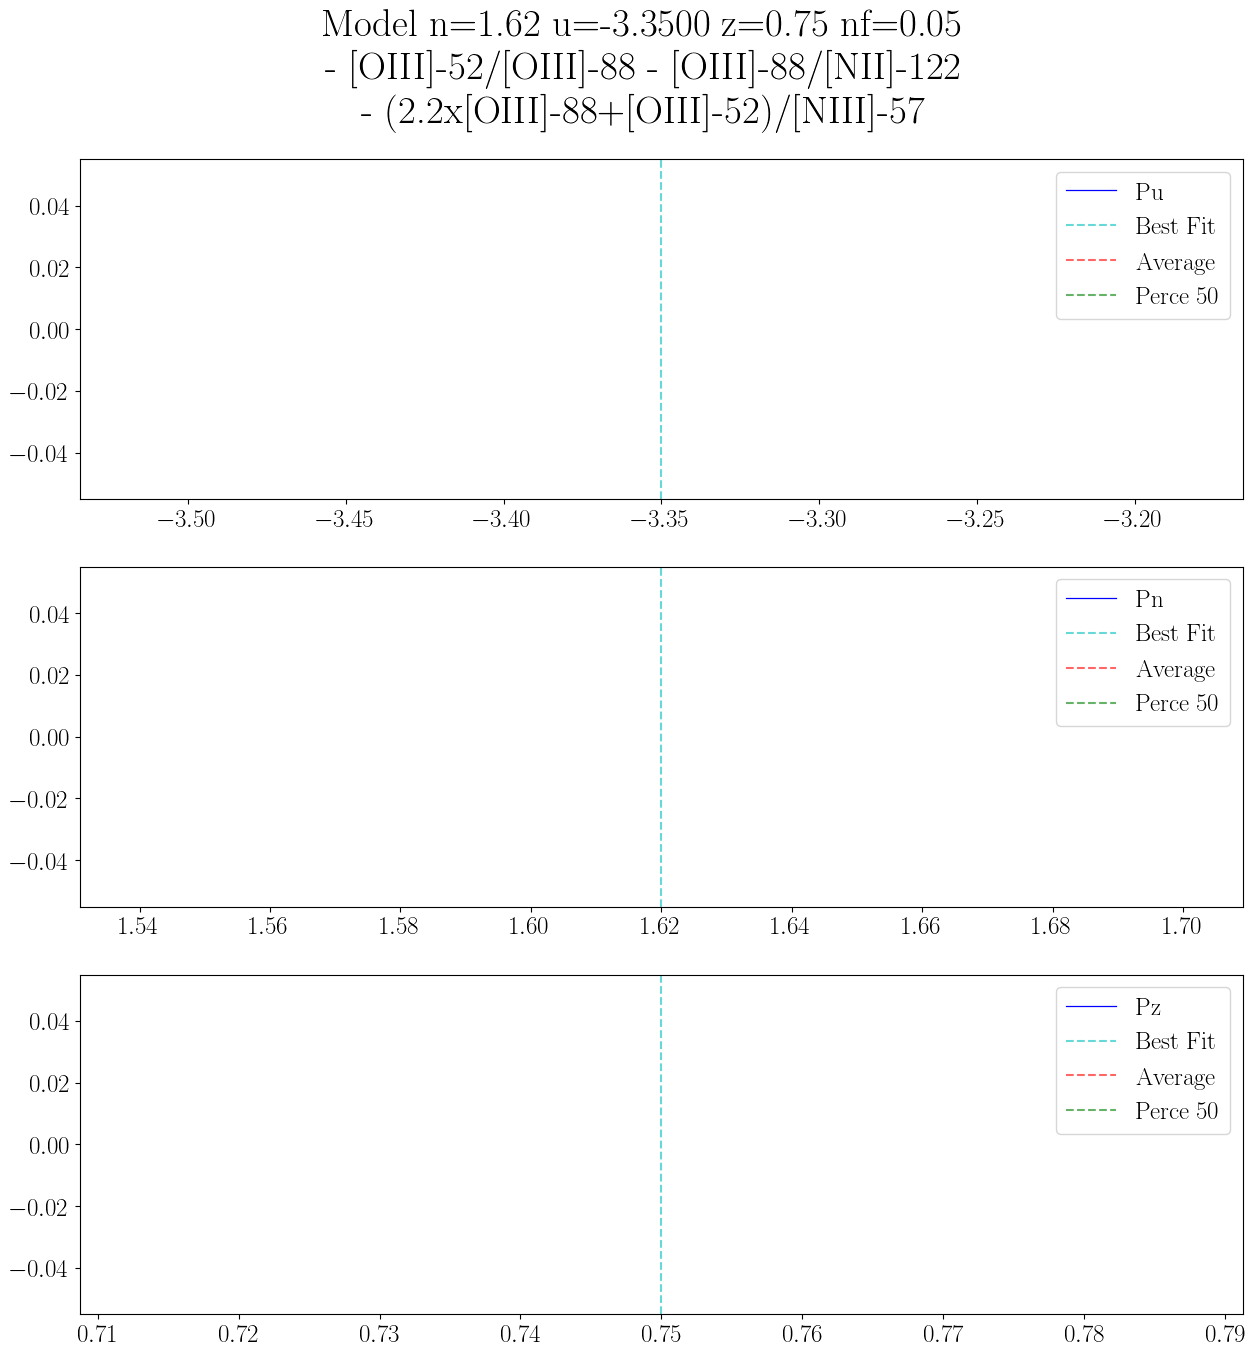

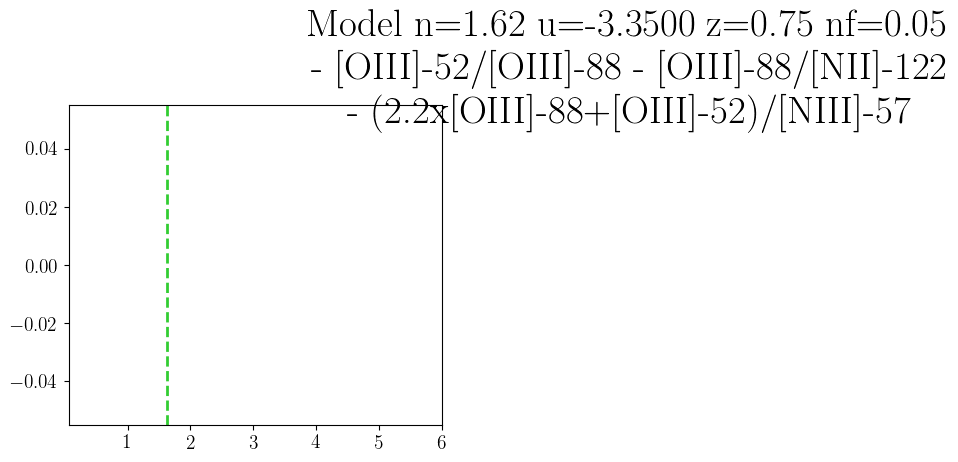

In [ ]:

Prob_N        = np.zeros(( lugrid, lngrid, lzgrid),          dtype = 'float128')
chisqr_grid_N = np.zeros(( lugrid, lngrid, lzgrid),          dtype = 'float128')

chisqr_grid_N, Prob_N      = CalcChi2_N(lugrid, lngrid, lzgrid, Y_mod_n, Y_sig_n, ModelsCI )
chimin_N                   = chisqr_grid_N.min() 

print ('Chi^2_min = %3.2E'%chimin_N, '\nChi^2_max = %3.2E'%chisqr_grid_N.max(),)

Pu_N = Prob_N.sum(axis = 2)
Pu_N = Pu_N.sum(axis =1)
#Pn = Pn.sum(axis =1)

Pn_N  = Prob_N.sum(axis = 2)                   # marginalized likelihood of a (summed over the second dimension)
Pn_N  = Pn_N.sum( axis = 0)
#Pu  = Pu.sum( axis = 0)

Pz_N  = Prob_N.sum(axis = 1)                   # marginalized likelihood of a (summed over the second dimension)
Pz_N  = Pz_N.sum( axis = 0)

print ('Dimensions: ',np.shape(Pn_N) , np.shape(Pu_N) , np.shape(Pz_N) )
npar = 3

uidx_N, nidx_N, zidx_N = np.where(chisqr_grid_N == chimin_N)
# In case more than one index is true in prev. statement: 
# Need to take the single one best solution
uidx_N, nidx_N, zidx_N = np.max(uidx), np.max(nidx), np.max(zidx)
print (uidx_N, nidx_N, zidx_N) 


#PrintResults()
#GetSolutions( prob, pu, pn, pz, ui,  ni, zi, u_grid, n_grid, z_grid, text1, text2, 
#title, SummaryFile, name, FluxData, TxtLinesShort )

plt_title = name+TxtLines #+notes

GetSolutions(Prob_N, Pu_N, Pn_N, Pz_N, uidx_N, nidx_N, zidx_N ,  u_grid, n_grid, z_grid, pltfileName1_WN, pltfileName2_WN, 
             plt_title  , path+SummaryFile, name, FluxData, TxtLinesShort  )


In [ ]:
name+notes+TxtLines

In [ ]:
name

In [ ]:
# ----- Pending Bills ---- October - November 2023
# Andrew                = $ 40
# Lars                  = Tappas dinner + airbnb
# Laura                 = $ 21.04 [ DONE]
# Fiorella (Lars' gift) = $ 15  [ DONE]

tax = 33.58 / 368
tip = (72.28)/(401.58)
a = ((47 + 35/3 ) * (1+tax) )* (1+tip)-54.5
a = 21.042

In [ ]:
 #5.55